In [2]:
import pandas as pd
import pickle as pk
import networkx as nx
import collections
import random as rd
import itertools as it
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import gseapy as gp
from gseapy import dotplot


In [12]:
#Now, let's compute how similar these two genesets are:
def overlap_genelists(lstA, lstB):
    import scipy.stats as stats
    """
    Accepts to lists
    M is the population size (previously N)
    n is the number of successes in the population
    N is the sample size (previously n)
    x is still the number of drawn “successes”
    """
    setA= set(lstA)
    setB= set(lstB)
    M= G_ppi.number_of_nodes() #total number of genes
    n= len(setA)
    N= len(setB)
    x= len(setA.intersection(setB))

    return str(stats.hypergeom.sf(x-1, M, n, N))

import scipy  
from scipy import stats

#Here we define the adjustment
from statsmodels.sandbox.stats.multicomp import multipletests
def fdr_adjustment(list_of_pvals,alpha):    
    return multipletests(list_of_pvals,alpha=alpha,method='fdr_bh')[1] #the benjamin hochberg method is used

def reduce_dict(input_dict):
    # Initialize an empty set to keep track of seen lists
    seen = set()
    result = {}
    
    for key, value in input_dict.items():
        # Convert the list to a frozenset for comparison (order-independent and hashable)
        current_set = frozenset(value)
        
        # If the set has not been seen before, add it to the result
        if current_set not in seen:
            result[key] = value
            # Add the set to the seen sets
            seen.add(current_set)
    
    return result
    
#Let's calculate the Cohen's d as an effect size
def calculate_ttest_and_effect_size(list1, list2):
    from scipy import stats
    import numpy as np
    t_value, p_value = stats.ttest_ind(list1, list2)

    n1 = len(list1)
    n2 = len(list2)
    dof = n1 + n2 - 2

    mean1 = np.mean(list1)
    mean2 = np.mean(list2)
    var1 = np.var(list1, ddof=1)
    var2 = np.var(list2, ddof=1)

    pooled_var = ((n1 - 1) * var1 + (n2 - 1) * var2) / dof
    effect_size = (mean1 - mean2) / np.sqrt(pooled_var)

    return t_value, p_value, effect_size

def net_modularity(genelist,network):
    geneset=set(genelist)&network.nodes()
    if len(geneset)>2:
        G_sub = nx.subgraph(network,geneset)
        Gsub_lcc = G_sub.subgraph(max(nx.connected_components(G_sub), key=len))  # extract lcc graph
        number_of_connected_component=Gsub_lcc.number_of_nodes()
        f_lcc_size = Gsub_lcc.number_of_nodes()
        l_random_lccs = []
        S = 1000
        for s in range(S):
            gene_sample = rd.sample(list(network.nodes()),len(geneset))
            G_sub_rnd = nx.subgraph(network,gene_sample)
            G_sub_rnd_lcc = G_sub_rnd.subgraph(max(nx.connected_components(G_sub_rnd), key=len))  # extract lcc graph
            lcc_size = G_sub_rnd_lcc.number_of_nodes()
            l_random_lccs.append(lcc_size)
        mu = np.mean(l_random_lccs)
        std = np.std(l_random_lccs)
        z = (f_lcc_size-mu)/std
    else:
        number_of_connected_component=0
        z='nan'
    return z

#Enrichment time

def enrichment_from_genelist(gene_list,libraries):   #This function returns the enrichment df for GOBP,GOCC,GOMF,KeGG  
    import gseapy as gp
    enr_df_dict={}
    for l in libraries:
        enr_df = gp.enrichr(gene_list=gene_list,
                             gene_sets=l,
                             organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                             outdir=None, # don't write to disk
                            )
        enr_df_dict[l]=enr_df

    return enr_df_dict

lib_list=['GO_Biological_Process_2023','GO_Molecular_Function_2023','GO_Cellular_Component_2023','KEGG_2021_Human']



In [5]:
male_trajectories_df=pd.read_excel('input/All identified trajectories in males. trajectories smaller than 100 members.xlsx')

In [3]:
with open('output/male_trajectories_dict_filtered.pickle', 'rb') as handle:
    male_trajectories_dict_filtered = pk.load(handle)

with open('output/male_trajectories_dict_filtered_unique.pickle', 'rb') as handle:
    male_trajectories_dict_filtered_unique = pk.load(handle)

with open('output/male_trajectories_dict_filtered_unique_agglomerated_genes.pickle', 'rb') as handle:
    male_trajectories_dict_filtered_unique_agglomerated_genes = pk.load(handle)


In [179]:
diverge_pairs_male_df = pd.read_csv("input/Diverge_Pairs/Diverge_Pairs_Males.csv")

In [101]:
diverge_pairs_female_df = pd.read_csv("input/Diverge_Pairs/Diverge_Pairs_Females.csv")

In [290]:

male_diverge_pairs_dict_dis_differences = {}
for i,v in diverge_pairs_male_df.iterrows():
    dis_difference_1 = []
    dis_difference_2 = []
    trj_1 = v['Cluster1'].replace("__","-")
    trj_2 = v['Cluster2'].replace("__","-")
    new_trj_1 = trj_1.replace(" ","")
    new_trj_2 = trj_2.replace(" ","")
    dis_list_trj_1 = []
    for distim in new_trj_1.split(","):
        dis_list_trj_1.append(distim.split("-")[0])
    dis_list_trj_2 = []
    for distim in new_trj_2.split(","):
        dis_list_trj_2.append(distim.split("-")[0])
    for dis in dis_list_trj_1:
        if dis not in dis_list_trj_2:
            dis_difference_1.append(dis)
    for dis in dis_list_trj_2:
        if dis not in dis_list_trj_1:
            dis_difference_2.append(dis)
    if len(set(dis_difference_1))>0 and len(set(dis_difference_2))>0:
        male_diverge_pairs_dict_dis_differences[i]=[set(dis_difference_1),set(dis_difference_2)]




In [321]:
len(male_diverge_pairs_dict_gene_differences[33][0])

505

In [323]:
male_diverge_pairs_dict_gene_differences[33][0].difference(male_diverge_pairs_dict_gene_differences[33][1])

{'ABI1',
 'ABL1',
 'ACP3',
 'ADA',
 'ADRA2A',
 'ADRA2B',
 'ADRA2C',
 'AFF3',
 'AFF4',
 'AKAP9',
 'AKT1',
 'AKT3',
 'ALK',
 'ANK1',
 'APC',
 'AR',
 'ARHGAP26',
 'ARHGAP35',
 'ARHGEF10L',
 'ARID1A',
 'ARID1B',
 'ARID2',
 'ARNT',
 'ARRB1',
 'ATF1',
 'ATM',
 'ATP1A1',
 'ATP2B3',
 'ATR',
 'ATRX',
 'AXIN2',
 'AXL',
 'BAP1',
 'BARD1',
 'BCL11A',
 'BCL2',
 'BCL9L',
 'BCORL1',
 'BCR',
 'BIRC6',
 'BLK',
 'BRAF',
 'BRCA1',
 'BRCA2',
 'BRD3',
 'BRD4',
 'BRIP1',
 'BTK',
 'CACNA1D',
 'CALR',
 'CAMTA1',
 'CARD11',
 'CASP8',
 'CBFA2T3',
 'CCDC6',
 'CCND2',
 'CCND3',
 'CCR4',
 'CD19',
 'CD22',
 'CD274',
 'CD33',
 'CD38',
 'CD3D',
 'CD3E',
 'CD3G',
 'CD79B',
 'CDH1',
 'CDH11',
 'CDK12',
 'CDK4',
 'CDK6',
 'CEP89',
 'CHEK2',
 'CIC',
 'CLTCL1',
 'CNBD1',
 'CNTNAP2',
 'CRBN',
 'CREB1',
 'CREB3L2',
 'CREBBP',
 'CRTC1',
 'CSF1R',
 'CSF2RA',
 'CSF3R',
 'CSMD3',
 'CSNK1E',
 'CTLA4',
 'CTNNA2',
 'CTNNB1',
 'CTNND2',
 'CUL4A',
 'CUX1',
 'CXCR4',
 'CYP11A1',
 'CYP11B1',
 'CYP17A1',
 'CYP19A1',
 'DCC',
 'DCLRE1B',

In [326]:
np.mean(male_diverge_pairs_dict_gene_degree_differences[33][0])

133.3980198019802

In [327]:
np.mean(male_diverge_pairs_dict_gene_degree_differences[33][1])

54.786407766990294

In [8]:

#Here, we define the PPI
ppi = pd.read_csv("input/autocore_ppi_symbol_lcc.csv",delimiter= ',',
           skipinitialspace=True)
G_ppi = nx.from_pandas_edgelist(ppi, 'symbol1', 'symbol2')
#Let's import the Elma diseases
#Let's import the ICD-gene associations
with open('output/allsources_icd_gene_dict_unified.pickle', 'rb') as handle:
    allsources_icd_gene_dict_unified = pk.load(handle)
    
icd_genes_ppi_dict={}

for dis,genelist in allsources_icd_gene_dict_unified.items():
    new_genelist=set(genelist)&G_ppi.nodes()
    if len(new_genelist)>0:
        icd_genes_ppi_dict[dis]=new_genelist

print(len(icd_genes_ppi_dict))


1020


In [291]:
#Let's try to extract the genes that are representative of these differences

male_diverge_pairs_dict_gene_differences = {}
for idx,div_pair_list in male_diverge_pairs_dict_dis_differences.items():
    gene_list_1 = []
    gene_list_2 = []
    for dis in div_pair_list[0]:
        try:
            for gene in icd_genes_ppi_dict[dis]:
                if gene not in gene_list_1:
                    gene_list_1.append(gene)
        except:
            pass
    for dis in div_pair_list[1]:
        try:
            for gene in icd_genes_ppi_dict[dis]:
                if gene not in gene_list_2:
                    gene_list_2.append(gene)
        except:
            pass
    male_diverge_pairs_dict_gene_differences[idx]=[set(gene_list_1),set(gene_list_2)]
    

In [292]:
male_diverge_pairs_dict_gene_differences_pval = {}
male_diverge_pairs_dict_gene_differences_fdr = {}


for idx,geneset_list in male_diverge_pairs_dict_gene_differences.items():
    pval_ov = float(overlap_genelists(geneset_list[0],geneset_list[1]))
    male_diverge_pairs_dict_gene_differences_pval[idx] = pval_ov

adj_pval=fdr_adjustment(list(male_diverge_pairs_dict_gene_differences_pval.values()),0.05)
pair_list=list(male_diverge_pairs_dict_gene_differences_pval.keys())
for i in range(len(adj_pval)):
    male_diverge_pairs_dict_gene_differences_fdr[pair_list[i]]=adj_pval[i]
print(len([trj for trj in male_diverge_pairs_dict_gene_differences_fdr.keys() if male_diverge_pairs_dict_gene_differences_fdr[trj]<0.05]))
print(len(male_diverge_pairs_dict_gene_differences))
#25 out of 30 trajectories show gene similarities between the two possibilities

25
30


In [293]:
#Let's check for the degree in the PPI
male_diverge_pairs_dict_gene_degree_differences = {}
for idx,genesetlist in male_diverge_pairs_dict_gene_differences.items():
    deg_list_1 = []
    deg_list_2 = []
    for gene in genesetlist[0]:
        deg_list_1.append(G_ppi.degree(gene))
    for gene in genesetlist[1]:
        deg_list_2.append(G_ppi.degree(gene))
    male_diverge_pairs_dict_gene_degree_differences[idx]=[deg_list_1,deg_list_2]
        

In [294]:
#Let's see whether there are differences in degree by performing a Mann-Withney test


male_diverge_pairs_dict_gene_degree_differences_pval = {}
male_diverge_pairs_dict_gene_degree_differences_fdr = {}

for idx,deg_list in male_diverge_pairs_dict_gene_degree_differences.items():
    try:
        t, p = stats.mannwhitneyu(deg_list[0], deg_list[1])
        male_diverge_pairs_dict_gene_degree_differences_pval[idx] = float(p)
    except:
        pass

adj_pval=fdr_adjustment(list(male_diverge_pairs_dict_gene_degree_differences_pval.values()),0.05)
pair_list=list(male_diverge_pairs_dict_gene_degree_differences_pval.keys())
for i in range(len(adj_pval)):
    male_diverge_pairs_dict_gene_degree_differences_fdr[pair_list[i]]=adj_pval[i]
    
print(len([trj for trj in male_diverge_pairs_dict_gene_degree_differences_fdr.keys() if male_diverge_pairs_dict_gene_degree_differences_fdr[trj]<0.05]))

#Most of these trajectories are statistically significantly different for degree

16


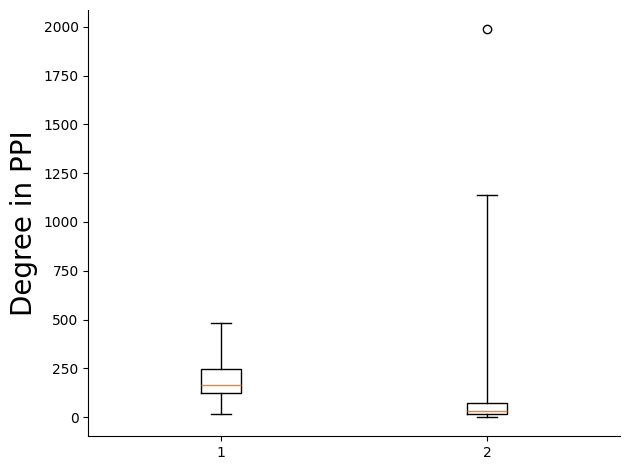

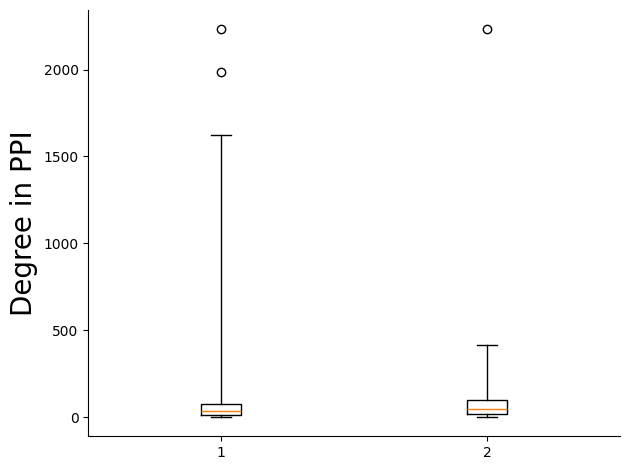

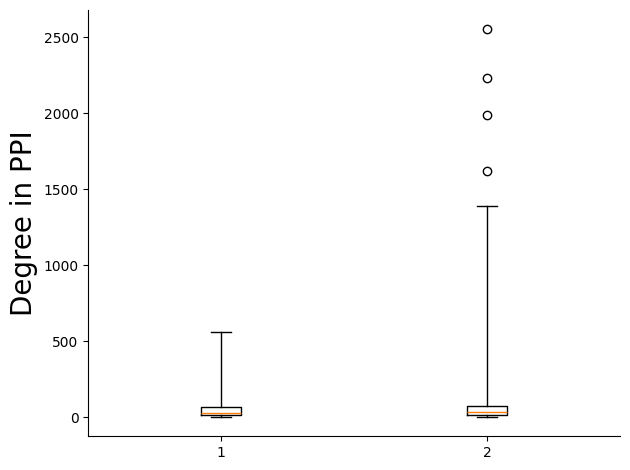

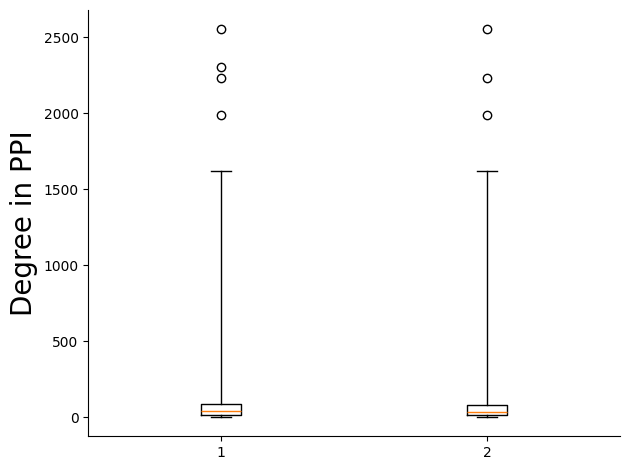

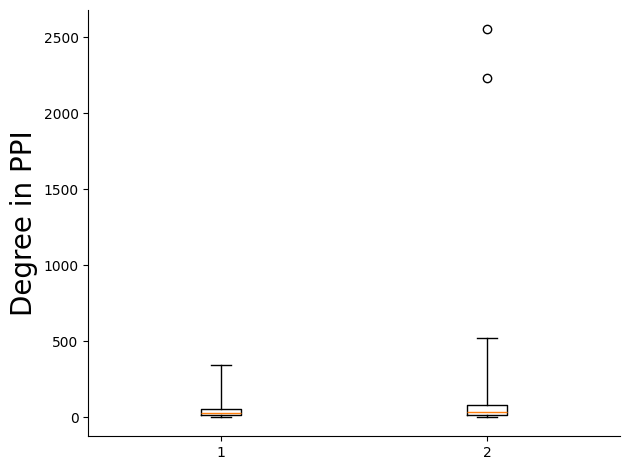

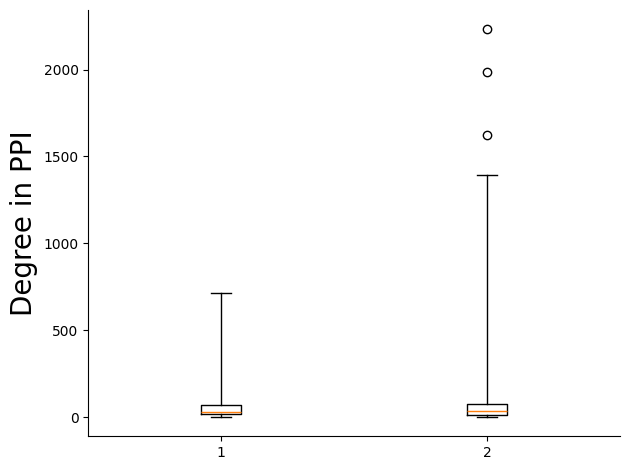

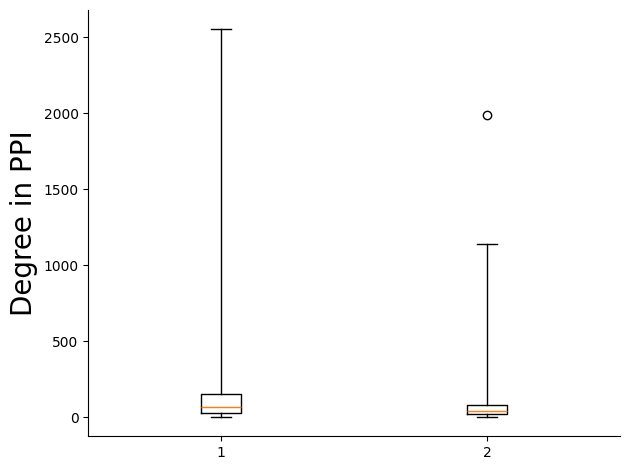

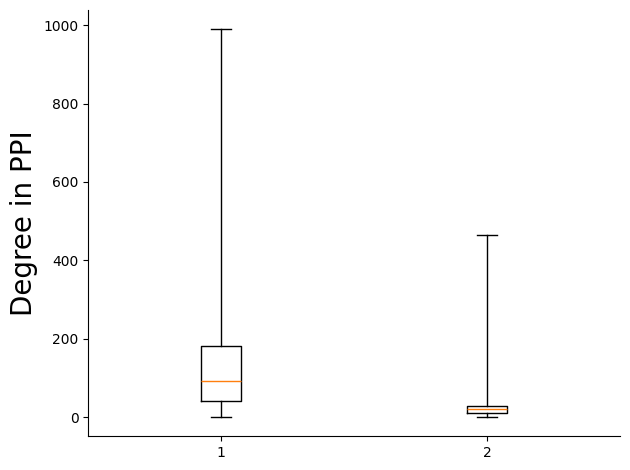

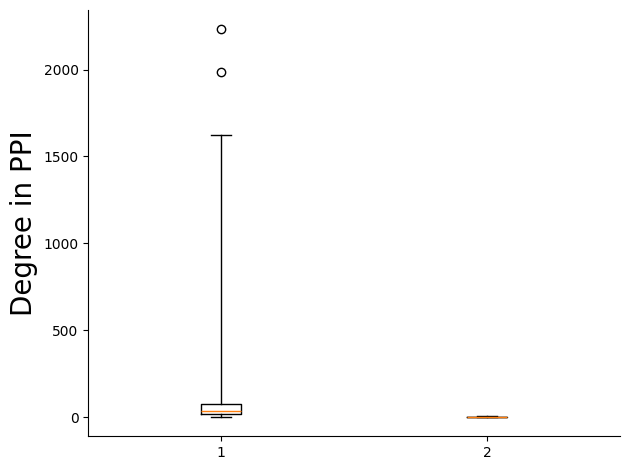

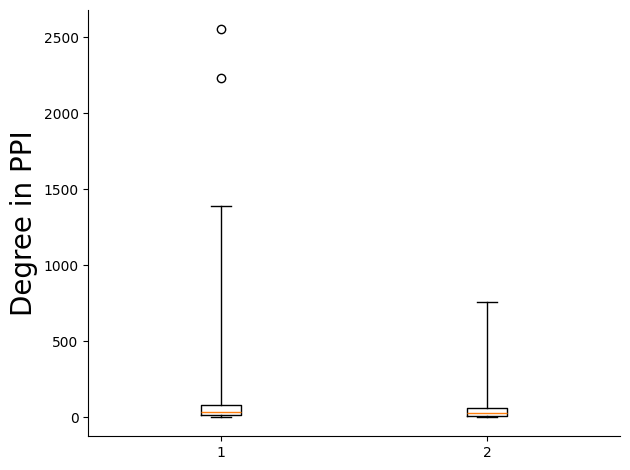

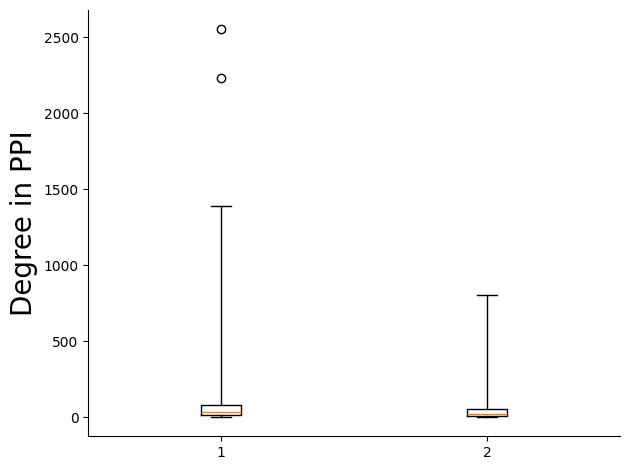

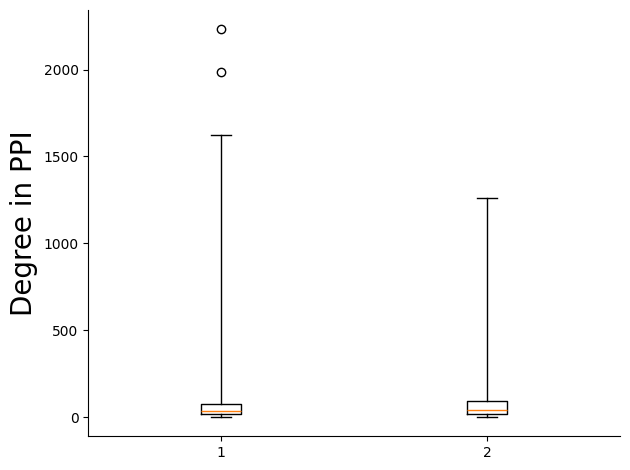

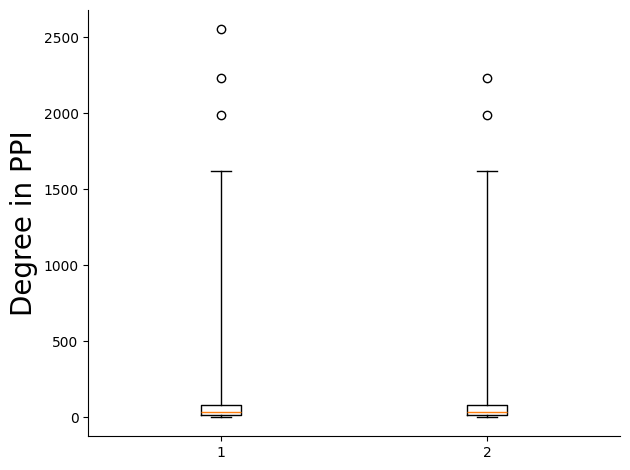

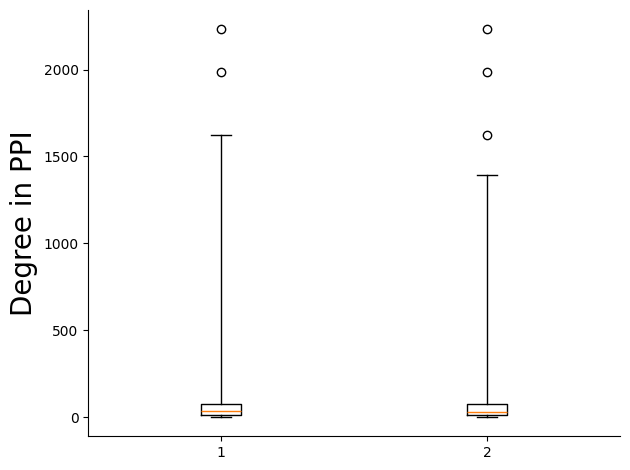

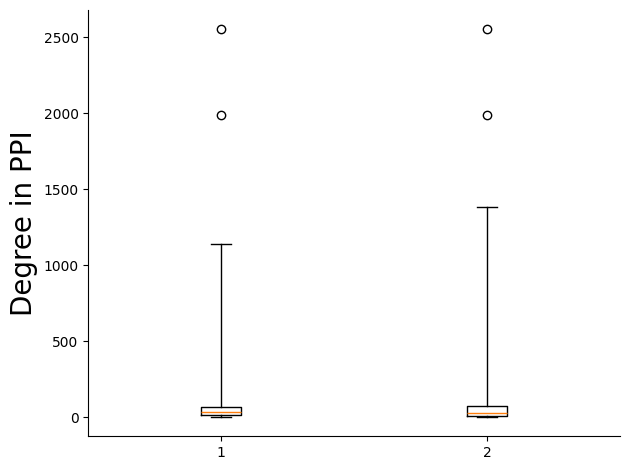

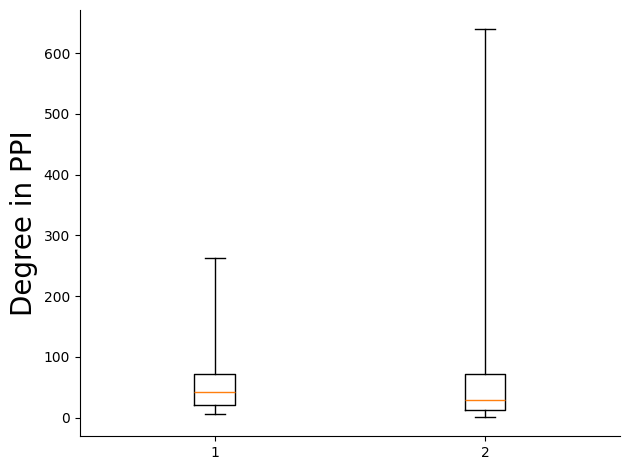

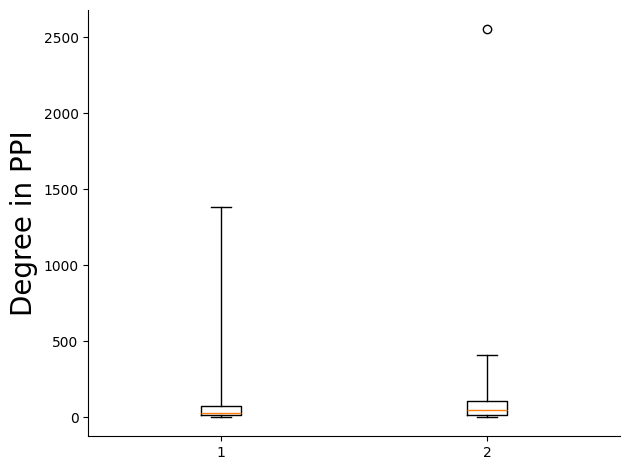

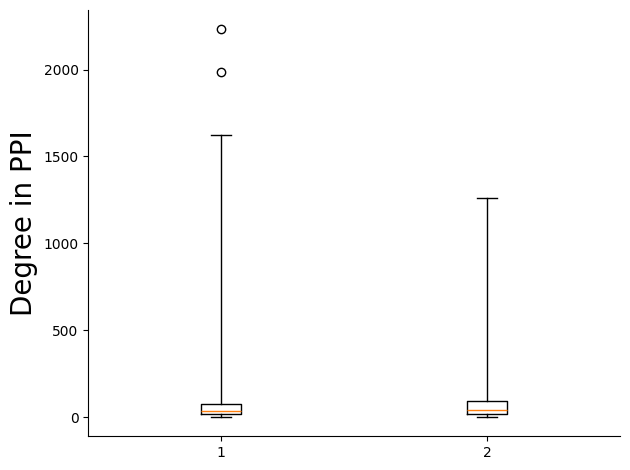

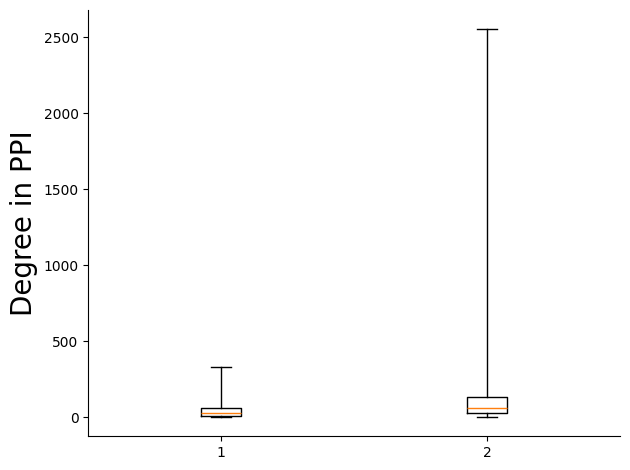

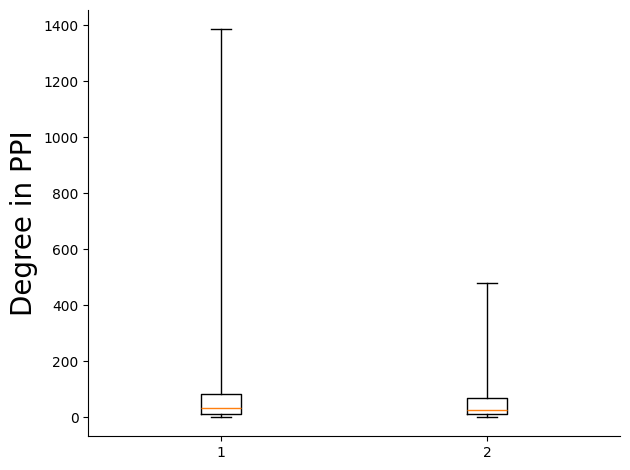

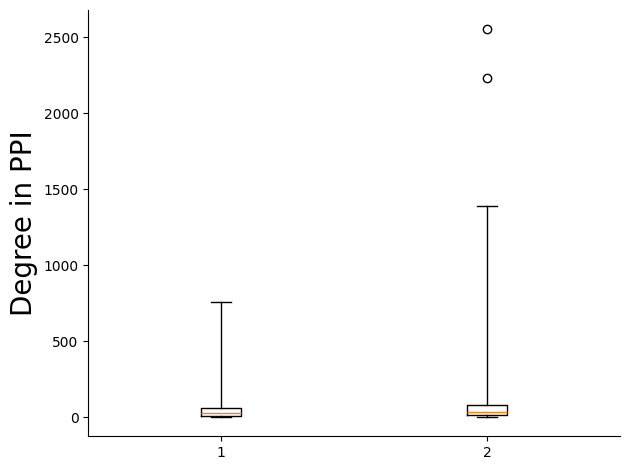

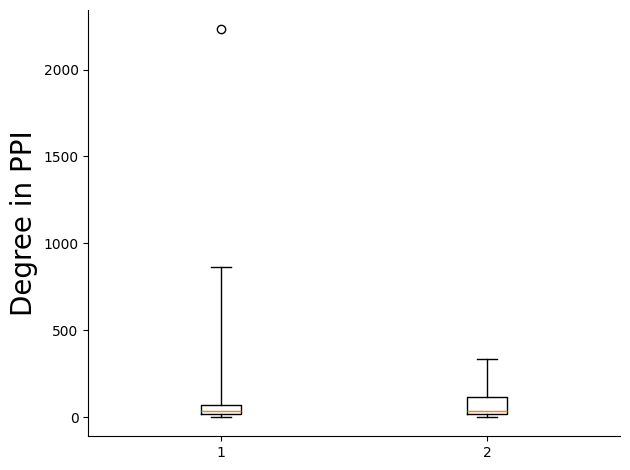

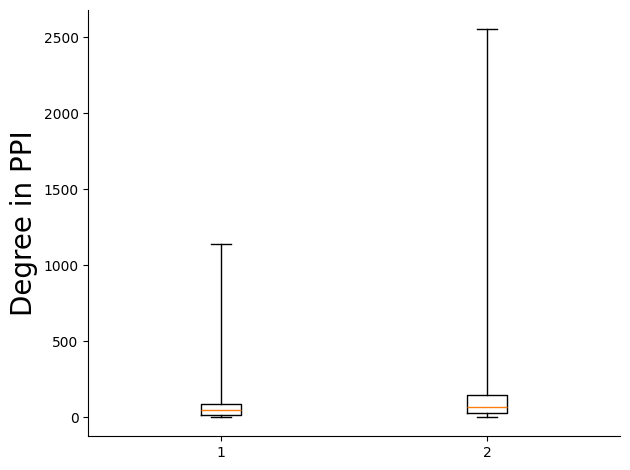

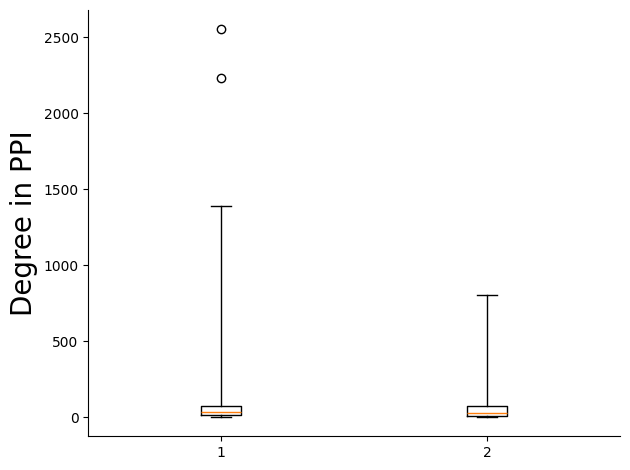

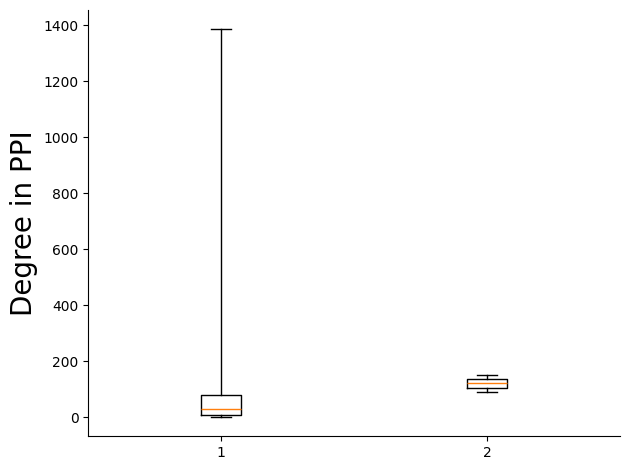

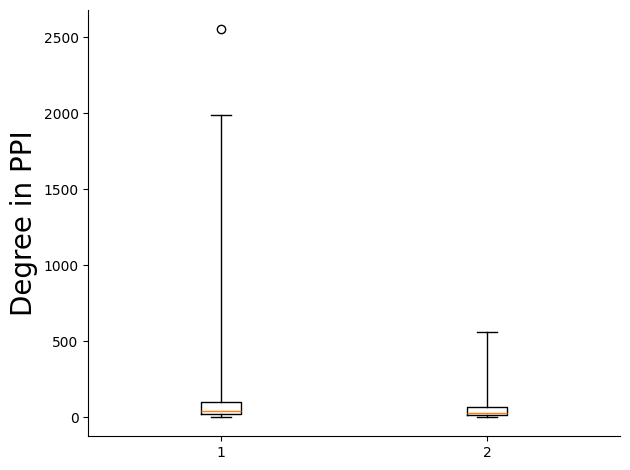

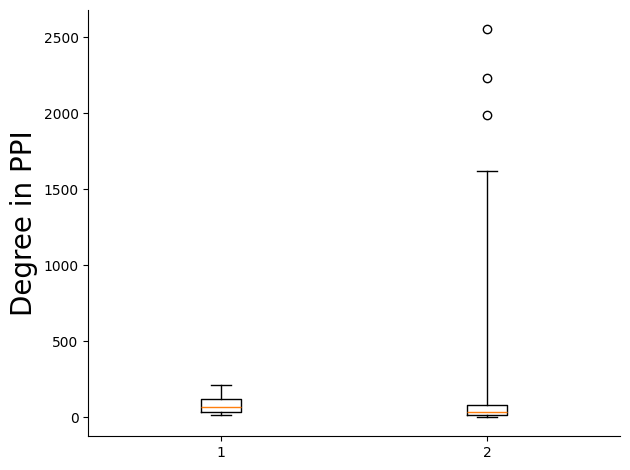

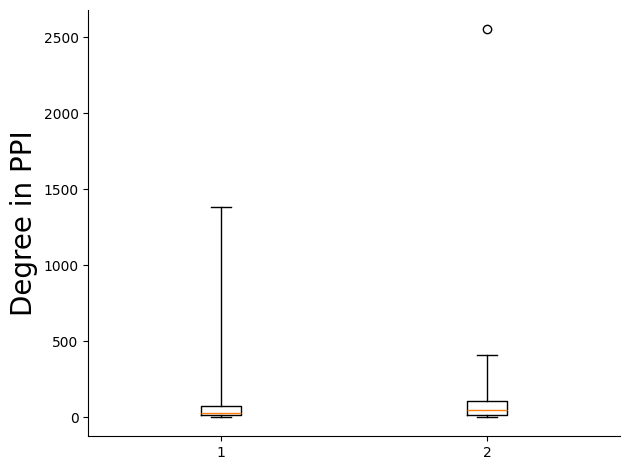

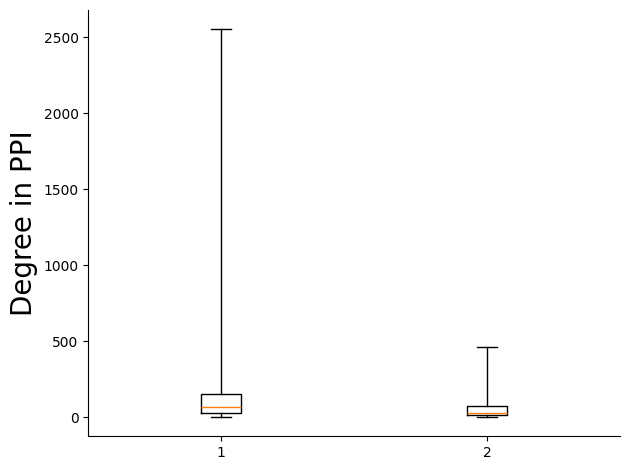

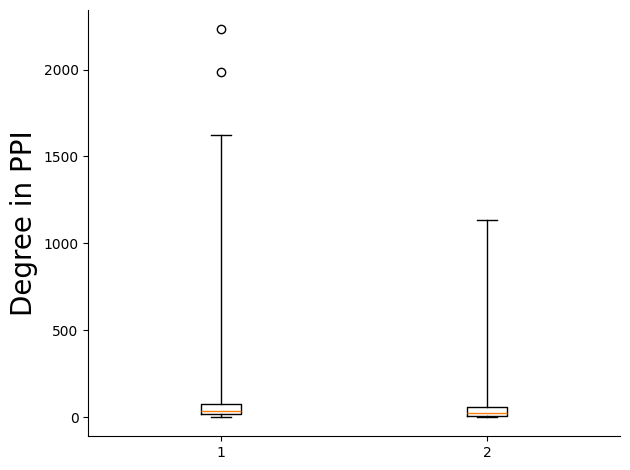

In [28]:


for idx,deg_list in male_diverge_pairs_dict_gene_degree_differences.items():
    fig1, ax1 = plt.subplots()
    plt.ylabel('Degree in PPI',fontsize=20)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_visible(True)
    ax1.spines['left'].set_visible(True)
    bplot = plt.boxplot(deg_list,whis=25,   #we are including all data points...like almost no outliers exist
                         notch=False,  # notch shape
                         vert=True )
    
    #plt.yscale("log")
    plt.tight_layout()
    plt.show()

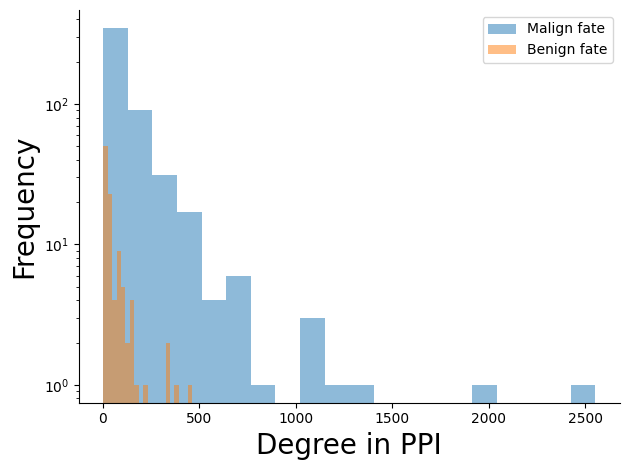

In [330]:
fig1, ax1 = plt.subplots()

# Define custom labels for the plot
labels=['Malign fate',
        'Benign fate']

plt.xlabel('Degree in PPI',fontsize=20)
comparing_group_list= [male_diverge_pairs_dict_gene_degree_differences[33][0],male_diverge_pairs_dict_gene_degree_differences[33][1]]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
# Plot histogram for each list in comparing_group_list
num_bins = 20  # Choose an appropriate number of bins for your data
for data, label in zip(comparing_group_list, labels):
    # Create a histogram for each set of data
    counts, bins, patches = ax1.hist(data, num_bins, label=label, alpha=0.5)
plt.yscale("log")
plt.ylabel("Frequency",fontsize=20)
ax1.legend()  # Add a legend if you want to label each histogram
plt.tight_layout()
plt.savefig('Figures/Divergent_Trj_Degree_Distribution_Example.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [332]:

malign_fate_enr_df=enrichment_from_genelist(list(male_diverge_pairs_dict_gene_differences[33][0]),lib_list)
malign_fate_enr_aggdf=pd.concat([v.res2d for v in list(malign_fate_enr_df.values())], join="inner")


In [335]:
from gseapy import barplot, dotplot

ax = dotplot(malign_fate_enr_aggdf,
              column="Adjusted P-value",ofname='Figures/Male_DivergingExample_MalignFate_Enrichment.pdf',
              x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
              size=5,
              top_term=3,
              figsize=(3,5),
              title = "Agglomerate Libraries",
              xticklabels_rot=45, # rotate xtick labels
              show_ring=True, # set to False to revmove outer ring
              marker='o',
             )

In [336]:
benign_fate_enr_df=enrichment_from_genelist(list(male_diverge_pairs_dict_gene_differences[33][1]),lib_list)
benign_fate_enr_aggdf=pd.concat([v.res2d for v in list(benign_fate_enr_df.values())], join="inner")


In [337]:
from gseapy import barplot, dotplot

ax = dotplot(benign_fate_enr_aggdf,
              column="Adjusted P-value",ofname='Figures/Male_DivergingExample_BenignFate_Enrichment.pdf',
              x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
              size=5,
              top_term=3,
              figsize=(3,5),
              title = "Agglomerate Libraries",
              xticklabels_rot=45, # rotate xtick labels
              show_ring=True, # set to False to revmove outer ring
              marker='o',
             )

In [6]:
male_trajectories_df_copy=pd.DataFrame()
male_trajectories_df_copy['Community_ID']=male_trajectories_df['Community_ID']

new_members_of_com_list=[]
for i in male_trajectories_df['Members of community'].tolist():
    new_i=i.replace("__","-")
    new_new_i=new_i.replace(" ","")
    new_members_of_com_list.append(new_new_i)
male_trajectories_df_copy['Members of community']=new_members_of_com_list

male_trajectories_df_copy.head()

,Community_ID,Members of community
0,1,"K35-10-19,K37-10-19,K56-10-19,K65-10-19"
1,2,"A04-0-9,A08-0-9,B09-0-9,F50-0-9,J10-0-9"
2,3,"A09-0-9,H73-0-9,K92-0-9"
3,4,"A41-0-9,C91-0-9,N10-0-9,A41-10-19,C91-10-19"
4,5,"A49-0-9,B27-0-9,J03-0-9,J06-0-9,J11-0-9,J38-0-..."


In [9]:
male_trajectories_dict={}
for i,v in male_trajectories_df_copy.iterrows():
    dis_list=[]
    for dis in v['Members of community'].split(','):
        clean_dis=dis.split("-")[0]
        if clean_dis in icd_genes_ppi_dict.keys():
            dis_list.append(dis)
    male_trajectories_dict[v['Community_ID']]=dis_list

male_trajectories_dict_filtered={}
for trj,dislist in male_trajectories_dict.items():
    new_dislist=[]
    if len(dislist)>1:
        for dis in dislist:
            new_dis=dis[:3]
            if new_dis not in new_dislist:
                if new_dis in icd_genes_ppi_dict.keys():
                    new_dislist.append(new_dis)
    if len(new_dislist)>1:
        male_trajectories_dict_filtered[trj]=new_dislist

print(len(male_trajectories_dict_filtered))

354


In [10]:

#First of all, is it always the case that when you have those diseases, their temporal evolution is established?

time_ordered=['0-9','10-19','20-29','30-39','40-49','50-59','60-69','70-79']

male_trajectories_dis_sort_bytime_dict={}
for trj in male_trajectories_dict_filtered.keys():
    dislist = male_trajectories_dict[trj]
    dis_ordered_string=''
    for t in time_ordered:
        for dis in dislist:
            if t in dis:
                dis_ordered_string += str(dis[:3])
                dis_ordered_string += "_"
            else:
                dis_ordered_string += ">"
    male_trajectories_dis_sort_bytime_dict[trj]=dis_ordered_string
                
                


In [11]:
#Now that we have ordered diseases based on their temporal occurance, we can group them to identify only the emergence
#of new diseases
import re
def extract_elements(s):
    # Define a regular expression pattern for one or more '>' characters
    pattern = r'>+'
    
    # Use the re.split function to split the string by the specified pattern
    elements = re.split(pattern, s)
    
    # Filter out empty strings that may have resulted from splitting
    non_empty_elements = list(filter(None, elements))
    
    return non_empty_elements

male_trajectories_dis_sort_bytime_grouped_dict={}
for trj,dis_string in male_trajectories_dis_sort_bytime_dict.items():
    male_trajectories_dis_sort_bytime_grouped_dict[trj]=extract_elements(dis_string)
    

In [12]:
#Let's group disease trajectories based on the stage of occurrence

male_trajectories_dis_sort_bytime_grouped_add_dict={}

for trj,dislist in male_trajectories_dis_sort_bytime_grouped_dict.items():
    if len(dislist)>0:
        cl_dislist=[]
        for dis in dislist:
            new_dislist=dis.split("_")
            cl_dislist.append(new_dislist[:-1])
        male_trajectories_dis_sort_bytime_grouped_add_dict[trj]=cl_dislist

print(len(male_trajectories_dis_sort_bytime_grouped_add_dict))

male_trajectories_dis_sort_bytime_grouped_all_add_dict = {}
for trj, dislist in male_trajectories_dis_sort_bytime_grouped_add_dict.items():
    dis_dict_gen = {}
    for i in range(len(dislist)):
        dis_dict_gen[i + 1] = dislist[i]

    male_trajectories_dis_sort_bytime_grouped_all_add_dict[trj] = dis_dict_gen

print(len(male_trajectories_dis_sort_bytime_grouped_all_add_dict))


with open('output/male_trajectories_dis_sort_bytime_grouped_all_add_dict.pickle', 'wb') as handle:
    pk.dump(male_trajectories_dis_sort_bytime_grouped_all_add_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

354
354


In [13]:

#Now we will select only those diseases that occur in different period of times
male_trajectories_dis_sort_bytime_grouped_add_dict={}

for trj,dislist in male_trajectories_dis_sort_bytime_grouped_dict.items():
    if len(dislist)>1:
        cl_dislist=[]
        for dis in dislist:
            new_dislist=dis.split("_")
            cl_dislist.append(new_dislist[:-1])
        male_trajectories_dis_sort_bytime_grouped_add_dict[trj]=cl_dislist

print(len(male_trajectories_dis_sort_bytime_grouped_add_dict))

273


In [17]:
for trj,dislist in male_trajectories_dis_sort_bytime_grouped_add_dict.items():
    seen_diseases = []
    for i in range(len(dislist)):
        if i==0:
            seen_diseases.extend(dislist[i])
        else:
            for ds in set(dislist[i]):
                if ds not in seen_diseases:
                    print(trj,ds)

10 D80
11 H53
13 J35
13 H65
13 J36
13 H65
18 I10
18 K76
18 F17
18 E78
19 K86
19 K86
20 J96
20 J96
22 F90
22 F70
23 G40
23 J96
23 J96
39 K29
39 K44
39 K52
51 D43
53 K86
59 F90
59 F98
61 I15
61 I15
64 K65
72 D64
72 N19
77 B24
77 B17
77 B18
77 F14
77 B94
78 F25
78 F31
78 F12
78 F25
78 F25
79 F11
79 B17
79 B16
79 B18
79 K73
79 F14
79 F12
79 F11
79 B17
79 B18
79 K73
79 F14
79 F12
79 K73
79 F12
81 B94
82 F25
82 F25
87 F25
87 F25
87 F25
92 I50
97 K02
97 K04
97 K07
97 K12
98 K25
98 K58
98 K29
98 K26
98 K59
100 K56
100 K63
100 K56
102 I85
108 I67
108 I10
108 I34
108 I70
108 I61
108 I11
108 I71
110 D64
111 B18
111 B17
111 B18
111 C22
111 B17
111 B17
112 B94
112 C22
115 E89
117 D12
118 D53
118 F10
118 F34
118 F05
118 H10
118 K72
118 G31
118 D53
118 L21
118 F34
118 D53
119 D75
119 F10
119 F22
119 D52
119 G31
119 F23
119 L21
119 E53
119 F22
119 H10
119 C10
119 N62
119 C09
119 C13
119 F22
119 F22
121 E89
123 E11
123 G63
123 H26
123 N48
123 M86
123 H25
123 L03
123 I79
123 M86
126 M42
126 E78
126 M47


In [15]:
male_trajectories_dis_sort_bytime_grouped_all_add_dict = {}
for trj, dislist in male_trajectories_dis_sort_bytime_grouped_add_dict.items():
    dis_dict_gen = {}
    for i in range(len(dislist)):
        dis_dict_gen[i + 1] = dislist[i]

    male_trajectories_dis_sort_bytime_grouped_all_add_dict[trj] = dis_dict_gen

print(len(male_trajectories_dis_sort_bytime_grouped_all_add_dict))

273


In [17]:

#Let's extract only the evolving disease-trajectories
male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict = {}

for trj,gen_dict in male_trajectories_dis_sort_bytime_grouped_all_add_dict.items():
    if len(gen_dict)>1:
        new_dict = {}
        
        # Track diseases seen so far
        seen_diseases = set()
        
        # Iterate through the original dictionary
        for diseases in gen_dict.values():
            # Check if the list contains new diseases
            if any(disease not in seen_diseases for disease in diseases):
                # Add the list to the result with updated index
                new_dict[len(new_dict) + 1] = diseases
                # Update seen diseases with the current list
                seen_diseases.update(diseases)
        if len(new_dict)>1:
            male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict[trj] = new_dict
            
print(len(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict))

195


In [19]:

male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict_df = pd.DataFrame.from_dict(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, orient='index')
male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict_df.to_csv("output/male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict_df.tsv",sep="\t")




In [19]:


with open('output/male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.pickle', 'wb') as handle:
    pk.dump(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [66]:
#Let's see how many diseases are present at each stage for any trajectory:

tot_s1_dis_list=[]
tot_s2_dis_list=[]
tot_s3_dis_list=[]
tot_s4_dis_list=[]


trj_s1_dis_list=[]
trj_s2_dis_list=[]
trj_s3_dis_list=[]
trj_s4_dis_list=[]

for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    try:
        tot_s1_dis_list.extend(stage_dict[1])
    except:
        pass
    try:
        tot_s2_dis_list.extend(stage_dict[2])
    except:
        pass
    try:
        tot_s3_dis_list.extend(stage_dict[3])
    except:
        pass
    try:
        tot_s4_dis_list.extend(stage_dict[4])
    except:
        pass


for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    try:
        trj_s1_dis_list.append(len(stage_dict[1]))
    except:
        pass
    try:
        trj_s2_dis_list.append(len(stage_dict[2]))
    except:
        pass
    try:
        trj_s3_dis_list.append(len(stage_dict[3]))
    except:
        pass
    try:
        trj_s4_dis_list.append(len(stage_dict[4]))
    except:
        pass


/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/374345247.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

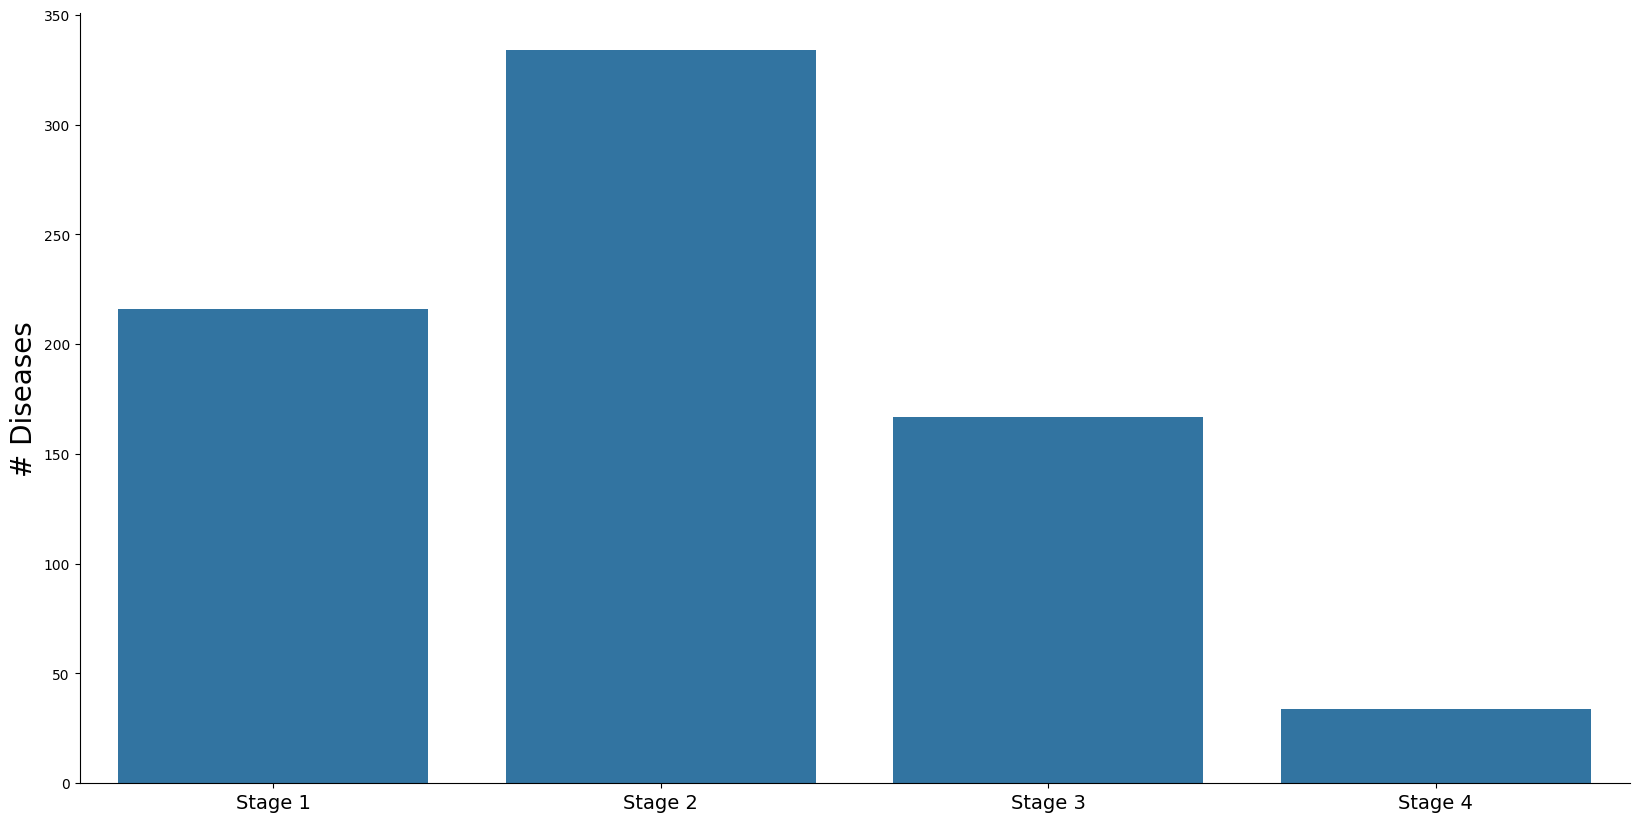

In [67]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Diseases', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [len(set(tot_s1_dis_list)),len(set(tot_s2_dis_list)),len(set(tot_s3_dis_list)),len(set(tot_s4_dis_list))]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.barplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/NumberDiseasesperStage_Male.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/2049185637.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

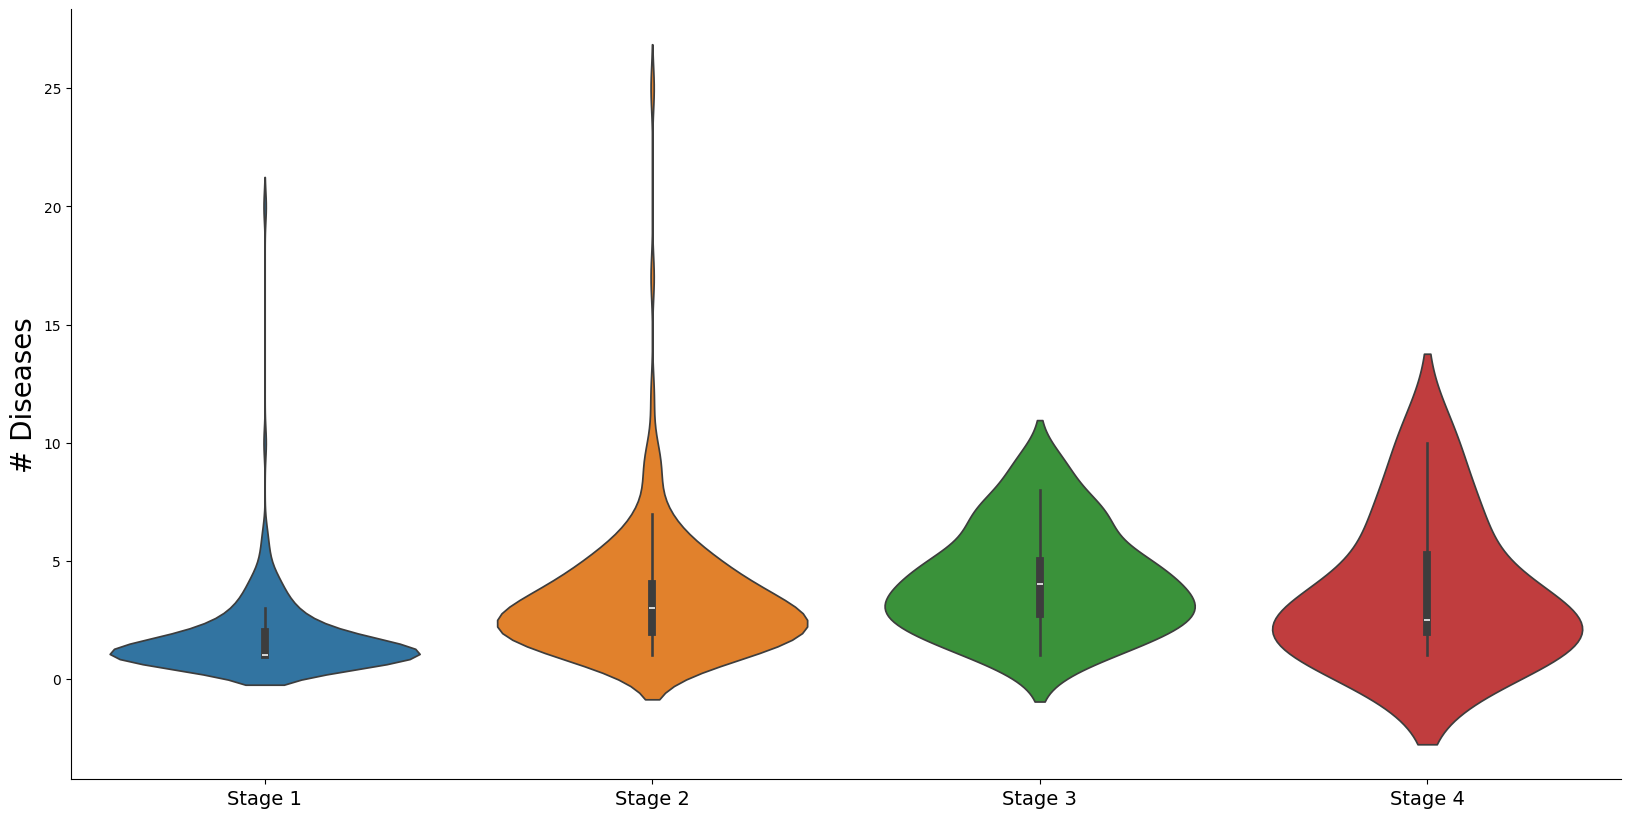

In [68]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Diseases', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [trj_s1_dis_list,trj_s2_dis_list,trj_s3_dis_list,trj_s4_dis_list]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.violinplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/SizeDiseaseTrajperStage_Male.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show


In [69]:

print("The number of disease trajectory in Stage 1 is %s and their average size is %s"%(len(trj_s1_dis_list),np.mean(trj_s1_dis_list)))
print("The number of disease trajectory in Stage 2 is %s and their average size is %s"%(len(trj_s2_dis_list),np.mean(trj_s2_dis_list)))
print("The number of disease trajectory in Stage 3 is %s and their average size is %s"%(len(trj_s3_dis_list),np.mean(trj_s3_dis_list)))
print("The number of disease trajectory in Stage 4 is %s and their average size is %s"%(len(trj_s4_dis_list),np.mean(trj_s4_dis_list)))


The number of disease trajectory in Stage 1 is 195 and their average size is 1.7743589743589743
The number of disease trajectory in Stage 2 is 195 and their average size is 3.4153846153846152
The number of disease trajectory in Stage 3 is 56 and their average size is 4.142857142857143
The number of disease trajectory in Stage 4 is 10 and their average size is 3.7


In [70]:
from scipy import stats
import numpy as np


t_value,p_value=stats.ttest_ind(trj_s1_dis_list,trj_s2_dis_list)
print("T-test Stage 1 vs Stage 2, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(trj_s1_dis_list,trj_s3_dis_list)
print("T-test Stage 1 vs Stage 3, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(trj_s1_dis_list,trj_s4_dis_list)
print("T-test Stage 1 vs Stage 4, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(trj_s2_dis_list,trj_s3_dis_list)
print("T-test Stage 2 vs Stage 3, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(trj_s2_dis_list,trj_s4_dis_list)
print("T-test Stage 2 vs Stage 4, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(trj_s3_dis_list,trj_s4_dis_list)
print("T-test Stage 3 vs Stage 4, p-value is %s"%p_value)

T-test Stage 1 vs Stage 2, p-value is 4.910242746109977e-12
T-test Stage 1 vs Stage 3, p-value is 6.4035121633790725e-15
T-test Stage 1 vs Stage 4, p-value is 0.0015820413112030062
T-test Stage 2 vs Stage 3, p-value is 0.06335437557723493
T-test Stage 2 vs Stage 4, p-value is 0.7442248270628886
T-test Stage 3 vs Stage 4, p-value is 0.5792954445364873


In [89]:
#Let's make a dictionary that takes all the diseases at each stage and their frequency

tot_gen_dis_dict={}
for i in range(1,5):
    tot_dislist = []
    for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
        try:
            tot_dislist.extend(list(stage_dict[i]))
        except:
            pass
    tot_gen_dis_dict[i] = tot_dislist


tot_gen_dis_counter_dict={}
for gen,dislist in tot_gen_dis_dict.items():
    dislist_count=Counter(dislist).most_common()
    tot_gen_dis_counter_dict[gen]=dislist_count

In [91]:
for gen,dislist in tot_gen_dis_counter_dict.items():
    print(gen)
    print(dislist[:3])

1
[('M43', 5), ('K73', 4), ('M42', 4)]
2
[('B18', 9), ('M54', 6), ('K86', 5)]
3
[('H10', 5), ('C22', 4), ('D52', 4)]
4
[('N62', 2), ('D21', 2), ('L08', 2)]


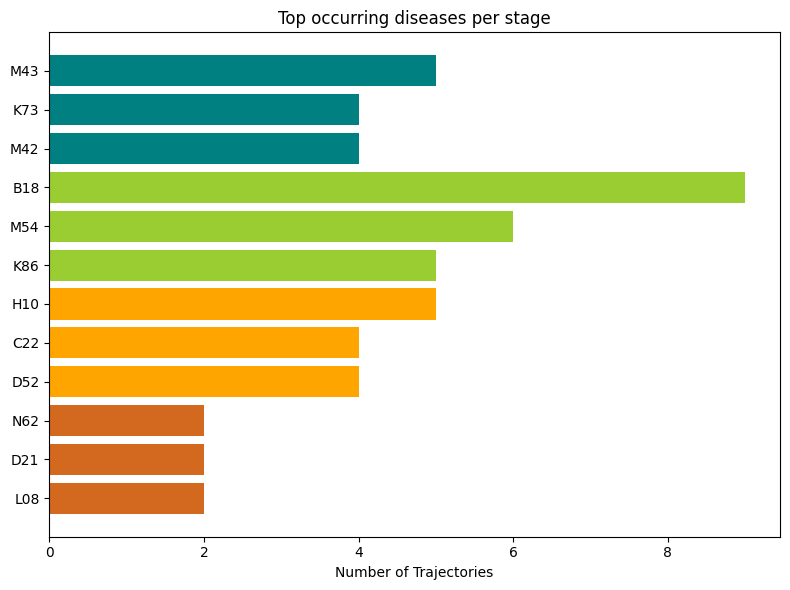

In [34]:
#Let's make it as a barplot
dis_list = ['M43','K73','M42','B18','M54','K86','H10','C22','D52','N62','D21','L08']
frequency_list = [5,4,4,9,6,5,5,4,4,2,2,2]
color_list = ['teal', 'yellowgreen','orange','chocolate']
# Assign colors cycling every three bars
bar_colors = [color_list[(i // 3) % len(color_list)] for i in range(len(dis_list))]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(dis_list))

ax.barh(y_pos, frequency_list, color=bar_colors, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(dis_list)
ax.invert_yaxis()  # Labels read top-to-bottom
ax.set_xlabel('Number of Trajectories')
ax.set_title('Top occurring diseases per stage')

plt.tight_layout()
plt.savefig('Figures/MaleDisFrequencyBarplot.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [ ]:
# M43 = Other deforming dorsopathies
# K73 = Chronic hepatitis, not elsewhere classified
# M42 = Spinal osteochondrosis

# B18 = Chronic viral hepatitis
# M54 = Dorsalgia
# K86 = Other diseases of pancreas

# H10 = Conjunctivitis
# C22 = Malignant neoplasm of liver and intrahepatic bile ducts
# D52 = Folate deficiency anemia

# N62 = Hypertrophy of breast 
# D21 = Other benign neoplasms of connective and other soft tissue
# L08 = Other local infections of skin and subcutaneous tissue

In [71]:
#Now, let's select the total number of genes associated with each stage

tot_s1_gene_list=[]
tot_s2_gene_list=[]
tot_s3_gene_list=[]
tot_s4_gene_list=[]

for dis in tot_s1_dis_list:
    try:
        for gene in icd_genes_ppi_dict[dis]:
            if gene not in tot_s1_gene_list:
                tot_s1_gene_list.append(gene)
    except:
        pass

for dis in tot_s2_dis_list:
    try:
        for gene in icd_genes_ppi_dict[dis]:
            if gene not in tot_s2_gene_list:
                tot_s2_gene_list.append(gene)
    except:
        pass

for dis in tot_s3_dis_list:
    try:
        for gene in icd_genes_ppi_dict[dis]:
            if gene not in tot_s3_gene_list:
                tot_s3_gene_list.append(gene)
    except:
        pass
        
for dis in tot_s4_dis_list:
    try:
        for gene in icd_genes_ppi_dict[dis]:
            if gene not in tot_s4_gene_list:
                tot_s4_gene_list.append(gene)
    except:
        pass



/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/1091752298.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

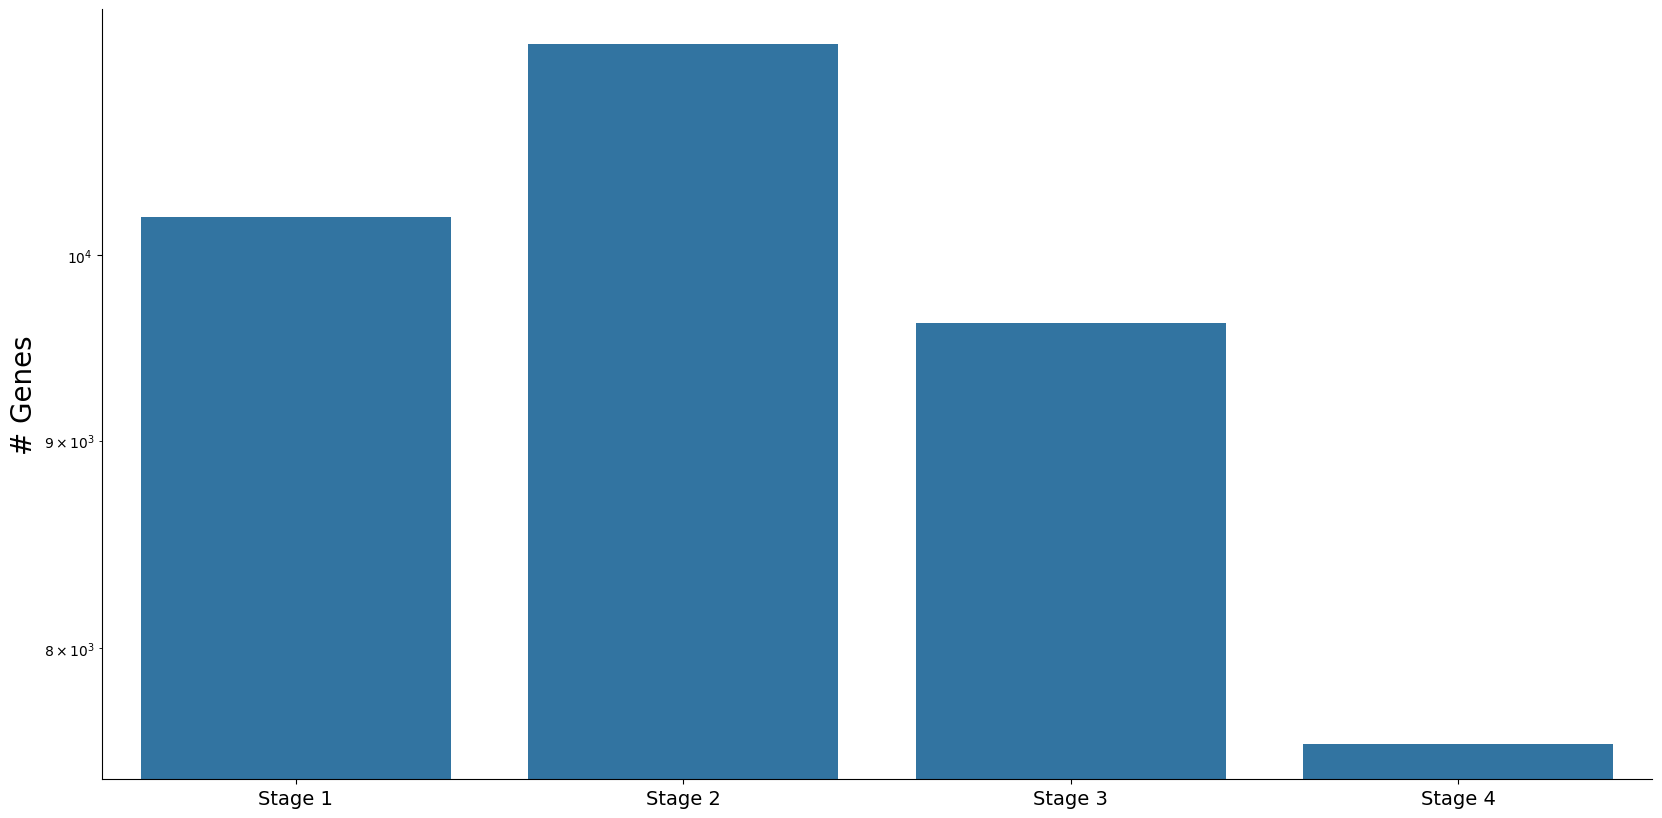

In [72]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

# Set the y-axis to log scale
plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Genes', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [len(tot_s1_gene_list),len(tot_s2_gene_list),len(tot_s3_gene_list),len(tot_s4_gene_list)]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.barplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/NumberGenesperStage_Male.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show

In [73]:

trj_s1_gene_list=[]
trj_s2_gene_list=[]
trj_s3_gene_list=[]
trj_s4_gene_list=[]


for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    genelist_s1 = []
    genelist_s2 = []
    genelist_s3 = []
    genelist_s4 = []
    try:
        for dis in stage_dict[1]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1:
                        genelist_s1.append(gene)
            except:
                pass
    except:
        pass
    trj_s1_gene_list.append(len(genelist_s1))
    try:
        for dis in stage_dict[2]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s2:
                        genelist_s2.append(gene)
            except:
                pass
    except:
        pass
    trj_s2_gene_list.append(len(genelist_s2))
    try:
        for dis in stage_dict[3]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s3:
                        genelist_s3.append(gene)
            except:
                pass
    except:
        pass
    trj_s3_gene_list.append(len(genelist_s3))
    try:
        for dis in stage_dict[4]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s4:
                        genelist_s4.append(gene)
            except:
                pass
    except:
        pass
    trj_s4_gene_list.append(len(genelist_s4))


/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/140844132.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

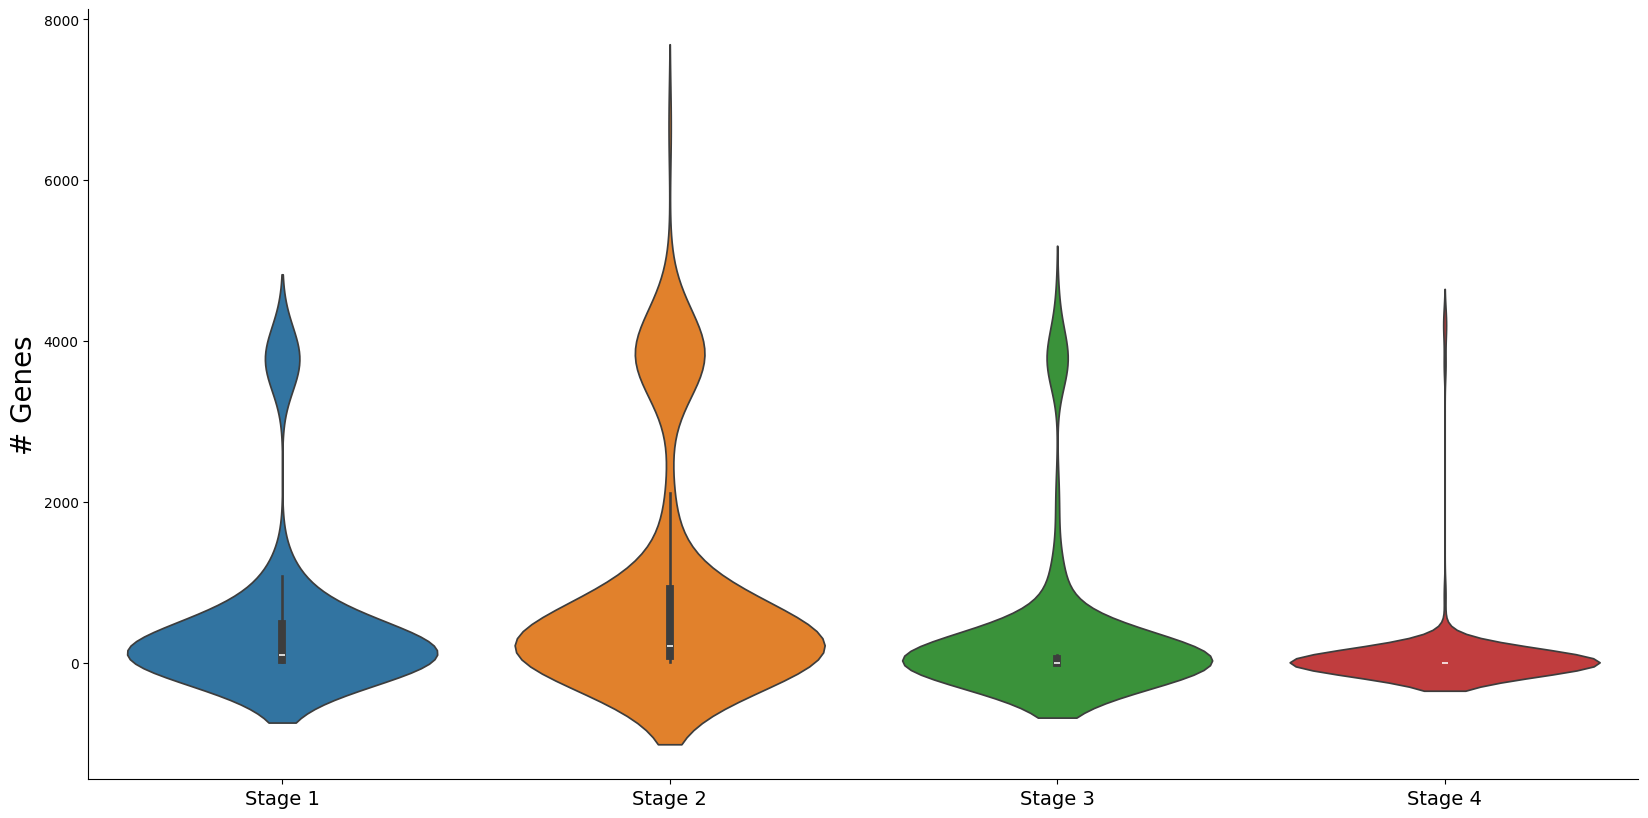

In [74]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Genes', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [trj_s1_gene_list,trj_s2_gene_list,trj_s3_gene_list,trj_s4_gene_list]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.violinplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/SizeGenesTrajperStage_Male.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show


/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/1163765906.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


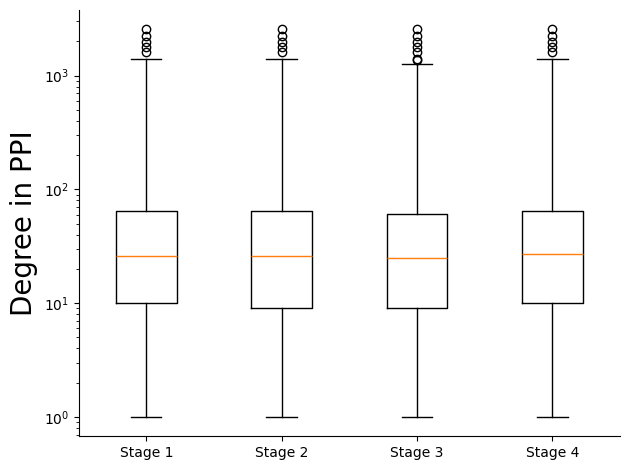

In [75]:
fig1, ax1 = plt.subplots()

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

plt.ylabel('Degree in PPI',fontsize=20)
comparing_group_list= [
            [G_ppi.degree(gene) for gene in tot_s1_gene_list],
            [G_ppi.degree(gene) for gene in tot_s2_gene_list],
            [G_ppi.degree(gene) for gene in tot_s3_gene_list],
            [G_ppi.degree(gene) for gene in tot_s4_gene_list]
]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.yscale("log")
plt.tight_layout()
plt.show()




In [40]:
print(np.median([G_ppi.degree(gene) for gene in tot_s1_gene_list]))
print(np.median([G_ppi.degree(gene) for gene in tot_s2_gene_list]))
print(np.median([G_ppi.degree(gene) for gene in tot_s3_gene_list]))
print(np.median([G_ppi.degree(gene) for gene in tot_s4_gene_list]))


26.0
26.0
25.0
27.0


In [53]:


#Let's make a dictionary that takes all the genes associated with the trajectories at each stage
#Here, we will count the number of trajectories each gene appear for each stage
#This is different than counting the number of diseases, because we are treating the trajectories as meta-diseases
#which means that if we have a trajectory with 5 diseases targeting the same gene, that gene will be counted just one

tot_gen_gene_dict={}
for i in range(1,5):
    tot_genelist = []
    for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
        genelist = []
        try:
            for dis in stage_dict[i]:
                for gene in list(icd_genes_ppi_dict[dis]):
                    if gene not in genelist:
                        genelist.append(gene)
        except:
            pass
        tot_genelist.extend(genelist)
    tot_gen_gene_dict[i] = tot_genelist


tot_gen_gene_counter_dict={}
for gen,genelist in tot_gen_gene_dict.items():
    genelist_count=Counter(genelist).most_common()
    tot_gen_gene_counter_dict[gen]=genelist_count

In [54]:
tot_gen_gene_counter_dict[1][:10]


[('PTGS2', 85),
 ('NR3C1', 83),
 ('SCN4A', 76),
 ('ADRA2A', 69),
 ('SCN5A', 69),
 ('TNF', 68),
 ('OPRM1', 65),
 ('SCN9A', 65),
 ('SCN1A', 64),
 ('GABRA5', 62)]

In [55]:
tot_gen_gene_counter_dict[2][:10]


[('NR3C1', 125),
 ('PTGS2', 120),
 ('SCN4A', 118),
 ('GABRG3', 111),
 ('ADRA2A', 110),
 ('GABRA2', 110),
 ('SCN5A', 110),
 ('GABRG2', 109),
 ('SCN2A', 108),
 ('GABRG1', 108)]

In [56]:
tot_gen_gene_counter_dict[3][:10]


[('NR3C1', 44),
 ('ADRA2A', 38),
 ('ADRA2B', 36),
 ('GABRG3', 35),
 ('SCN4A', 35),
 ('ADRB2', 34),
 ('GABRA5', 33),
 ('OPRM1', 33),
 ('TP53', 33),
 ('SCN5A', 33)]

In [57]:
tot_gen_gene_counter_dict[4][:10]


[('NR3C1', 8),
 ('EGFR', 6),
 ('SCN4A', 6),
 ('GRIN2A', 6),
 ('TP53', 6),
 ('SMAD3', 6),
 ('CDKN2A', 6),
 ('SAA1', 6),
 ('H19', 6),
 ('SAA2', 6)]

In [58]:
for gen,genelist in tot_gen_gene_dict.items():
    print(gen,len(set(genelist)))

1 10221
2 11272
3 9622
4 7575


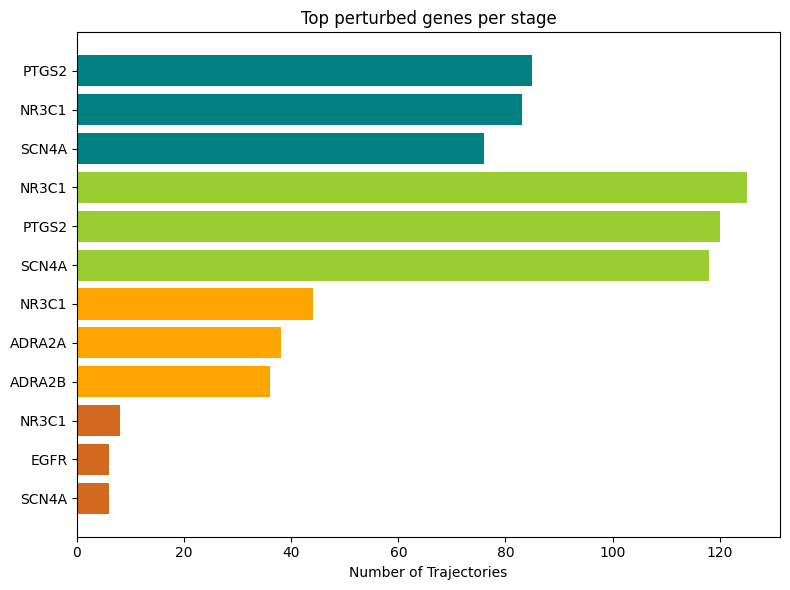

In [61]:
#Let's make it as a barplot
dis_list = ['PTGS2','NR3C1','SCN4A','NR3C1','PTGS2','SCN4A','NR3C1','ADRA2A','ADRA2B','NR3C1','EGFR','SCN4A']
frequency_list = [85,83,76,125,120,118,44,38,36,8,6,6]
color_list = ['teal', 'yellowgreen','orange','chocolate']
# Assign colors cycling every three bars
bar_colors = [color_list[(i // 3) % len(color_list)] for i in range(len(dis_list))]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(dis_list))

ax.barh(y_pos, frequency_list, color=bar_colors, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(dis_list)
ax.invert_yaxis()  # Labels read top-to-bottom
ax.set_xlabel('Number of Trajectories')
ax.set_title('Top perturbed genes per stage')

plt.tight_layout()
plt.savefig('Figures/MaleGeneFrequencyBarplot.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [130]:
#ENRICH

In [62]:

tot_gen_genes_counter_dict_df={}

for gen,genecount in tot_gen_gene_counter_dict.items():
    rank_df=pd.DataFrame(columns=('gene', 'rank'))
    gene_list=[]
    rank_genelist=[]
    for el in genecount:
        gene_list.append(el[0])
        rank_genelist.append(el[1])
    rank_df['gene']=gene_list
    rank_df['rank']=rank_genelist
    rank_df=rank_df.sort_values(by=['rank'],ascending=False)
    tot_gen_genes_counter_dict_df[gen]=rank_df

In [64]:


for gen,rank_df in tot_gen_genes_counter_dict_df.items():
        
    lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
                     processes=4,min_size=3,max_size=5000,outdir=None,   #we impose at least 5 enriched common genes
                     permutation_num=500) # reduce number to speed up testing
    # to save your figure, make sure that ``ofname`` is not None
    ax = dotplot(lib_pre_res.res2d,
                 column="FDR q-val",
                 title='Male KEGG at stage %s'%gen,
                 cmap=plt.cm.viridis,
                 size=6, # adjust dot size
                 figsize=(4,5), cutoff=0.25, ofname='Figures/Male KEGG at stage %s.pdf'%gen, show_ring=False)

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_99885/1894765968.py:3: DeprecationWarning: processes is deprecated; use threads
  lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
2024-12-06 11:50:04,835 [WARNING] Duplicated values found in preranked stats: 99.34% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/gseapy/plot.py:738: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[self.colname] = df[self.colname].replace(0, np.nan).bfill()
/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_99885/1894765968.py:3: DeprecationWarning: processes is deprecated; use threads
  lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_H

In [109]:
tot_gen_genes_degree_dict={}
for gen,genelist in tot_gen_gene_dict.items():
    deg_list=[]
    for gene in set(genelist):
        deg_list.append(G_ppi.degree(gene))
    tot_gen_genes_degree_dict[gen]=deg_list


In [124]:
#Let's calculate the z-score connectivity for the genes associated at each stage in each trajectory

tot_gen_connectivity_zscore_dict={}
for i in range(1,5):
    tot_zscore_list = []
    for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
        genelist_s_i = []
        try:
            for dis in stage_dict[i]:
                genelist_s_i.extend(list(icd_genes_ppi_dict[dis]))
        except:
            pass
        geneset_s_i = set(genelist_s_i)
        geneset_s_i_cl = [i for i in geneset_s_i if str(i)!='nan']
        z_score_s_i = net_modularity(geneset_s_i_cl,G_ppi)
        if str(z_score_s_i)!='nan':
            tot_zscore_list.append(z_score_s_i)
        
    tot_gen_connectivity_zscore_dict[i] = tot_zscore_list

In [126]:

with open('output/tot_gen_connectivity_zscore_dict.pickle', 'wb') as handle:
    pk.dump(tot_gen_connectivity_zscore_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/1387665607.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


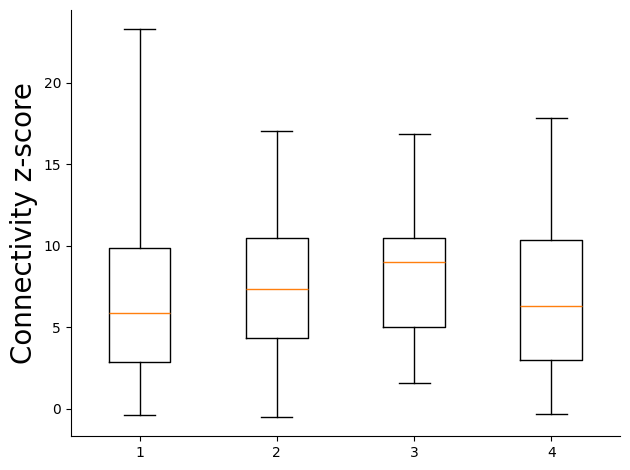

In [176]:


fig1, ax1 = plt.subplots()
labels=list([str(i) for i in tot_gen_connectivity_zscore_dict.keys()])
plt.ylabel('Connectivity z-score',fontsize=20)
comparing_group_list= list(tot_gen_connectivity_zscore_dict.values())
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

#plt.yscale("log")
plt.tight_layout()
plt.savefig('Figures/ConnectivityzscoreperStage_Male.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [148]:


t_value,p_value=stats.ttest_ind(tot_gen_connectivity_zscore_dict[1],tot_gen_connectivity_zscore_dict[2])
print("T-test Stage 1 vs Stage 2, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(tot_gen_connectivity_zscore_dict[1],tot_gen_connectivity_zscore_dict[3])
print("T-test Stage 1 vs Stage 3, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(tot_gen_connectivity_zscore_dict[1],tot_gen_connectivity_zscore_dict[4])
print("T-test Stage 1 vs Stage 4, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(tot_gen_connectivity_zscore_dict[2],tot_gen_connectivity_zscore_dict[3])
print("T-test Stage 2 vs Stage 3, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(tot_gen_connectivity_zscore_dict[2],tot_gen_connectivity_zscore_dict[4])
print("T-test Stage 2 vs Stage 4, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(tot_gen_connectivity_zscore_dict[3],tot_gen_connectivity_zscore_dict[4])
print("T-test Stage 3 vs Stage 4, p-value is %s"%p_value)

T-test Stage 1 vs Stage 2, p-value is 0.14036838820424474
T-test Stage 1 vs Stage 3, p-value is 0.022489823729523323
T-test Stage 1 vs Stage 4, p-value is 0.7064506508526043
T-test Stage 2 vs Stage 3, p-value is 0.13509590062109025
T-test Stage 2 vs Stage 4, p-value is 0.9534025090422011
T-test Stage 3 vs Stage 4, p-value is 0.4733268040782802


In [47]:
#Let's see what happens if we remove the genes that were already perturbed at the previous time points of each trajectory

tot_s1_gene_list=[]
tot_s2_gene_list=[]
tot_s3_gene_list=[]
tot_s4_gene_list=[]


trj_s1_gene_list=[]
trj_s2_gene_list=[]
trj_s3_gene_list=[]
trj_s4_gene_list=[]


for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    genelist_s1 = []
    genelist_s2 = []
    genelist_s3 = []
    genelist_s4 = []
    try:
        for dis in stage_dict[1]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1:
                        genelist_s1.append(gene)
            except:
                pass
    except:
        pass
    tot_s1_gene_list.extend(genelist_s1)
    trj_s1_gene_list.append(len(genelist_s1))
    try:
        for dis in stage_dict[2]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1: 
                        if gene not in genelist_s2: 
                            genelist_s2.append(gene)
            except:
                pass
    except:
        pass
    tot_s2_gene_list.extend(genelist_s2)
    trj_s2_gene_list.append(len(genelist_s2))
    try:
        for dis in stage_dict[3]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1 and gene not in genelist_s2:
                        if gene not in genelist_s3:
                            genelist_s3.append(gene)
            except:
                pass
    except:
        pass
    tot_s3_gene_list.extend(genelist_s3)
    trj_s3_gene_list.append(len(genelist_s3))
    try:
        for dis in stage_dict[4]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1 and gene not in genelist_s2 and gene not in genelist_s3:
                        if gene not in genelist_s4:
                            genelist_s4.append(gene)
            except:
                pass
    except:
        pass
    tot_s4_gene_list.extend(genelist_s4)
    trj_s4_gene_list.append(len(genelist_s4))




/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/2949220159.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

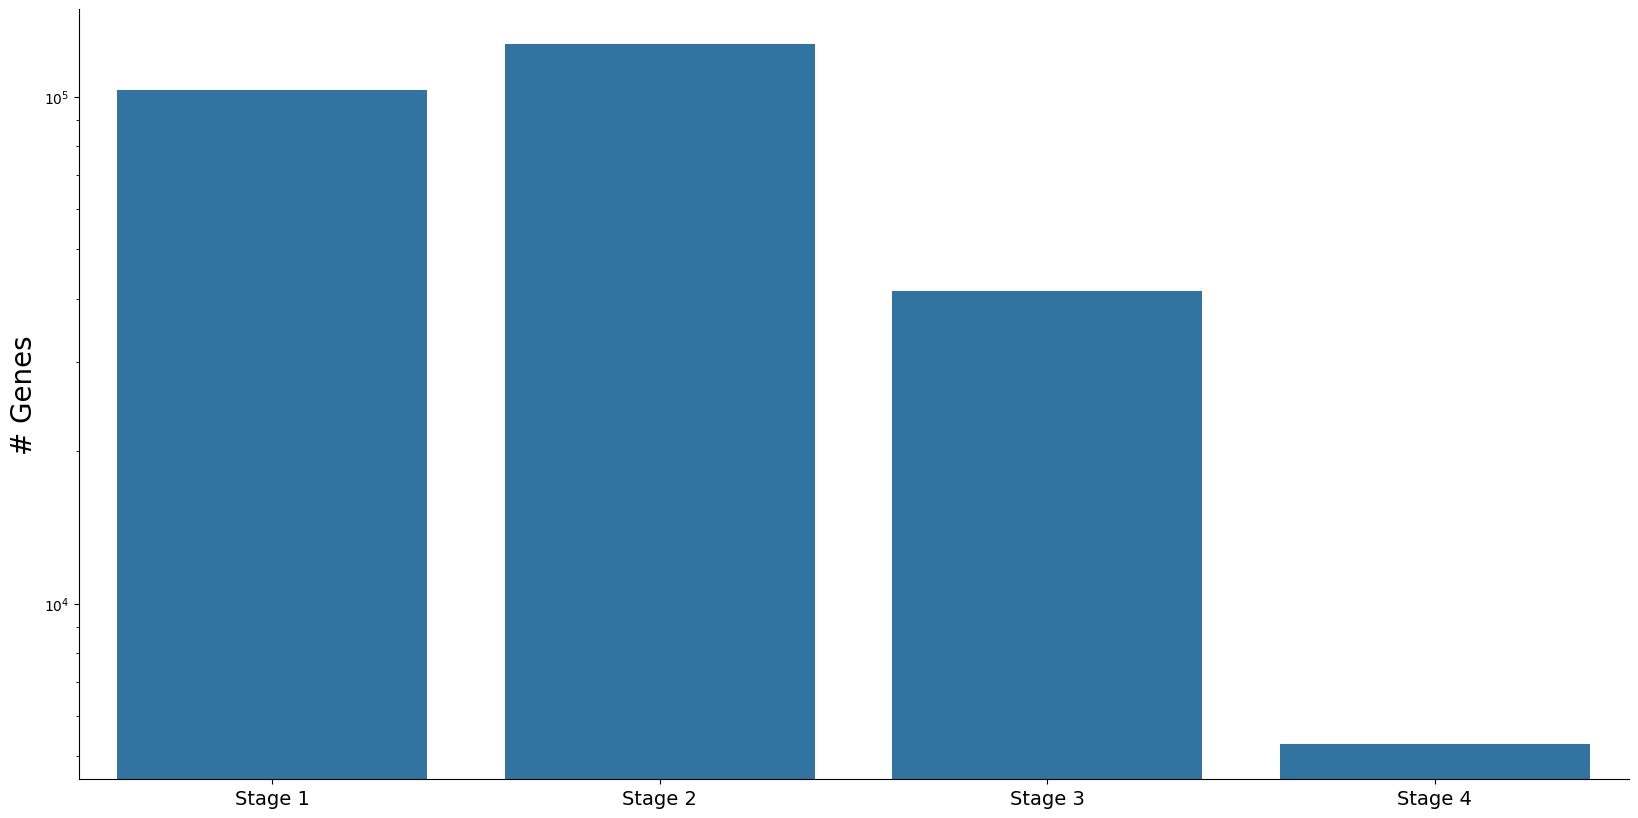

In [48]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

# Set the y-axis to log scale
plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Genes', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [len(tot_s1_gene_list),len(tot_s2_gene_list),len(tot_s3_gene_list),len(tot_s4_gene_list)]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.barplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()
plt.savefig('Figures/NumberGenesperStage_Male_RemovedPriorGenes.pdf',format='pdf',dpi=300, bbox_inches = "tight")

# Show the plot
plt.show

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/2576110373.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

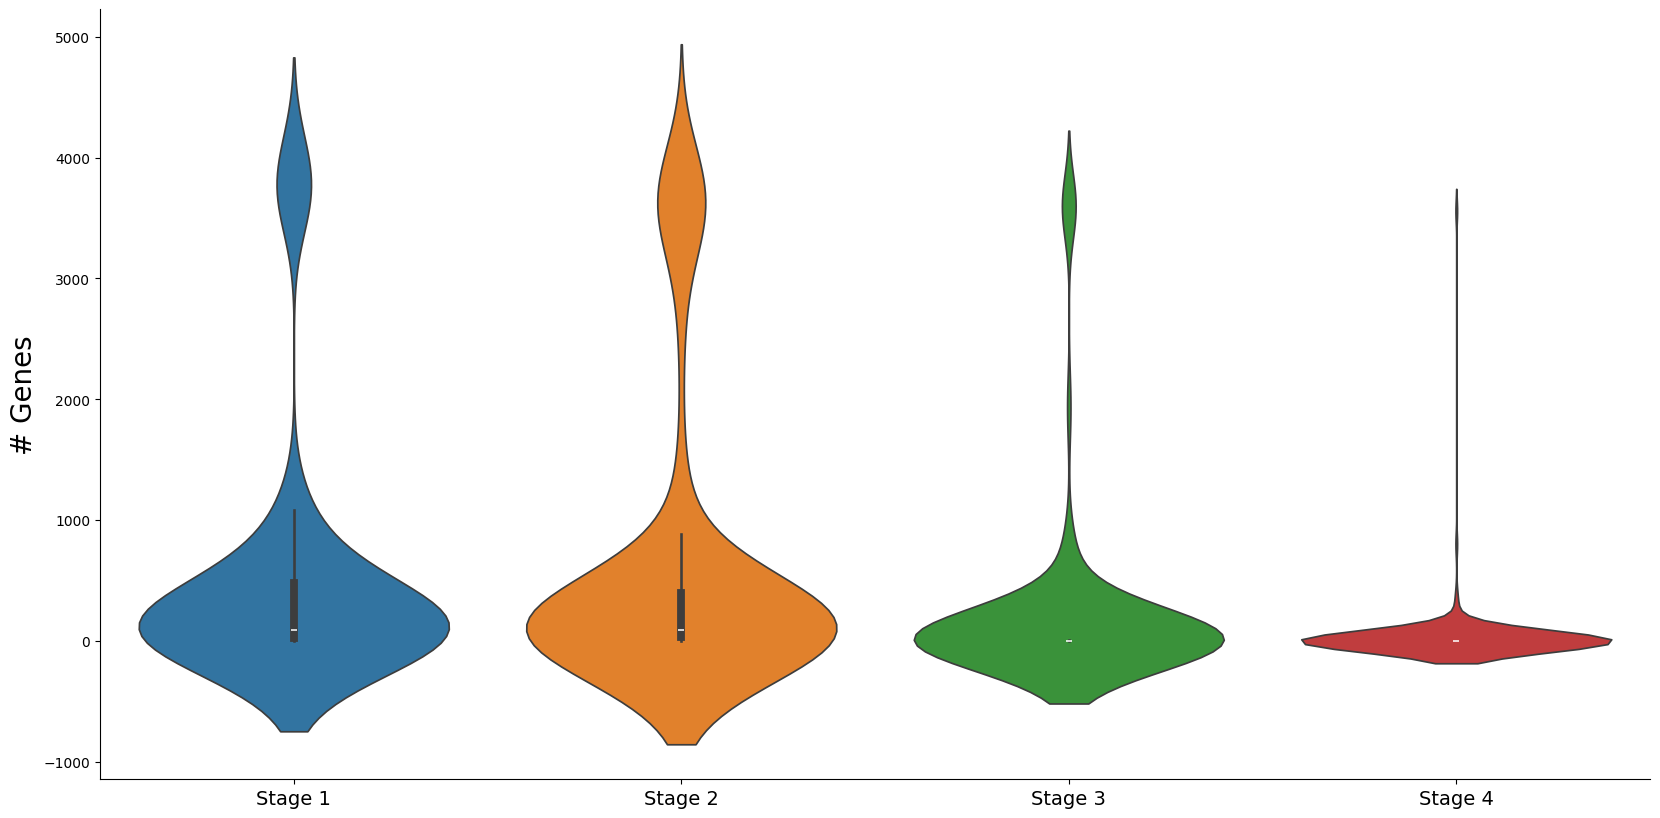

In [49]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Genes', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [trj_s1_gene_list,trj_s2_gene_list,trj_s3_gene_list,trj_s4_gene_list]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.violinplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/SizeGenesTrajperStage_Male_RemovePriorGenes.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show


/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/2669556815.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


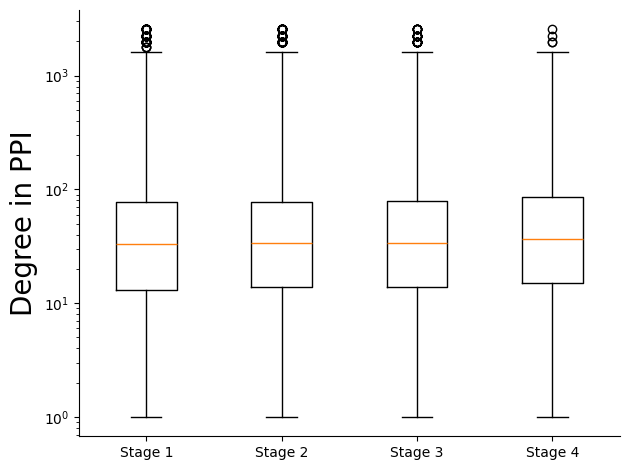

In [50]:
fig1, ax1 = plt.subplots()

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

plt.ylabel('Degree in PPI',fontsize=20)
comparing_group_list= [
            [G_ppi.degree(gene) for gene in tot_s1_gene_list],
            [G_ppi.degree(gene) for gene in tot_s2_gene_list],
            [G_ppi.degree(gene) for gene in tot_s3_gene_list],
            [G_ppi.degree(gene) for gene in tot_s4_gene_list]
]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.yscale("log")
plt.tight_layout()

plt.show()



In [51]:
print(np.median([G_ppi.degree(gene) for gene in tot_s1_gene_list]))
print(np.median([G_ppi.degree(gene) for gene in tot_s2_gene_list]))
print(np.median([G_ppi.degree(gene) for gene in tot_s3_gene_list]))
print(np.median([G_ppi.degree(gene) for gene in tot_s4_gene_list]))

33.0
34.0
34.0
37.0


In [81]:
#Let's make a dictionary that takes all the genes associated with the diseases at each stage

tot_gen_gene_dict_removed_genes={}

    


tot_s1_gene_list=[]
tot_s2_gene_list=[]
tot_s3_gene_list=[]
tot_s4_gene_list=[]


for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    genelist_s1 = []
    genelist_s2 = []
    genelist_s3 = []
    genelist_s4 = []
    try:
        for dis in stage_dict[1]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1:
                        genelist_s1.append(gene)
            except:
                pass
    except:
        pass
    tot_s1_gene_list.extend(genelist_s1)
    try:
        for dis in stage_dict[2]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1: 
                        if gene not in genelist_s2: 
                            genelist_s2.append(gene)
            except:
                pass
    except:
        pass
    tot_s2_gene_list.extend(genelist_s2)
    try:
        for dis in stage_dict[3]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1 and gene not in genelist_s2:
                        if gene not in genelist_s3:
                            genelist_s3.append(gene)
            except:
                pass
    except:
        pass
    tot_s3_gene_list.extend(genelist_s3)
    try:
        for dis in stage_dict[4]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1 and gene not in genelist_s2 and gene not in genelist_s3:
                        if gene not in genelist_s4:
                            genelist_s4.append(gene)
            except:
                pass
    except:
        pass
    tot_s4_gene_list.extend(genelist_s4)
    
tot_gen_gene_dict_removed_genes[1] = tot_s1_gene_list
tot_gen_gene_dict_removed_genes[2] = tot_s2_gene_list
tot_gen_gene_dict_removed_genes[3] = tot_s3_gene_list
tot_gen_gene_dict_removed_genes[4] = tot_s4_gene_list






tot_gen_gene_dict_removed_genes_counter={}
for gen,genelist in tot_gen_gene_dict_removed_genes.items():
    genelist_count=Counter(genelist).most_common()
    tot_gen_gene_dict_removed_genes_counter[gen]=genelist_count

In [82]:
tot_gen_gene_dict_removed_genes_counter[1][:10]


[('PTGS2', 85),
 ('NR3C1', 83),
 ('SCN4A', 76),
 ('ADRA2A', 69),
 ('SCN5A', 69),
 ('TNF', 68),
 ('OPRM1', 65),
 ('SCN9A', 65),
 ('SCN1A', 64),
 ('GABRA5', 62)]

In [83]:
tot_gen_gene_dict_removed_genes_counter[2][:10]


[('ADRB2', 64),
 ('GABRG3', 62),
 ('GABRA2', 61),
 ('GABRG2', 61),
 ('SCN2A', 61),
 ('SCN8A', 59),
 ('SCN3A', 59),
 ('GABRG1', 59),
 ('ADRA2B', 59),
 ('SCN11A', 59)]

In [84]:
tot_gen_gene_dict_removed_genes_counter[3][:10]


[('NF1', 18),
 ('TERT', 18),
 ('TSC1', 17),
 ('GNAS', 17),
 ('SMAD4', 17),
 ('ATRX', 17),
 ('PTEN', 16),
 ('CREBBP', 16),
 ('TUBB4A', 16),
 ('FLT4', 16)]

In [85]:
tot_gen_gene_dict_removed_genes_counter[4][:10]


[('PRDM16', 3),
 ('MAP2K4', 3),
 ('YES1', 3),
 ('FOXP1', 3),
 ('ANK1', 3),
 ('LRP1B', 3),
 ('MSH2', 3),
 ('SPI1', 3),
 ('MAD1L1', 3),
 ('HIC1', 3)]

In [86]:
for gen,genelist in tot_gen_gene_dict_removed_genes_counter.items():
    print(gen,len(set(genelist)))

1 10221
2 9233
3 7517
4 4580


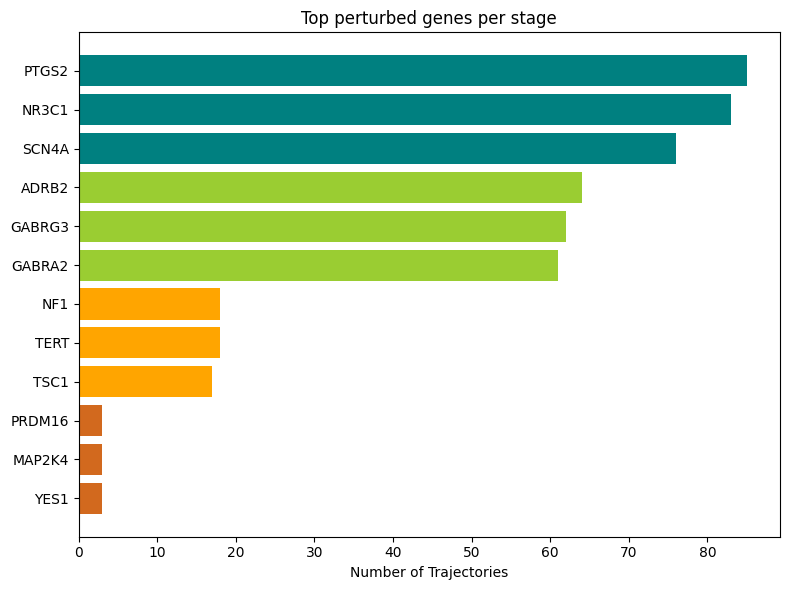

In [88]:
#Let's make it as a barplot
dis_list = ['PTGS2','NR3C1','SCN4A','ADRB2','GABRG3','GABRA2','NF1','TERT','TSC1','PRDM16','MAP2K4','YES1']
frequency_list = [85,83,76,64,62,61,18,18,17,3,3,3]
color_list = ['teal', 'yellowgreen','orange','chocolate']
# Assign colors cycling every three bars
bar_colors = [color_list[(i // 3) % len(color_list)] for i in range(len(dis_list))]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(dis_list))

ax.barh(y_pos, frequency_list, color=bar_colors, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(dis_list)
ax.invert_yaxis()  # Labels read top-to-bottom
ax.set_xlabel('Number of Trajectories')
ax.set_title('Top perturbed genes per stage')

plt.tight_layout()
plt.savefig('Figures/MaleGeneFrequencyBarplot_RemovePriorGenes.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [89]:
#ENRICH

In [90]:

tot_gen_gene_dict_removed_genes_counter_df={}

for gen,genecount in tot_gen_gene_dict_removed_genes_counter.items():
    rank_df=pd.DataFrame(columns=('gene', 'rank'))
    gene_list=[]
    rank_genelist=[]
    for el in genecount:
        gene_list.append(el[0])
        rank_genelist.append(el[1])
    rank_df['gene']=gene_list
    rank_df['rank']=rank_genelist
    rank_df=rank_df.sort_values(by=['rank'],ascending=False)
    tot_gen_gene_dict_removed_genes_counter_df[gen]=rank_df

In [91]:



for gen,rank_df in tot_gen_gene_dict_removed_genes_counter_df.items():
        
    lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
                     processes=4,min_size=3,max_size=5000,outdir=None,   #we impose at least 5 enriched common genes
                     permutation_num=500) # reduce number to speed up testing
    # to save your figure, make sure that ``ofname`` is not None
    ax = dotplot(lib_pre_res.res2d,
                 column="FDR q-val",
                 title='Male KEGG at stage %s'%gen,
                 cmap=plt.cm.viridis,
                 size=6, # adjust dot size
                 figsize=(4,5), cutoff=0.25, ofname='Figures/Male KEGG Removed Prior Genes at stage %s.pdf'%gen, show_ring=False)

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_99885/2040650433.py:3: DeprecationWarning: processes is deprecated; use threads
  lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
2024-12-06 12:13:36,297 [WARNING] Duplicated values found in preranked stats: 99.34% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/gseapy/plot.py:738: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[self.colname] = df[self.colname].replace(0, np.nan).bfill()
/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_99885/2040650433.py:3: DeprecationWarning: processes is deprecated; use threads
  lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_H

In [155]:

trj_deg_dict = {}
for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    genelist_s1 = []
    genelist_s2 = []
    genelist_s3 = []
    genelist_s4 = []
    try:
        for dis in stage_dict[1]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1:
                        genelist_s1.append(gene)
            except:
                pass
    except:
        pass
    try:
        for dis in stage_dict[2]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1: 
                        if gene not in genelist_s2: 
                            genelist_s2.append(gene)
            except:
                pass
    except:
        pass
    try:
        for dis in stage_dict[3]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1 and gene not in genelist_s2:
                        if gene not in genelist_s3:
                            genelist_s3.append(gene)
            except:
                pass
    except:
        pass
    try:
        for dis in stage_dict[4]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1 and gene not in genelist_s2 and gene not in genelist_s3:
                        if gene not in genelist_s4:
                            genelist_s4.append(gene)
            except:
                pass
    except:
        pass
    genelist_s1_deglist = [G_ppi.degree(gene) for gene in genelist_s1]
    genelist_s2_deglist = [G_ppi.degree(gene) for gene in genelist_s2]
    genelist_s3_deglist = [G_ppi.degree(gene) for gene in genelist_s3]
    genelist_s4_deglist = [G_ppi.degree(gene) for gene in genelist_s4]
    trj_deg_dict[trj] = [np.median(genelist_s1_deglist),np.median(genelist_s2_deglist),np.median(genelist_s3_deglist),np.median(genelist_s4_deglist)]





/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [157]:
stage_avg_deg_stage_dict = {}
for i in range(4):
    deglist = []
    for trj,avgdeglist in trj_deg_dict.items():
        if str(avgdeglist[i])!='nan':
            deglist.append(avgdeglist[i])
    stage_avg_deg_stage_dict[i+1] = deglist


/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/564770176.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


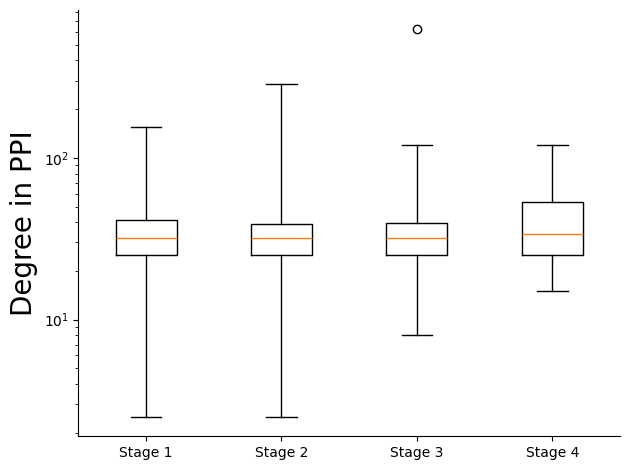

In [177]:
fig1, ax1 = plt.subplots()

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

plt.ylabel('Degree in PPI',fontsize=20)
comparing_group_list= list(stage_avg_deg_stage_dict.values())
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.yscale("log")
plt.tight_layout()
plt.savefig('Figures/MedianDegreeperTrjperStage_Male.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()


In [160]:


t_value,p_value=stats.ttest_ind(stage_avg_deg_stage_dict[1],stage_avg_deg_stage_dict[2])
print("T-test Stage 1 vs Stage 2, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(stage_avg_deg_stage_dict[1],stage_avg_deg_stage_dict[3])
print("T-test Stage 1 vs Stage 3, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(stage_avg_deg_stage_dict[1],stage_avg_deg_stage_dict[4])
print("T-test Stage 1 vs Stage 4, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(stage_avg_deg_stage_dict[2],stage_avg_deg_stage_dict[3])
print("T-test Stage 2 vs Stage 3, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(stage_avg_deg_stage_dict[2],stage_avg_deg_stage_dict[4])
print("T-test Stage 2 vs Stage 4, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(stage_avg_deg_stage_dict[3],stage_avg_deg_stage_dict[4])
print("T-test Stage 3 vs Stage 4, p-value is %s"%p_value)

T-test Stage 1 vs Stage 2, p-value is 0.3403287497197721
T-test Stage 1 vs Stage 3, p-value is 0.0763003333651263
T-test Stage 1 vs Stage 4, p-value is 0.508992624328369
T-test Stage 2 vs Stage 3, p-value is 0.03609742489910448
T-test Stage 2 vs Stage 4, p-value is 0.345145657870057
T-test Stage 3 vs Stage 4, p-value is 0.8186877804967816


In [164]:
#Let's divide the trajectories in those which stage-specific genes degree tend to inrease and those that decreases
#We will just compare the last and the first stage point

ascending_trj = []
descending_trj = []
for trj,deglist in trj_deg_dict.items():
    deglist_cl = [n for n in deglist if str(n)!="nan"]
    if deglist_cl[-1]>deglist_cl[0]:
        ascending_trj.append(trj)
    else:
        descending_trj.append(trj)

print(len(ascending_trj))
print(len(descending_trj))

98
97


In [175]:
for trj in descending_trj:
    if len(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict[trj])>3:
        print(trj,male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict[trj])

119 {1: ['F70'], 2: ['D75', 'F70'], 3: ['D52', 'F10', 'F22', 'F23', 'F70', 'G31', 'L21'], 4: ['C09', 'C10', 'C13', 'E53', 'F22', 'H10', 'N62']}
189 {1: ['M45'], 2: ['E13', 'M45'], 3: ['D35', 'I10', 'I12', 'I72', 'K20', 'M45'], 4: ['I12', 'I13', 'M45']}
197 {1: ['E88'], 2: ['E88', 'F54', 'H47'], 3: ['E66', 'E88'], 4: ['L08']}
198 {1: ['G47'], 2: ['G25', 'G47'], 3: ['E66', 'G25', 'G47'], 4: ['G25', 'H66', 'K46']}
281 {1: ['C67'], 2: ['C67', 'C68'], 3: ['C67', 'C68', 'D41', 'N30'], 4: ['C65', 'C68']}
290 {1: ['K51'], 2: ['D73', 'K51'], 3: ['B96', 'K29', 'K51'], 4: ['D16', 'D21', 'K51', 'L50', 'N10', 'N62']}
318 {1: ['I48'], 2: ['I42', 'I48'], 3: ['I07', 'I34'], 4: ['I08']}


In [172]:
for trj in ascending_trj:
    if len(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict[trj])>3:
        print(trj,male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict[trj])

156 {1: ['K63'], 2: ['D12', 'I84', 'K60', 'K61', 'K62', 'K63'], 3: ['D12', 'I84', 'K60', 'K61', 'K62', 'K64'], 4: ['D21', 'K64']}
176 {1: ['K74'], 2: ['I85', 'K74'], 3: ['C22', 'I85', 'K31', 'K72', 'K74'], 4: ['B99', 'K72']}
390 {1: ['G91', 'I60'], 2: ['D73', 'F52', 'G30', 'G91', 'G99', 'I60', 'L28'], 3: ['E11', 'E55', 'F00', 'F05', 'G30', 'G91', 'H49'], 4: ['A26', 'C76', 'D34', 'G91', 'H59', 'H60', 'L08', 'L28', 'M00', 'N04']}


In [356]:
#Here, we remove the diseases that have been diagnosed already the previous time-point

In [52]:
male_trajectories_dis_sort_bytime_grouped_all_add_evolving_no_repeateddis_dict = {}

for trj, disdict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    dis_dict_gen = {}
    back_dis_state = list(disdict[1])  # Ensure this is a new list to avoid modifying the original

    for i in range(1, len(disdict) + 1):  # Start from the second key
        if i==1:
            dis_dict_gen[i] = disdict[1]
        else:
            i_dis = []
            for dis in disdict[i]:
                if dis not in back_dis_state:
                    i_dis.append(dis)
                    back_dis_state.append(dis)  # Add the new disease to the tracked state
            if i_dis:  # Only include non-empty lists
                dis_dict_gen[i] = i_dis

    if len(dis_dict_gen) > 1:  # Ensure there is more than one state to include in the result
        male_trajectories_dis_sort_bytime_grouped_all_add_evolving_no_repeateddis_dict[trj] = dis_dict_gen

print(len(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_no_repeateddis_dict))

195


In [54]:
#Let's see how many diseases are present at each stage for any trajectory:

tot_s1_dis_list=[]
tot_s2_dis_list=[]
tot_s3_dis_list=[]
tot_s4_dis_list=[]


trj_s1_dis_list=[]
trj_s2_dis_list=[]
trj_s3_dis_list=[]
trj_s4_dis_list=[]

for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_no_repeateddis_dict.items():
    try:
        tot_s1_dis_list.extend(stage_dict[1])
    except:
        pass
    try:
        tot_s2_dis_list.extend(stage_dict[2])
    except:
        pass
    try:
        tot_s3_dis_list.extend(stage_dict[3])
    except:
        pass
    try:
        tot_s4_dis_list.extend(stage_dict[4])
    except:
        pass

for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_no_repeateddis_dict.items():
    try:
        trj_s1_dis_list.append(len(stage_dict[1]))
    except:
        pass
    try:
        trj_s2_dis_list.append(len(stage_dict[2]))
    except:
        pass
    try:
        trj_s3_dis_list.append(len(stage_dict[3]))
    except:
        pass
    try:
        trj_s4_dis_list.append(len(stage_dict[4]))
    except:
        pass
    
    

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/317515394.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

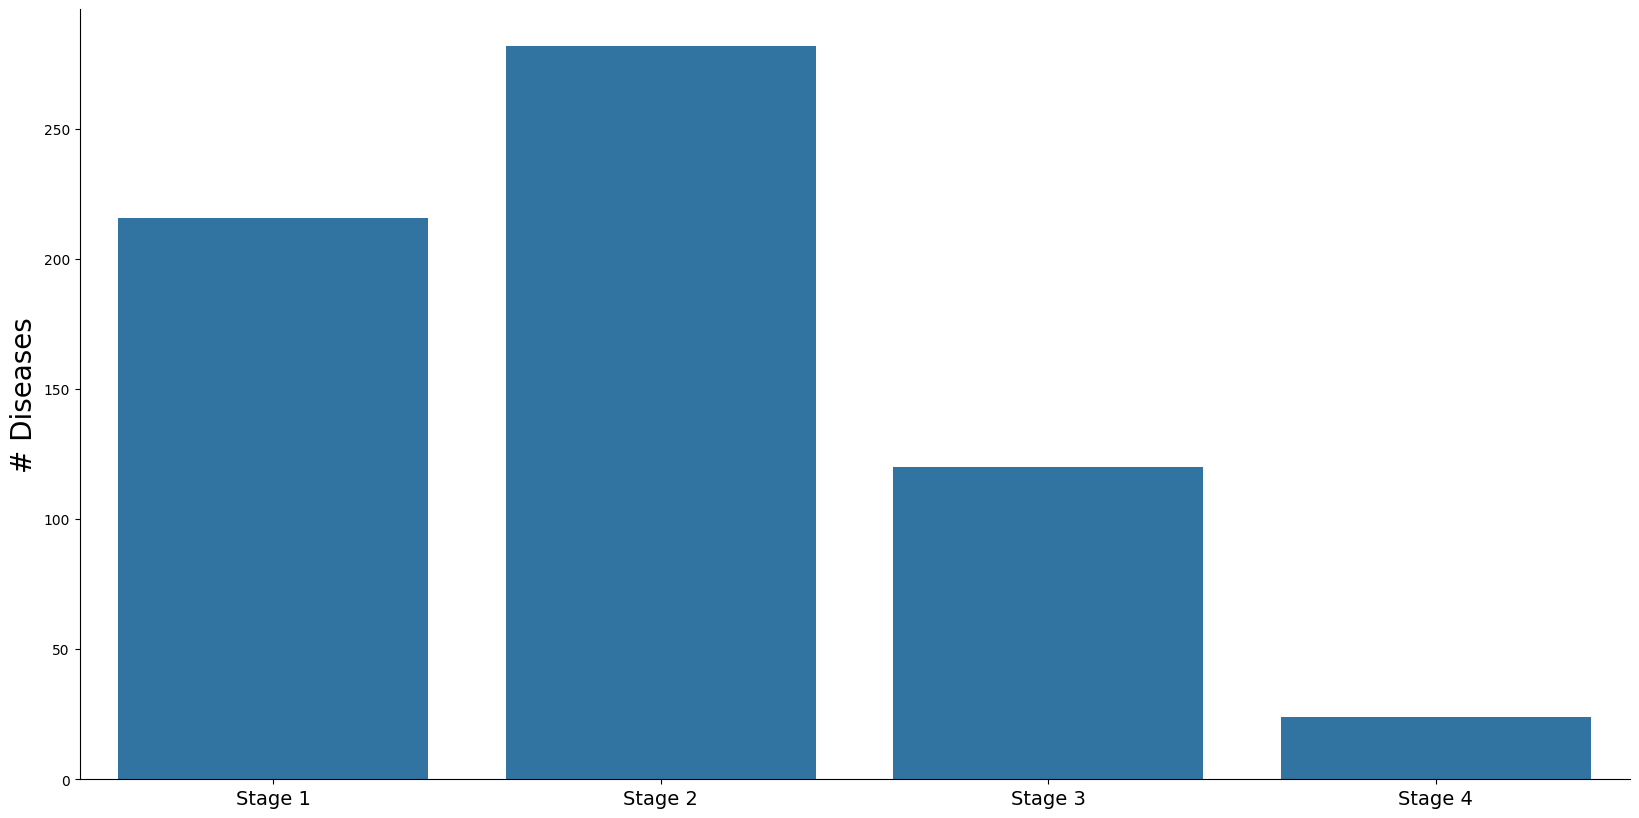

In [56]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Diseases', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [len(set(tot_s1_dis_list)),len(set(tot_s2_dis_list)),len(set(tot_s3_dis_list)),len(set(tot_s4_dis_list))]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.barplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()
plt.savefig('Figures/NumberDiseasesperStage_Male_RemovedPriorDiseases.pdf',format='pdf',dpi=300, bbox_inches = "tight")

# Show the plot
plt.show

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/3739124454.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

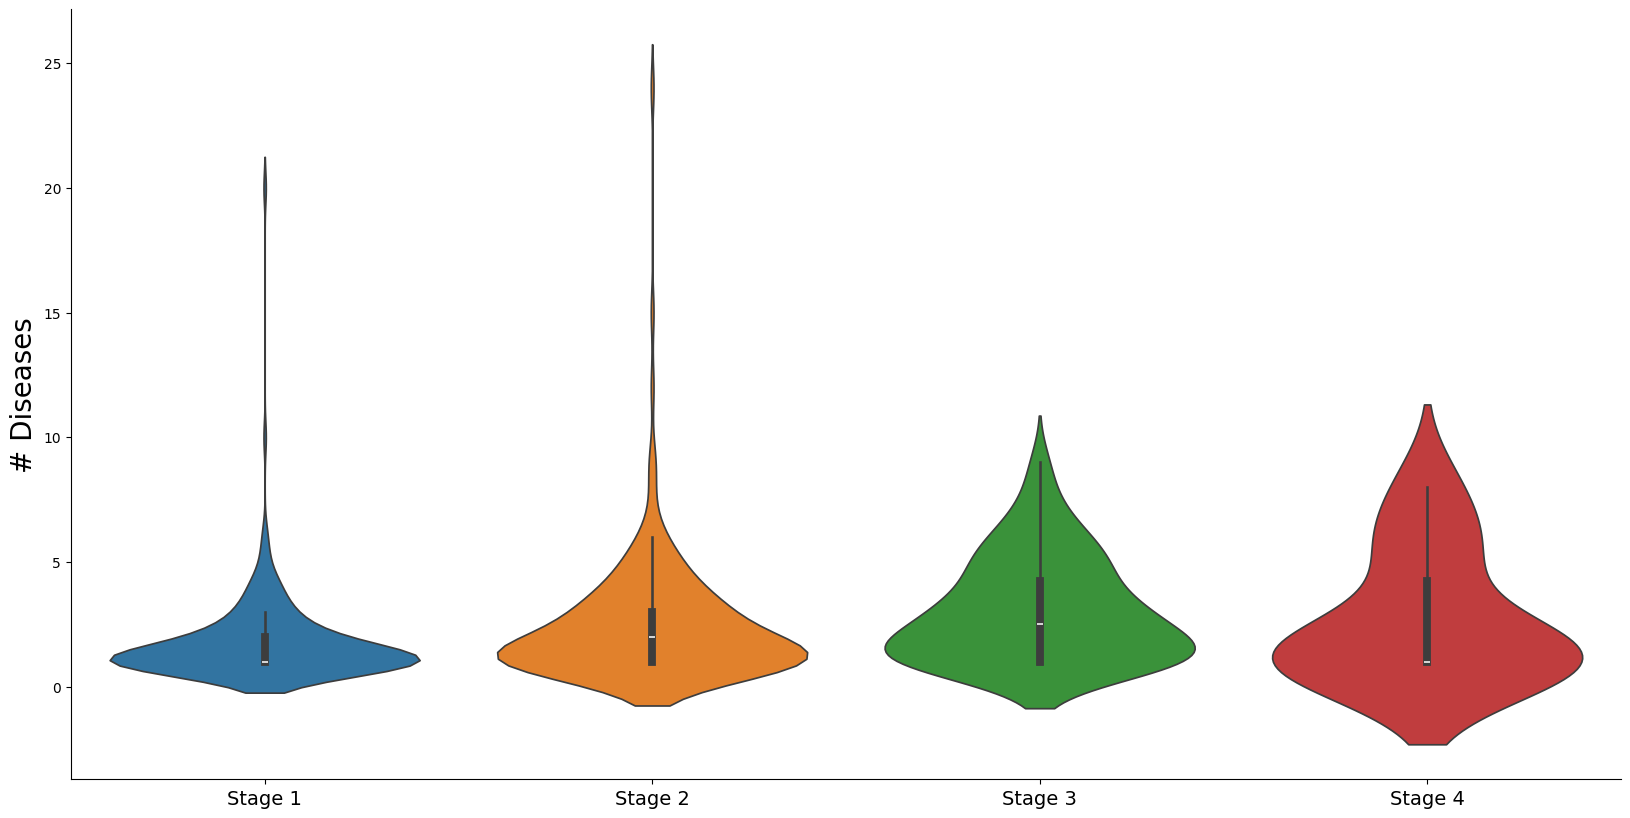

In [57]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Diseases', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [trj_s1_dis_list,trj_s2_dis_list,trj_s3_dis_list,trj_s4_dis_list]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.violinplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/SizeDiseaseTrajperStage_Male_RemovedPriorDiseases.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show



# Female

In [20]:
female_trajectories_df=pd.read_excel('input/All identified trajectories in females. trajectories smaller than 100 members.xlsx')

In [21]:
with open('output/female_trajectories_dict_filtered.pickle', 'rb') as handle:
    female_trajectories_dict_filtered = pk.load(handle)

with open('output/female_trajectories_dict_filtered_unique.pickle', 'rb') as handle:
    female_trajectories_dict_filtered_unique = pk.load(handle)

with open('output/female_trajectories_dict_filtered_unique_agglomerated_genes.pickle', 'rb') as handle:
    female_trajectories_dict_filtered_unique_agglomerated_genes = pk.load(handle)


In [8]:
diverge_pairs_female_df = pd.read_csv("input/Diverge_Pairs/Diverge_Pairs_Females.csv")

In [9]:

female_diverge_pairs_dict_dis_differences = {}
for i,v in diverge_pairs_female_df.iterrows():
    dis_difference_1 = []
    dis_difference_2 = []
    trj_1 = v['Cluster1'].replace("__","-")
    trj_2 = v['Cluster2'].replace("__","-")
    new_trj_1 = trj_1.replace(" ","")
    new_trj_2 = trj_2.replace(" ","")
    dis_list_trj_1 = []
    for distim in new_trj_1.split(","):
        dis_list_trj_1.append(distim.split("-")[0])
    dis_list_trj_2 = []
    for distim in new_trj_2.split(","):
        dis_list_trj_2.append(distim.split("-")[0])
    for dis in dis_list_trj_1:
        if dis not in dis_list_trj_2:
            dis_difference_1.append(dis)
    for dis in dis_list_trj_2:
        if dis not in dis_list_trj_1:
            dis_difference_2.append(dis)
    if len(set(dis_difference_1))>0 and len(set(dis_difference_2))>0:
        female_diverge_pairs_dict_dis_differences[i]=[set(dis_difference_1),set(dis_difference_2)]




In [10]:
#Let's try to extract the genes that are representative of these differences

female_diverge_pairs_dict_gene_differences = {}
for idx,div_pair_list in female_diverge_pairs_dict_dis_differences.items():
    gene_list_1 = []
    gene_list_2 = []
    for dis in div_pair_list[0]:
        try:
            for gene in icd_genes_ppi_dict[dis]:
                if gene not in gene_list_1:
                    gene_list_1.append(gene)
        except:
            pass
    for dis in div_pair_list[1]:
        try:
            for gene in icd_genes_ppi_dict[dis]:
                if gene not in gene_list_2:
                    gene_list_2.append(gene)
        except:
            pass
    female_diverge_pairs_dict_gene_differences[idx]=[set(gene_list_1),set(gene_list_2)]
    

In [16]:
female_diverge_pairs_dict_gene_differences_pval = {}
female_diverge_pairs_dict_gene_differences_fdr = {}


for idx,geneset_list in female_diverge_pairs_dict_gene_differences.items():
    pval_ov = float(overlap_genelists(geneset_list[0],geneset_list[1]))
    female_diverge_pairs_dict_gene_differences_pval[idx] = pval_ov

adj_pval=fdr_adjustment(list(female_diverge_pairs_dict_gene_differences_pval.values()),0.05)
pair_list=list(female_diverge_pairs_dict_gene_differences_pval.keys())
for i in range(len(adj_pval)):
    female_diverge_pairs_dict_gene_differences_fdr[pair_list[i]]=adj_pval[i]
print(len([trj for trj in female_diverge_pairs_dict_gene_differences_fdr.keys() if female_diverge_pairs_dict_gene_differences_fdr[trj]<0.05]))
print(len(female_diverge_pairs_dict_gene_differences))
#19 out of 28 trajectories show gene similarities between the two possibilities

0
28


In [188]:
#Let's check for the degree in the PPI
female_diverge_pairs_dict_gene_degree_differences = {}
for idx,genesetlist in female_diverge_pairs_dict_gene_differences.items():
    deg_list_1 = []
    deg_list_2 = []
    for gene in genesetlist[0]:
        deg_list_1.append(G_ppi.degree(gene))
    for gene in genesetlist[1]:
        deg_list_2.append(G_ppi.degree(gene))
    female_diverge_pairs_dict_gene_degree_differences[idx]=[deg_list_1,deg_list_2]
        

In [198]:
#Let's see whether there are differences in degree by performing a Mann-Withney test


female_diverge_pairs_dict_gene_degree_differences_pval = {}
female_diverge_pairs_dict_gene_degree_differences_fdr = {}

for idx,deg_list in female_diverge_pairs_dict_gene_degree_differences.items():
    try:
        t, p = stats.mannwhitneyu(deg_list[0], deg_list[1])
        if str(p)!='nan':
            female_diverge_pairs_dict_gene_degree_differences_pval[idx] = float(p)
    except:
        pass

adj_pval=fdr_adjustment(list(female_diverge_pairs_dict_gene_degree_differences_pval.values()),0.05)
pair_list=list(female_diverge_pairs_dict_gene_degree_differences_pval.keys())
for i in range(len(adj_pval)):
    female_diverge_pairs_dict_gene_degree_differences_fdr[pair_list[i]]=adj_pval[i]
    
print(len([trj for trj in female_diverge_pairs_dict_gene_degree_differences_fdr.keys() if female_diverge_pairs_dict_gene_degree_differences_fdr[trj]<0.05]))

#Most of these trajectories are statistically significantly different for degree

13


/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/3426048950.py:9: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t, p = stats.mannwhitneyu(deg_list[0], deg_list[1])


In [22]:
female_trajectories_df_copy=pd.DataFrame()
female_trajectories_df_copy['Community ID'] = female_trajectories_df['Community ID']

new_members_of_com_list=[]
for i in female_trajectories_df['Members'].tolist():
    new_i=i.replace("__","-")
    new_new_i=new_i.replace(" ","")
    new_members_of_com_list.append(new_new_i)
female_trajectories_df_copy['Members']=new_members_of_com_list

female_trajectories_df_copy.head()


,Community ID,Members
0,1,"I88-0-9,K56-0-9,K59-0-9,K60-0-9,K56-10-19"
1,2,"A08-0-9,A38-10-19,B01-10-19,H61-10-19,J38-10-19"
2,3,"A38-0-9,B97-0-9,E45-0-9,G47-0-9,H04-0-9,J10-0-..."
3,4,"A41-0-9,C91-0-9,C91-10-19"
4,5,"B00-0-9,B99-0-9,J05-0-9,J31-0-9,J40-0-9,K52-0-..."


In [23]:
female_trajectories_dict={}
for i,v in female_trajectories_df_copy.iterrows():
    dis_list=[]
    for dis in v['Members'].split(','):
        clean_dis=dis.split("-")[0]
        if clean_dis in allsources_icd_gene_dict_unified.keys():
            dis_list.append(dis)
    female_trajectories_dict[v['Community ID']]=dis_list

#Now, let's remove all the trajectories that are obvious (same disease)
female_trajectories_dict_filtered={}
for trj,dislist in female_trajectories_dict.items():
    new_dislist=[]
    if len(dislist)>1:
        for dis in dislist:
            new_dis=dis[:3]
            if new_dis not in new_dislist:
                if new_dis in allsources_icd_gene_dict_unified.keys():
                    new_dislist.append(new_dis)
    if len(new_dislist)>1:
        female_trajectories_dict_filtered[trj]=new_dislist

print(len(female_trajectories_dict_filtered))


352


In [24]:

#First of all, is it always the case that when you have those diseases, their temporal evolution is established?

time_ordered=['0-9','10-19','20-29','30-39','40-49','50-59','60-69','70-79']

female_trajectories_dis_sort_bytime_dict={}
for trj in female_trajectories_dict_filtered.keys():
    dislist = female_trajectories_dict[trj]
    dis_ordered_string=''
    for t in time_ordered:
        for dis in dislist:
            if t in dis:
                dis_ordered_string += str(dis[:3])
                dis_ordered_string += "_"
            else:
                dis_ordered_string += ">"
    female_trajectories_dis_sort_bytime_dict[trj]=dis_ordered_string
                
                


In [25]:
#Now that we have ordered diseases based on their temporal occurance, we can group them to identify only the emergence
#of new diseases
import re
def extract_elements(s):
    # Define a regular expression pattern for one or more '>' characters
    pattern = r'>+'
    
    # Use the re.split function to split the string by the specified pattern
    elements = re.split(pattern, s)
    
    # Filter out empty strings that may have resulted from splitting
    non_empty_elements = list(filter(None, elements))
    
    return non_empty_elements

female_trajectories_dis_sort_bytime_grouped_dict={}
for trj,dis_string in female_trajectories_dis_sort_bytime_dict.items():
    female_trajectories_dis_sort_bytime_grouped_dict[trj]=extract_elements(dis_string)
    

In [26]:
#Let's group disease trajectories based on the stage of occurrence

female_trajectories_dis_sort_bytime_grouped_add_dict={}

for trj,dislist in female_trajectories_dis_sort_bytime_grouped_dict.items():
    if len(dislist)>0:
        cl_dislist=[]
        for dis in dislist:
            new_dislist=dis.split("_")
            cl_dislist.append(new_dislist[:-1])
        female_trajectories_dis_sort_bytime_grouped_add_dict[trj]=cl_dislist

print(len(female_trajectories_dis_sort_bytime_grouped_add_dict))

female_trajectories_dis_sort_bytime_grouped_all_add_dict = {}
for trj, dislist in female_trajectories_dis_sort_bytime_grouped_add_dict.items():
    dis_dict_gen = {}
    for i in range(len(dislist)):
        dis_dict_gen[i + 1] = dislist[i]

    female_trajectories_dis_sort_bytime_grouped_all_add_dict[trj] = dis_dict_gen

print(len(female_trajectories_dis_sort_bytime_grouped_all_add_dict))


with open('output/female_trajectories_dis_sort_bytime_grouped_all_add_dict.pickle', 'wb') as handle:
    pk.dump(female_trajectories_dis_sort_bytime_grouped_all_add_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

352
352


In [27]:
#Let's focus only on those trajectories that have more than a single stage
#Now we will select only those diseases that occur in different period of times
female_trajectories_dis_sort_bytime_grouped_add_dict={}

for trj,dislist in female_trajectories_dis_sort_bytime_grouped_dict.items():
    if len(dislist)>1:
        cl_dislist=[]
        for dis in dislist:
            new_dislist=dis.split("_")
            cl_dislist.append(new_dislist[:-1])
        female_trajectories_dis_sort_bytime_grouped_add_dict[trj]=cl_dislist

print(len(female_trajectories_dis_sort_bytime_grouped_add_dict))

252


In [28]:
female_trajectories_dis_sort_bytime_grouped_all_add_dict = {}
for trj, dislist in female_trajectories_dis_sort_bytime_grouped_add_dict.items():
    dis_dict_gen = {}
    for i in range(len(dislist)):
        dis_dict_gen[i + 1] = dislist[i]

    female_trajectories_dis_sort_bytime_grouped_all_add_dict[trj] = dis_dict_gen

print(len(female_trajectories_dis_sort_bytime_grouped_all_add_dict))

252


In [29]:

#Let's extract only the evolving disease-trajectories
female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict = {}

for trj,gen_dict in female_trajectories_dis_sort_bytime_grouped_all_add_dict.items():
    if len(gen_dict)>1:
        new_dict = {}
        
        # Track diseases seen so far
        seen_diseases = set()
        
        # Iterate through the original dictionary
        for diseases in gen_dict.values():
            # Check if the list contains new diseases
            if any(disease not in seen_diseases for disease in diseases):
                # Add the list to the result with updated index
                new_dict[len(new_dict) + 1] = diseases
                # Update seen diseases with the current list
                seen_diseases.update(diseases)
        if len(new_dict)>1:
            female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict[trj] = new_dict
            
print(len(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict))

159


In [30]:
with open('output/female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.pickle', 'wb') as handle:
    pk.dump(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [30]:
female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict_df = pd.DataFrame.from_dict(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, orient='index')
female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict_df.to_csv("output/female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict_df.tsv",sep="\t")


In [210]:
#Let's see how many diseases are present at each stage for any trajectory:

tot_s1_dis_list=[]
tot_s2_dis_list=[]
tot_s3_dis_list=[]



trj_s1_dis_list=[]
trj_s2_dis_list=[]
trj_s3_dis_list=[]


for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    try:
        tot_s1_dis_list.extend(stage_dict[1])
    except:
        pass
    try:
        tot_s2_dis_list.extend(stage_dict[2])
    except:
        pass
    try:
        tot_s3_dis_list.extend(stage_dict[3])
    except:
        pass



for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    try:
        trj_s1_dis_list.append(len(stage_dict[1]))
    except:
        pass
    try:
        trj_s2_dis_list.append(len(stage_dict[2]))
    except:
        pass
    try:
        trj_s3_dis_list.append(len(stage_dict[3]))
    except:
        pass



/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/3425468583.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

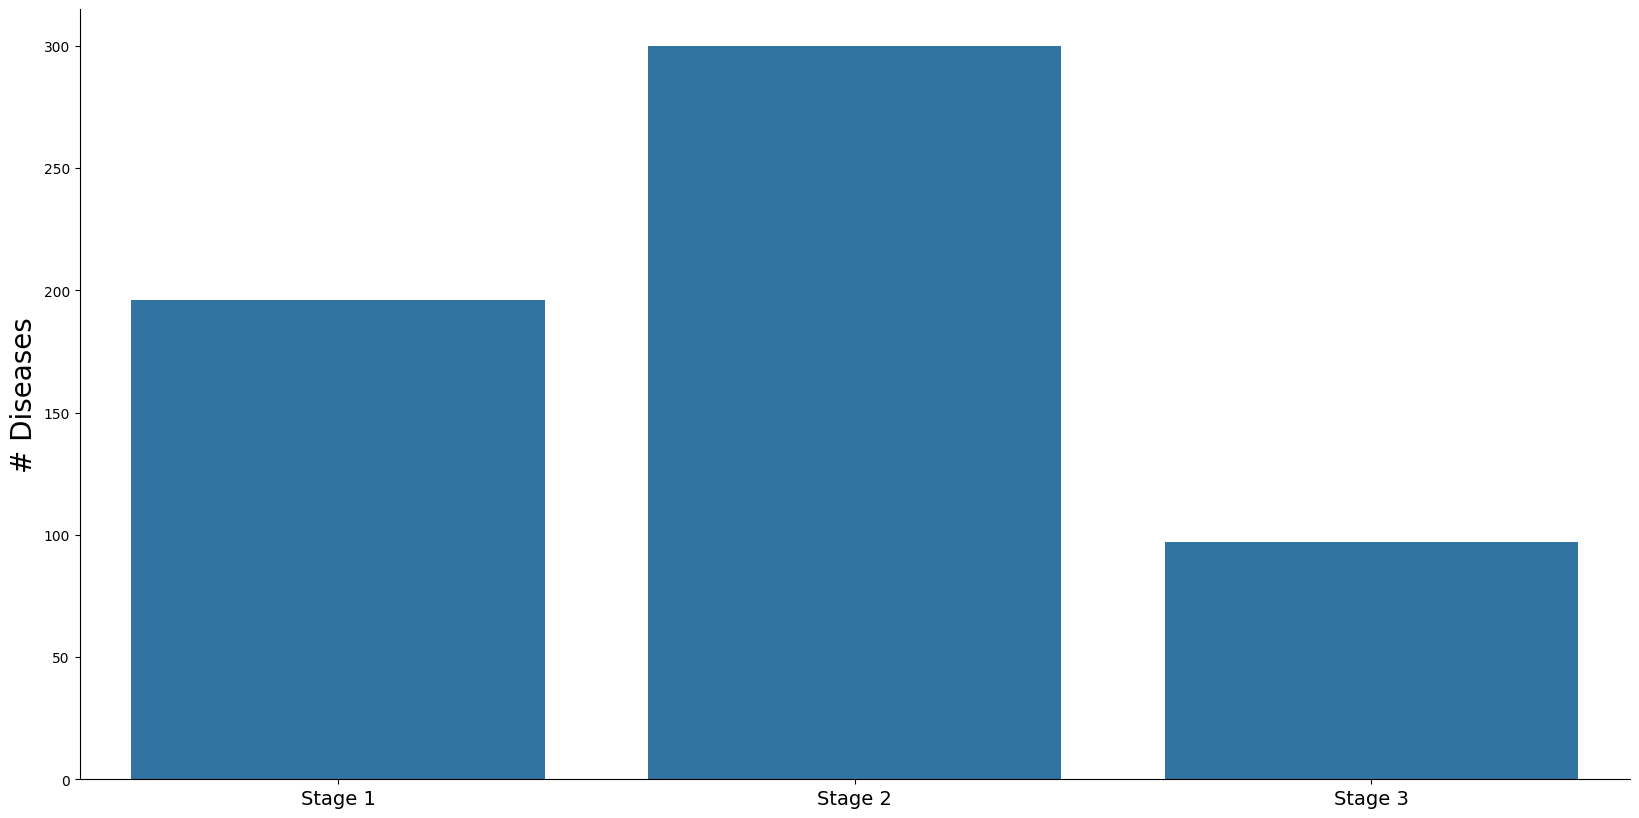

In [211]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Diseases', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [len(set(tot_s1_dis_list)),len(set(tot_s2_dis_list)),len(set(tot_s3_dis_list))]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.barplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/NumberDiseasesperStage_Female.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/3465247787.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

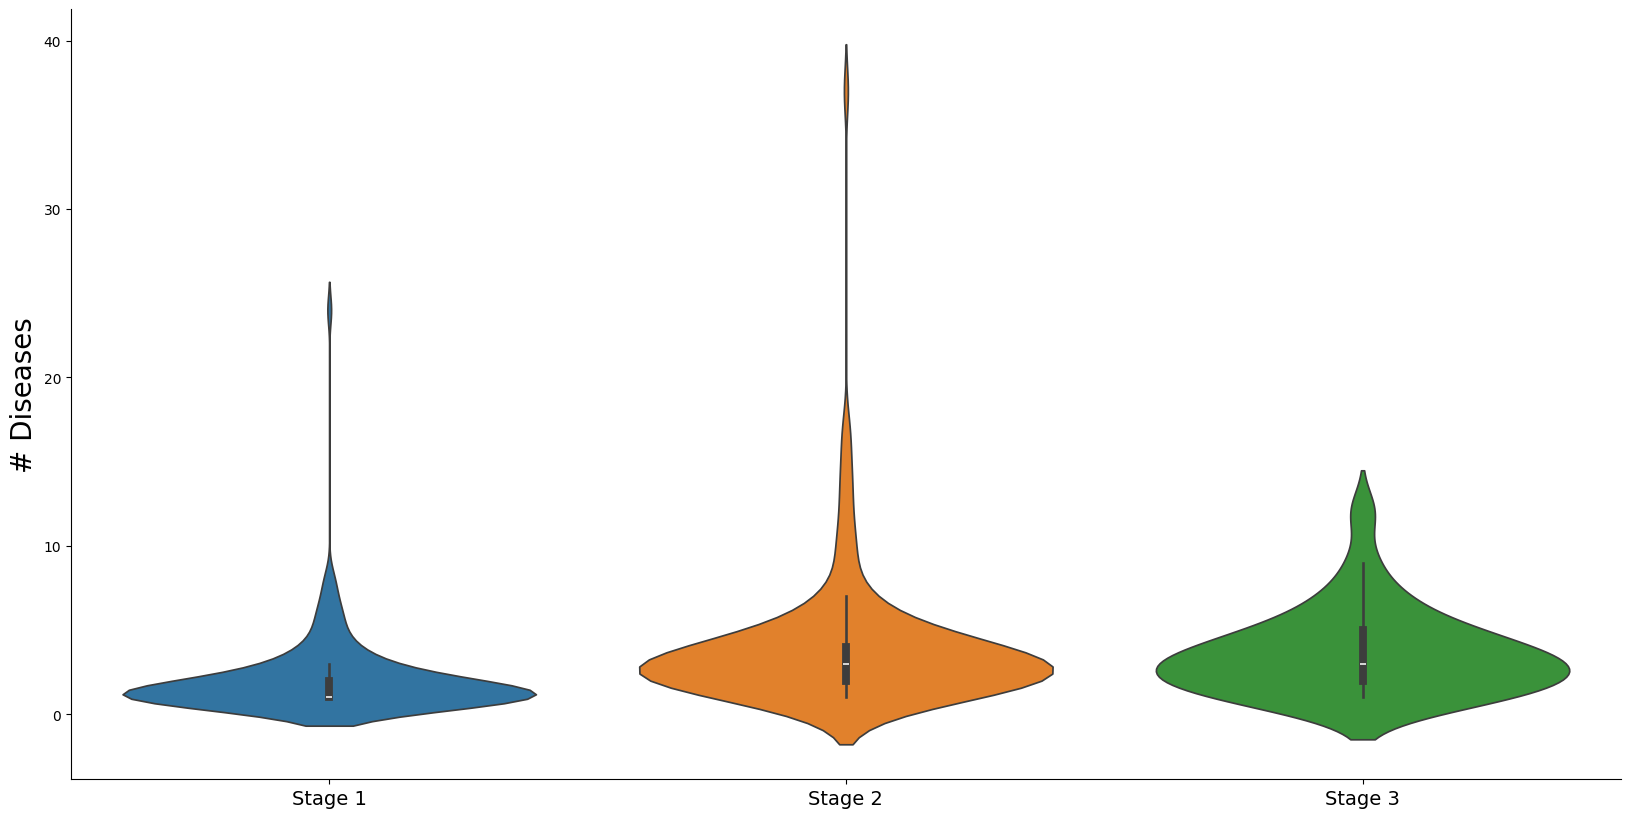

In [212]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Diseases', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [trj_s1_dis_list,trj_s2_dis_list,trj_s3_dis_list]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.violinplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/SizeDiseaseTrajperStage_Female.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show


In [213]:

print("The number of disease trajectory in Stage 1 is %s and their average size is %s"%(len(trj_s1_dis_list),np.mean(trj_s1_dis_list)))
print("The number of disease trajectory in Stage 2 is %s and their average size is %s"%(len(trj_s2_dis_list),np.mean(trj_s2_dis_list)))
print("The number of disease trajectory in Stage 3 is %s and their average size is %s"%(len(trj_s3_dis_list),np.mean(trj_s3_dis_list)))


The number of disease trajectory in Stage 1 is 159 and their average size is 2.050314465408805
The number of disease trajectory in Stage 2 is 159 and their average size is 3.8364779874213837
The number of disease trajectory in Stage 3 is 33 and their average size is 3.5757575757575757


In [214]:
from scipy import stats
import numpy as np


t_value,p_value=stats.ttest_ind(trj_s1_dis_list,trj_s2_dis_list)
print("T-test Stage 1 vs Stage 2, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(trj_s1_dis_list,trj_s3_dis_list)
print("T-test Stage 1 vs Stage 3, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(trj_s2_dis_list,trj_s3_dis_list)
print("T-test Stage 2 vs Stage 3, p-value is %s"%p_value)


T-test Stage 1 vs Stage 2, p-value is 8.03805420425493e-07
T-test Stage 1 vs Stage 3, p-value is 0.0008050572302815874
T-test Stage 2 vs Stage 3, p-value is 0.7086285370553138


In [47]:
#Let's make a dictionary that takes all the diseases at each stage and their frequency

tot_gen_dis_dict={}
for i in range(1,4):
    tot_dislist = []
    for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
        try:
            tot_dislist.extend(list(stage_dict[i]))
        except:
            pass
    tot_gen_dis_dict[i] = tot_dislist


tot_gen_dis_counter_dict={}
for gen,dislist in tot_gen_dis_dict.items():
    dislist_count=Counter(dislist).most_common()
    tot_gen_dis_counter_dict[gen]=dislist_count

In [48]:
for gen,dislist in tot_gen_dis_counter_dict.items():
    print(gen)
    print(dislist[:3])

1
[('M51', 7), ('D70', 5), ('G95', 5)]
2
[('M48', 9), ('E65', 6), ('M50', 6)]
3
[('H65', 3), ('G63', 3), ('G57', 3)]


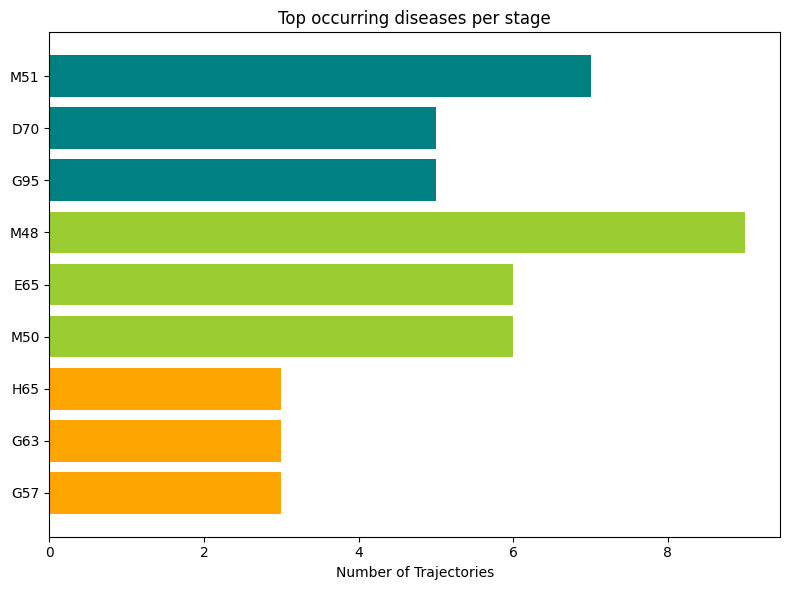

In [35]:
#Let's make it as a barplot
dis_list = ['M51','D70','G95','M48','E65','M50','H65','G63','G57']
frequency_list = [7,5,5,9,6,6,3,3,3]
color_list = ['teal', 'yellowgreen','orange']
# Assign colors cycling every three bars
bar_colors = [color_list[(i // 3) % len(color_list)] for i in range(len(dis_list))]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(dis_list))

ax.barh(y_pos, frequency_list, color=bar_colors, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(dis_list)
ax.invert_yaxis()  # Labels read top-to-bottom
ax.set_xlabel('Number of Trajectories')
ax.set_title('Top occurring diseases per stage')

plt.tight_layout()
plt.savefig('Figures/FemaleDisFrequencyBarplot.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [ ]:
# M51 = Thoracic, thoracolumbar, and lumbosacral intervertebral disc disorders
# D70 = Neutropenia
# G95 = Other and unspecified diseases of spinal cord

# M48 = Other spondylopathies
# E65 = Localized adiposity
# M50 = Cervical disc disorders

# H65 = Nonsuppurative otitis media
# G63 = Polyneuropathy in diseases classified elsewhere
# G57 = Mononeuropathies of lower limb


In [217]:
#Now, let's select the total number of genes associated with each stage

tot_s1_gene_list=[]
tot_s2_gene_list=[]
tot_s3_gene_list=[]


for dis in tot_s1_dis_list:
    try:
        for gene in icd_genes_ppi_dict[dis]:
            if gene not in tot_s1_gene_list:
                tot_s1_gene_list.append(gene)
    except:
        pass

for dis in tot_s2_dis_list:
    try:
        for gene in icd_genes_ppi_dict[dis]:
            if gene not in tot_s2_gene_list:
                tot_s2_gene_list.append(gene)
    except:
        pass

for dis in tot_s3_dis_list:
    try:
        for gene in icd_genes_ppi_dict[dis]:
            if gene not in tot_s3_gene_list:
                tot_s3_gene_list.append(gene)
    except:
        pass
        



/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/3999610723.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

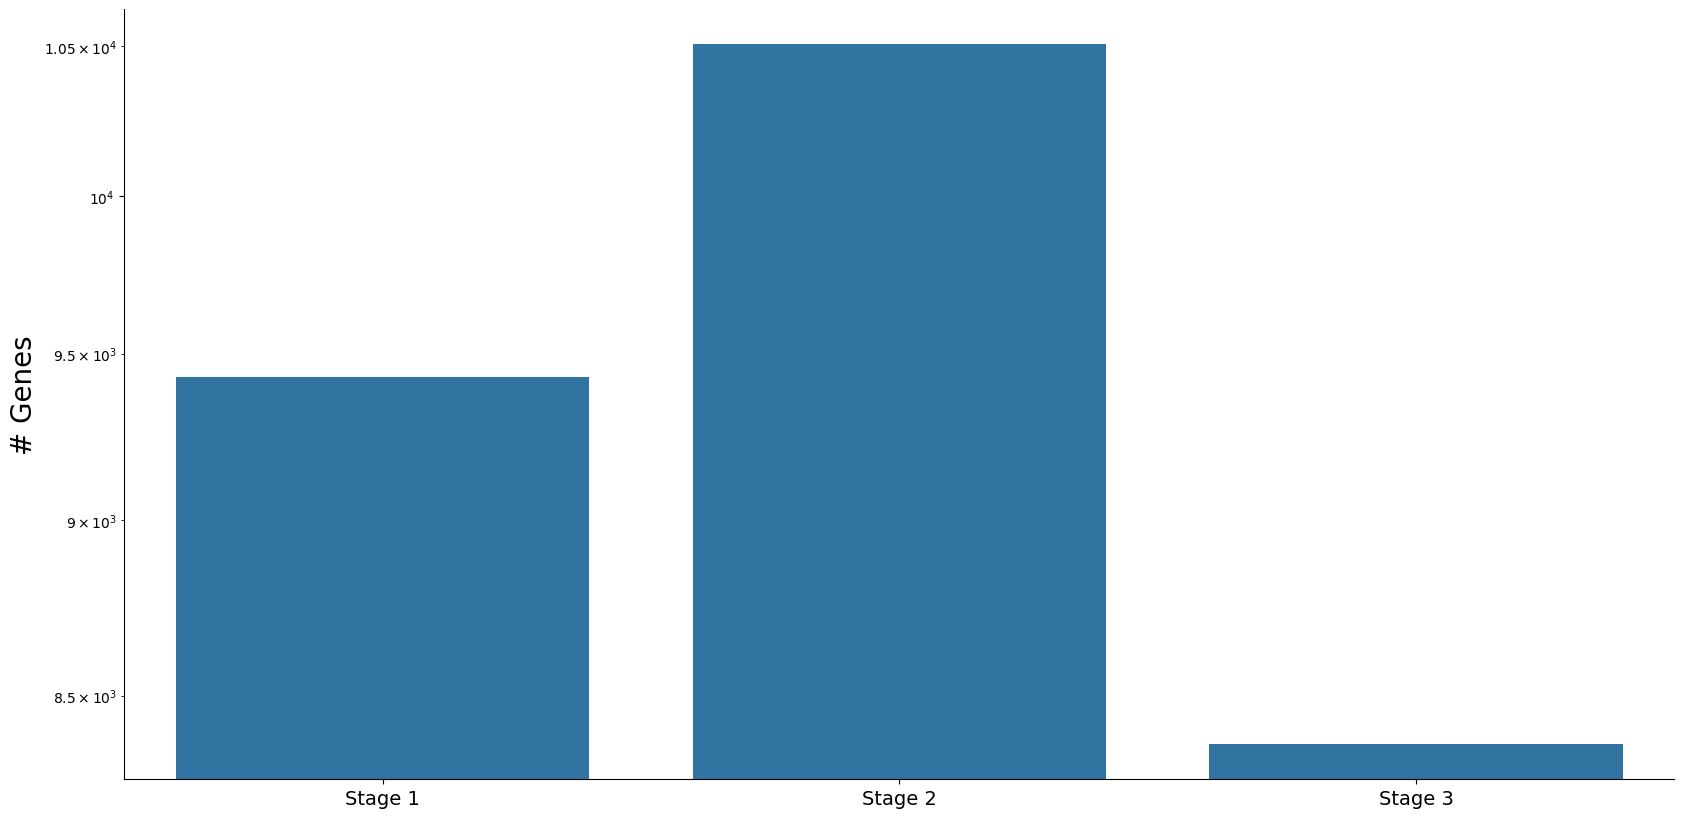

In [218]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

# Set the y-axis to log scale
plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Genes', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [len(tot_s1_gene_list),len(tot_s2_gene_list),len(tot_s3_gene_list)]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.barplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/NumberGenesperStage_Female.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show

In [219]:

trj_s1_gene_list=[]
trj_s2_gene_list=[]
trj_s3_gene_list=[]



for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    genelist_s1 = []
    genelist_s2 = []
    genelist_s3 = []
    try:
        for dis in stage_dict[1]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1:
                        genelist_s1.append(gene)
            except:
                pass
    except:
        pass
    trj_s1_gene_list.append(len(genelist_s1))
    try:
        for dis in stage_dict[2]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s2:
                        genelist_s2.append(gene)
            except:
                pass
    except:
        pass
    trj_s2_gene_list.append(len(genelist_s2))
    try:
        for dis in stage_dict[3]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s3:
                        genelist_s3.append(gene)
            except:
                pass
    except:
        pass
    trj_s3_gene_list.append(len(genelist_s3))


/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/2516104549.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

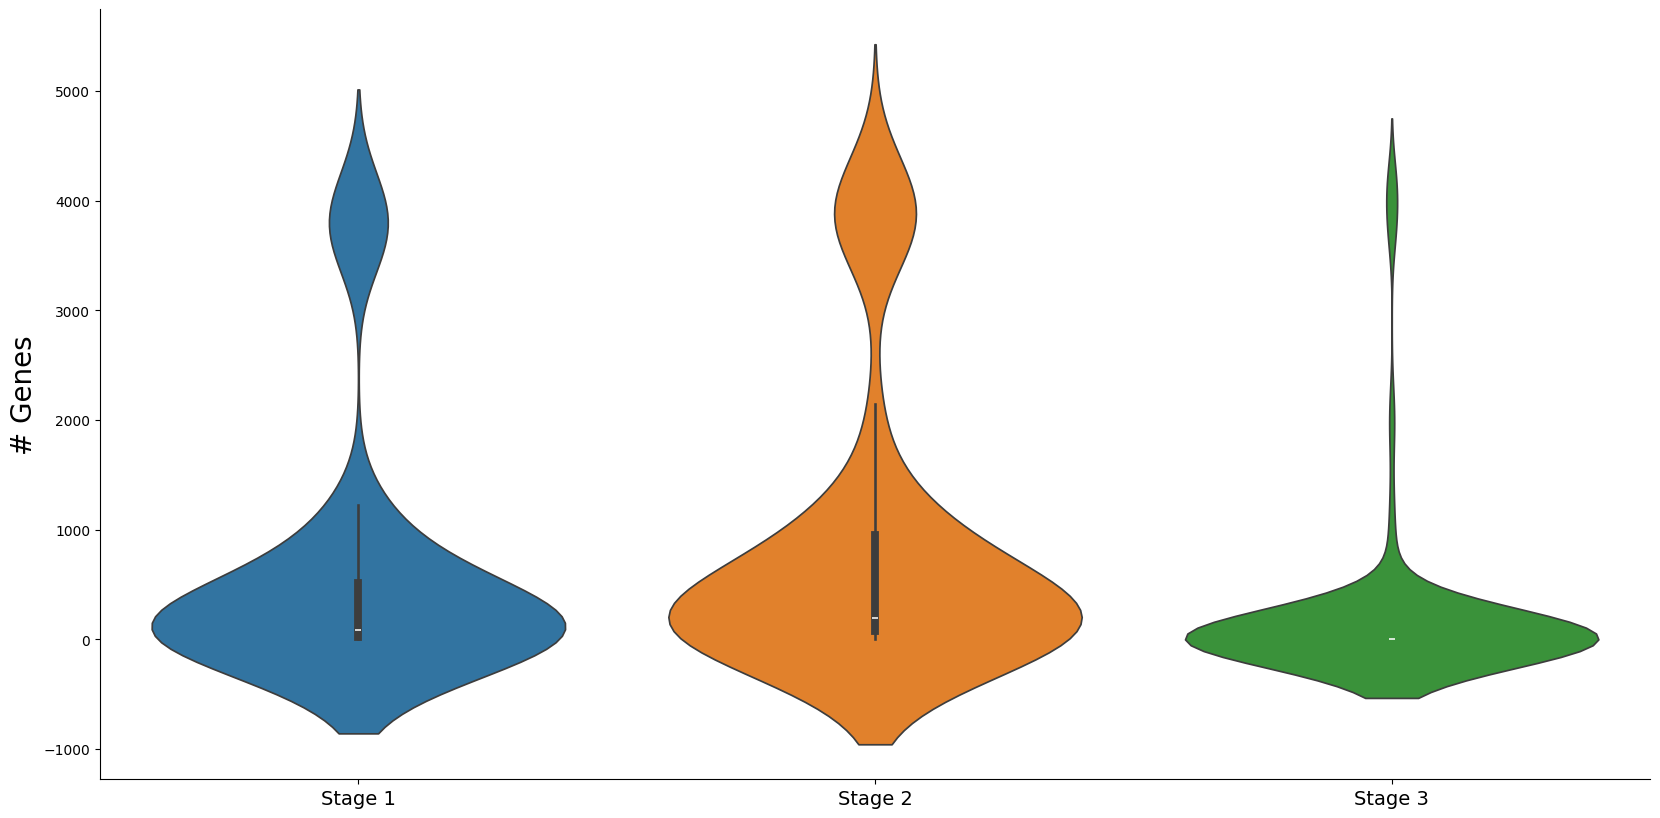

In [220]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Genes', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [trj_s1_gene_list,trj_s2_gene_list,trj_s3_gene_list]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.violinplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/SizeGenesTrajperStage_Female.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show


/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/402669577.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


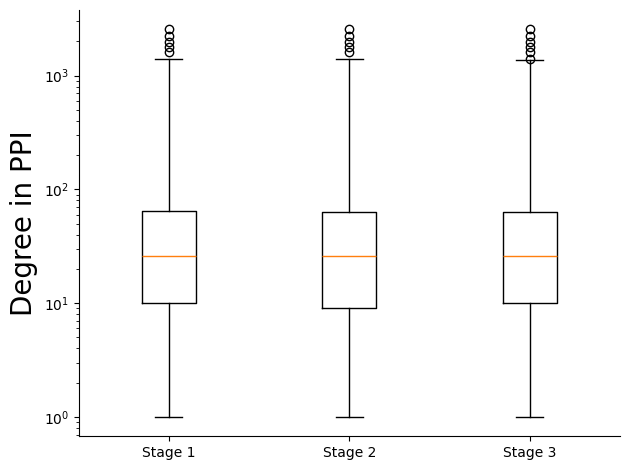

In [221]:
fig1, ax1 = plt.subplots()

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

plt.ylabel('Degree in PPI',fontsize=20)
comparing_group_list= [
            [G_ppi.degree(gene) for gene in tot_s1_gene_list],
            [G_ppi.degree(gene) for gene in tot_s2_gene_list],
            [G_ppi.degree(gene) for gene in tot_s3_gene_list]
]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.yscale("log")
plt.tight_layout()
plt.show()




In [222]:
print(np.median([G_ppi.degree(gene) for gene in tot_s1_gene_list]))
print(np.median([G_ppi.degree(gene) for gene in tot_s2_gene_list]))
print(np.median([G_ppi.degree(gene) for gene in tot_s3_gene_list]))



26.0
26.0
26.0


In [65]:

#Let's make a dictionary that takes all the genes associated with the trajectories at each stage
#Here, we will count the number of trajectories each gene appear for each stage
#This is different than counting the number of diseases, because we are treating the trajectories as meta-diseases
#which means that if we have a trajectory with 5 diseases targeting the same gene, that gene will be counted just one

tot_gen_gene_dict={}
for i in range(1,4):
    tot_genelist = []
    for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
        genelist = []
        try:
            for dis in stage_dict[i]:
                for gene in list(icd_genes_ppi_dict[dis]):
                    if gene not in genelist:
                        genelist.append(gene)
        except:
            pass
        tot_genelist.extend(genelist)
    tot_gen_gene_dict[i] = tot_genelist


tot_gen_gene_counter_dict={}
for gen,genelist in tot_gen_gene_dict.items():
    genelist_count=Counter(genelist).most_common()
    tot_gen_gene_counter_dict[gen]=genelist_count

In [66]:
tot_gen_gene_counter_dict[1][:10]


[('NR3C1', 81),
 ('SCN4A', 68),
 ('ADRA2A', 67),
 ('PTGS2', 67),
 ('SCN5A', 65),
 ('SCN9A', 63),
 ('ADRA2B', 61),
 ('SCN3A', 58),
 ('SCN1A', 58),
 ('SCN8A', 58)]

In [67]:
tot_gen_gene_counter_dict[2][:10]


[('NR3C1', 99),
 ('SCN4A', 93),
 ('PTGS2', 92),
 ('ADRA2A', 87),
 ('SCN5A', 86),
 ('GABRA1', 84),
 ('ADRA2B', 84),
 ('GABRG3', 83),
 ('OPRM1', 83),
 ('TNF', 83)]

In [68]:
tot_gen_gene_counter_dict[3][:10]


[('NR3C1', 19),
 ('TNF', 19),
 ('GABRA1', 17),
 ('GABRG3', 17),
 ('GABRA5', 16),
 ('GABRG1', 16),
 ('GABRA2', 16),
 ('GABRA3', 16),
 ('GABRG2', 16),
 ('HLA-DQA1', 16)]

In [69]:
for gen,genelist in tot_gen_gene_dict.items():
    print(gen,len(set(genelist)))

1 9428
2 10507
3 8367


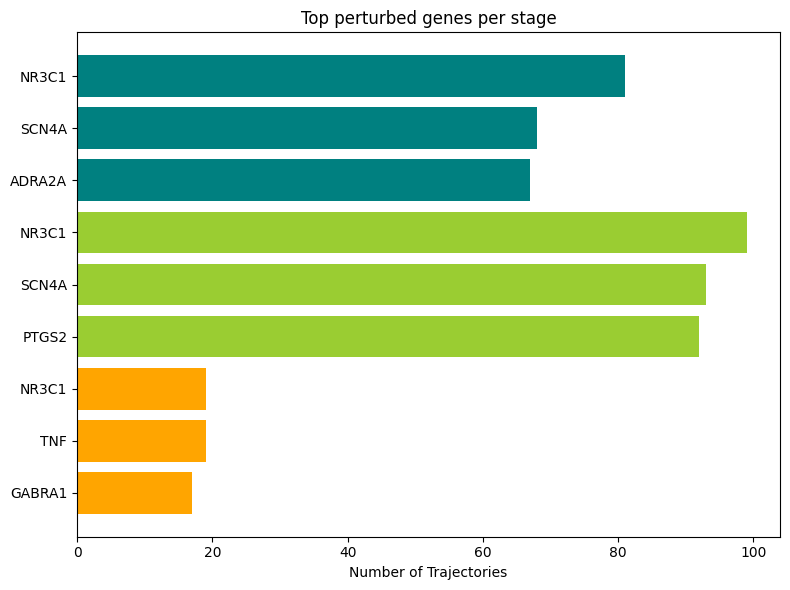

In [74]:
#Let's make it as a barplot
dis_list = ['NR3C1','SCN4A','ADRA2A','NR3C1','SCN4A','PTGS2','NR3C1','TNF','GABRA1']
frequency_list = [81,68,67,99,93,92,19,19,17]
color_list = ['teal', 'yellowgreen','orange']
# Assign colors cycling every three bars
bar_colors = [color_list[(i // 3) % len(color_list)] for i in range(len(dis_list))]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(dis_list))

ax.barh(y_pos, frequency_list, color=bar_colors, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(dis_list)
ax.invert_yaxis()  # Labels read top-to-bottom
ax.set_xlabel('Number of Trajectories')
ax.set_title('Top perturbed genes per stage')

plt.tight_layout()
plt.savefig('Figures/FemaleGeneFrequencyBarplot.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [71]:
#ENRICH

In [72]:

tot_gen_genes_counter_dict_df={}

for gen,genecount in tot_gen_gene_counter_dict.items():
    rank_df=pd.DataFrame(columns=('gene', 'rank'))
    gene_list=[]
    rank_genelist=[]
    for el in genecount:
        gene_list.append(el[0])
        rank_genelist.append(el[1])
    rank_df['gene']=gene_list
    rank_df['rank']=rank_genelist
    rank_df=rank_df.sort_values(by=['rank'],ascending=False)
    tot_gen_genes_counter_dict_df[gen]=rank_df

In [73]:

for gen,rank_df in tot_gen_genes_counter_dict_df.items():
        
    lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
                     processes=4,min_size=3,max_size=5000,outdir=None,   #we impose at least 5 enriched common genes
                     permutation_num=500) # reduce number to speed up testing
    # to save your figure, make sure that ``ofname`` is not None
    ax = dotplot(lib_pre_res.res2d,
                 column="FDR q-val",
                 title='Female KEGG at stage %s'%gen,
                 cmap=plt.cm.viridis,
                 size=6, # adjust dot size
                 figsize=(4,5), cutoff=0.25, ofname='Figures/Female KEGG at stage %s.pdf'%gen, show_ring=False)

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_99885/3849684148.py:3: DeprecationWarning: processes is deprecated; use threads
  lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
2024-12-06 11:52:19,521 [WARNING] Duplicated values found in preranked stats: 99.36% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/gseapy/plot.py:738: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[self.colname] = df[self.colname].replace(0, np.nan).bfill()
/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_99885/3849684148.py:3: DeprecationWarning: processes is deprecated; use threads
  lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_H

In [233]:
#Let's calculate the z-score connectivity for the genes associated at each stage in each trajectory

tot_gen_connectivity_zscore_dict={}
for i in range(1,4):
    tot_zscore_list = []
    for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
        genelist_s_i = []
        try:
            for dis in stage_dict[i]:
                genelist_s_i.extend(list(icd_genes_ppi_dict[dis]))
        except:
            pass
        geneset_s_i = set(genelist_s_i)
        geneset_s_i_cl = [i for i in geneset_s_i if str(i)!='nan']
        z_score_s_i = net_modularity(geneset_s_i_cl,G_ppi)
        if str(z_score_s_i)!='nan':
            tot_zscore_list.append(z_score_s_i)
        
    tot_gen_connectivity_zscore_dict[i] = tot_zscore_list

In [234]:

with open('output/tot_gen_connectivity_zscore_dict_female.pickle', 'wb') as handle:
    pk.dump(tot_gen_connectivity_zscore_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/30015642.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


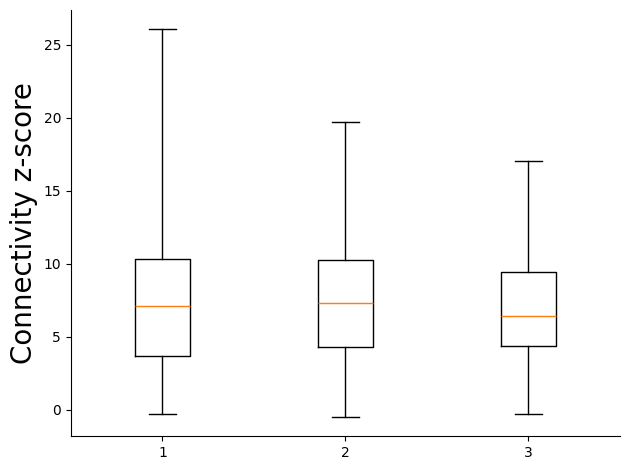

In [235]:


fig1, ax1 = plt.subplots()
labels=list([str(i) for i in tot_gen_connectivity_zscore_dict.keys()])
plt.ylabel('Connectivity z-score',fontsize=20)
comparing_group_list= list(tot_gen_connectivity_zscore_dict.values())
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

#plt.yscale("log")
plt.tight_layout()
plt.savefig('Figures/ConnectivityzscoreperStage_Female.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [236]:


t_value,p_value=stats.ttest_ind(tot_gen_connectivity_zscore_dict[1],tot_gen_connectivity_zscore_dict[2])
print("T-test Stage 1 vs Stage 2, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(tot_gen_connectivity_zscore_dict[1],tot_gen_connectivity_zscore_dict[3])
print("T-test Stage 1 vs Stage 3, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(tot_gen_connectivity_zscore_dict[2],tot_gen_connectivity_zscore_dict[3])
print("T-test Stage 2 vs Stage 3, p-value is %s"%p_value)


T-test Stage 1 vs Stage 2, p-value is 0.9344289917850312
T-test Stage 1 vs Stage 3, p-value is 0.9955474459962614
T-test Stage 2 vs Stage 3, p-value is 0.9508384277862054


In [237]:
#Let's see what happens if we remove the genes that were already perturbed at the previous time points of each trajectory

tot_s1_gene_list=[]
tot_s2_gene_list=[]
tot_s3_gene_list=[]

trj_s1_gene_list=[]
trj_s2_gene_list=[]
trj_s3_gene_list=[]


for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    genelist_s1 = []
    genelist_s2 = []
    genelist_s3 = []
    try:
        for dis in stage_dict[1]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1:
                        genelist_s1.append(gene)
            except:
                pass
    except:
        pass
    tot_s1_gene_list.extend(genelist_s1)
    trj_s1_gene_list.append(len(genelist_s1))
    try:
        for dis in stage_dict[2]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1: 
                        if gene not in genelist_s2: 
                            genelist_s2.append(gene)
            except:
                pass
    except:
        pass
    tot_s2_gene_list.extend(genelist_s2)
    trj_s2_gene_list.append(len(genelist_s2))
    try:
        for dis in stage_dict[3]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1 and gene not in genelist_s2:
                        if gene not in genelist_s3:
                            genelist_s3.append(gene)
            except:
                pass
    except:
        pass
    tot_s3_gene_list.extend(genelist_s3)
    trj_s3_gene_list.append(len(genelist_s3))



/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/2977339092.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

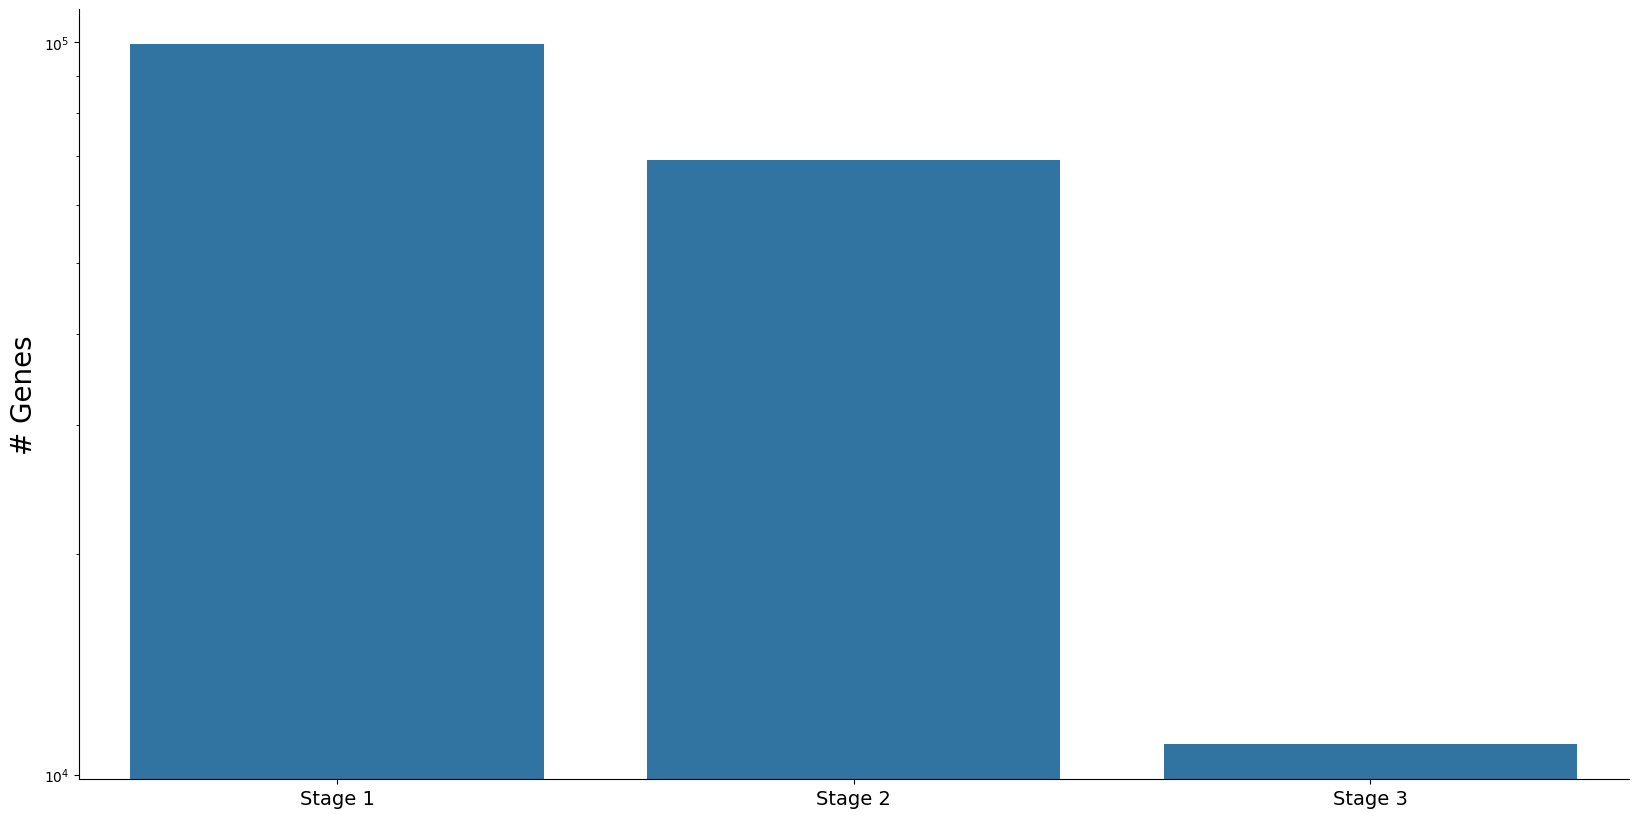

In [238]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

# Set the y-axis to log scale
plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Genes', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [len(tot_s1_gene_list),len(tot_s2_gene_list),len(tot_s3_gene_list)]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.barplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()
plt.savefig('Figures/NumberGenesperStage_Female_RemovedPriorGenes.pdf',format='pdf',dpi=300, bbox_inches = "tight")

# Show the plot
plt.show

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/2689093307.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

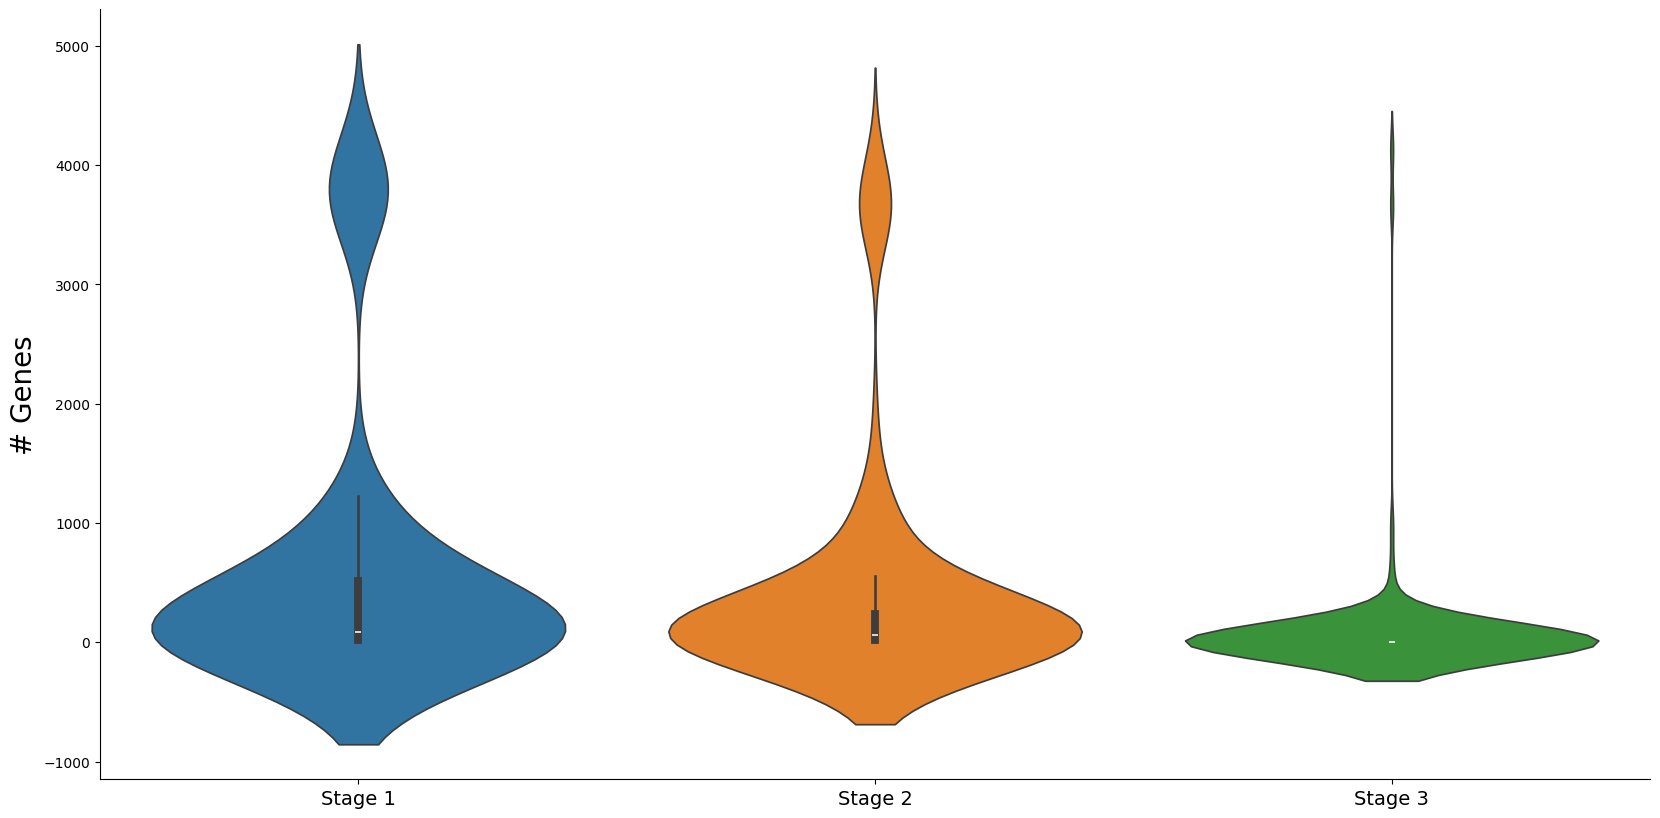

In [239]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Genes', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [trj_s1_gene_list,trj_s2_gene_list,trj_s3_gene_list]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.violinplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/SizeGenesTrajperStage_Female_RemovePriorGenes.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show


/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/823234882.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


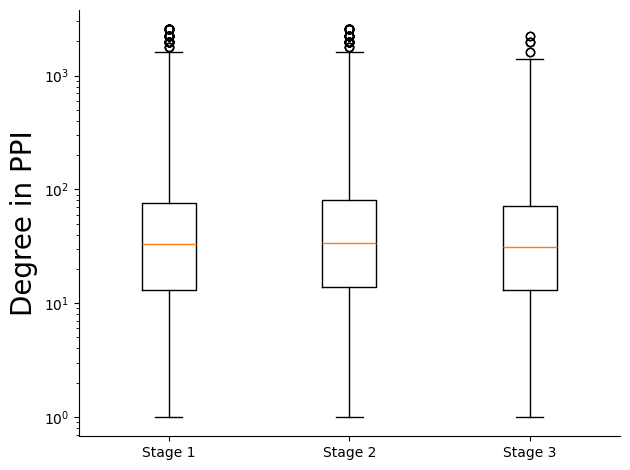

In [240]:
fig1, ax1 = plt.subplots()

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

plt.ylabel('Degree in PPI',fontsize=20)
comparing_group_list= [
            [G_ppi.degree(gene) for gene in tot_s1_gene_list],
            [G_ppi.degree(gene) for gene in tot_s2_gene_list],
            [G_ppi.degree(gene) for gene in tot_s3_gene_list]
]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.yscale("log")
plt.tight_layout()

plt.show()



In [241]:
print(np.median([G_ppi.degree(gene) for gene in tot_s1_gene_list]))
print(np.median([G_ppi.degree(gene) for gene in tot_s2_gene_list]))
print(np.median([G_ppi.degree(gene) for gene in tot_s3_gene_list]))


33.0
34.0
31.0


In [92]:
#Let's make a dictionary that takes all the genes associated with the diseases at each stage

tot_gen_gene_dict_removed_genes={}


tot_s1_gene_list=[]
tot_s2_gene_list=[]
tot_s3_gene_list=[]


for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    genelist_s1 = []
    genelist_s2 = []
    genelist_s3 = []
    try:
        for dis in stage_dict[1]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1:
                        genelist_s1.append(gene)
            except:
                pass
    except:
        pass
    tot_s1_gene_list.extend(genelist_s1)
    try:
        for dis in stage_dict[2]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1: 
                        if gene not in genelist_s2: 
                            genelist_s2.append(gene)
            except:
                pass
    except:
        pass
    tot_s2_gene_list.extend(genelist_s2)
    try:
        for dis in stage_dict[3]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1 and gene not in genelist_s2:
                        if gene not in genelist_s3:
                            genelist_s3.append(gene)
            except:
                pass
    except:
        pass
    tot_s3_gene_list.extend(genelist_s3)

    
tot_gen_gene_dict_removed_genes[1] = tot_s1_gene_list
tot_gen_gene_dict_removed_genes[2] = tot_s2_gene_list
tot_gen_gene_dict_removed_genes[3] = tot_s3_gene_list



tot_gen_gene_dict_removed_genes_counter={}
for gen,genelist in tot_gen_gene_dict_removed_genes.items():
    genelist_count=Counter(genelist).most_common()
    tot_gen_gene_dict_removed_genes_counter[gen]=genelist_count

In [93]:
tot_gen_gene_dict_removed_genes_counter[1][:10]


[('NR3C1', 81),
 ('SCN4A', 68),
 ('ADRA2A', 67),
 ('PTGS2', 67),
 ('SCN5A', 65),
 ('SCN9A', 63),
 ('ADRA2B', 61),
 ('SCN3A', 58),
 ('SCN1A', 58),
 ('SCN8A', 58)]

In [94]:
tot_gen_gene_dict_removed_genes_counter[2][:10]


[('OPRM1', 46),
 ('SCN4A', 45),
 ('GABRG3', 42),
 ('GABRA1', 42),
 ('PTGS2', 42),
 ('GABRA4', 41),
 ('GABRA5', 41),
 ('GABRB1', 41),
 ('GABRG1', 41),
 ('GABRA3', 41)]

In [95]:
tot_gen_gene_dict_removed_genes_counter[3][:10]


[('TP53', 6),
 ('IL10', 6),
 ('IL12B', 6),
 ('HLA-C', 6),
 ('CST3', 6),
 ('THBD', 6),
 ('SPP1', 6),
 ('CLU', 6),
 ('SERPINA1', 6),
 ('TF', 6)]

In [96]:
for gen,genelist in tot_gen_gene_dict_removed_genes_counter.items():
    print(gen,len(set(genelist)))

1 9428
2 8671
3 5321


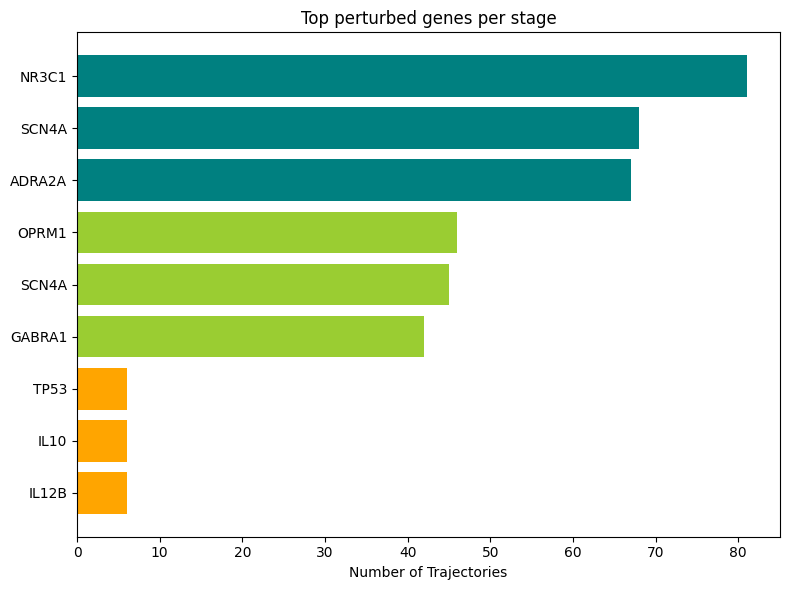

In [97]:
#Let's make it as a barplot
dis_list = ['NR3C1','SCN4A','ADRA2A','OPRM1','SCN4A','GABRA1','TP53','IL10','IL12B']
frequency_list = [81,68,67,46,45,42,6,6,6]
color_list = ['teal', 'yellowgreen','orange']
# Assign colors cycling every three bars
bar_colors = [color_list[(i // 3) % len(color_list)] for i in range(len(dis_list))]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(dis_list))

ax.barh(y_pos, frequency_list, color=bar_colors, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(dis_list)
ax.invert_yaxis()  # Labels read top-to-bottom
ax.set_xlabel('Number of Trajectories')
ax.set_title('Top perturbed genes per stage')

plt.tight_layout()
plt.savefig('Figures/FemaleGeneFrequencyBarplot_RemovePriorGenes.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [250]:
#ENRICH

In [98]:

tot_gen_gene_dict_removed_genes_counter_df={}

for gen,genecount in tot_gen_gene_dict_removed_genes_counter.items():
    rank_df=pd.DataFrame(columns=('gene', 'rank'))
    gene_list=[]
    rank_genelist=[]
    for el in genecount:
        gene_list.append(el[0])
        rank_genelist.append(el[1])
    rank_df['gene']=gene_list
    rank_df['rank']=rank_genelist
    rank_df=rank_df.sort_values(by=['rank'],ascending=False)
    tot_gen_gene_dict_removed_genes_counter_df[gen]=rank_df

In [99]:

for gen,rank_df in tot_gen_gene_dict_removed_genes_counter_df.items():
        
    lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
                     processes=4,min_size=3,max_size=5000,outdir=None,   #we impose at least 5 enriched common genes
                     permutation_num=500) # reduce number to speed up testing
    # to save your figure, make sure that ``ofname`` is not None
    ax = dotplot(lib_pre_res.res2d,
                 column="FDR q-val",
                 title='Female KEGG at stage %s'%gen,
                 cmap=plt.cm.viridis,
                 size=6, # adjust dot size
                 figsize=(4,5), cutoff=0.25, ofname='Figures/Female KEGG Removed Prior Genes at stage %s.pdf'%gen, show_ring=False)

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_99885/194751572.py:3: DeprecationWarning: processes is deprecated; use threads
  lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
2024-12-06 12:15:39,046 [WARNING] Duplicated values found in preranked stats: 99.36% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/gseapy/plot.py:738: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[self.colname] = df[self.colname].replace(0, np.nan).bfill()
/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_99885/194751572.py:3: DeprecationWarning: processes is deprecated; use threads
  lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Hum

In [255]:

female_trj_deg_dict = {}
for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    genelist_s1 = []
    genelist_s2 = []
    genelist_s3 = []
    try:
        for dis in stage_dict[1]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1:
                        genelist_s1.append(gene)
            except:
                pass
    except:
        pass
    try:
        for dis in stage_dict[2]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1: 
                        if gene not in genelist_s2: 
                            genelist_s2.append(gene)
            except:
                pass
    except:
        pass
    try:
        for dis in stage_dict[3]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1 and gene not in genelist_s2:
                        if gene not in genelist_s3:
                            genelist_s3.append(gene)
            except:
                pass
    except:
        pass
    genelist_s1_deglist = [G_ppi.degree(gene) for gene in genelist_s1]
    genelist_s2_deglist = [G_ppi.degree(gene) for gene in genelist_s2]
    genelist_s3_deglist = [G_ppi.degree(gene) for gene in genelist_s3]
    female_trj_deg_dict[trj] = [np.median(genelist_s1_deglist),np.median(genelist_s2_deglist),np.median(genelist_s3_deglist)]





/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [257]:
female_stage_avg_deg_stage_dict = {}
for i in range(3):
    deglist = []
    for trj,avgdeglist in female_trj_deg_dict.items():
        if str(avgdeglist[i])!='nan':
            deglist.append(avgdeglist[i])
    female_stage_avg_deg_stage_dict[i+1] = deglist


/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/2977159365.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


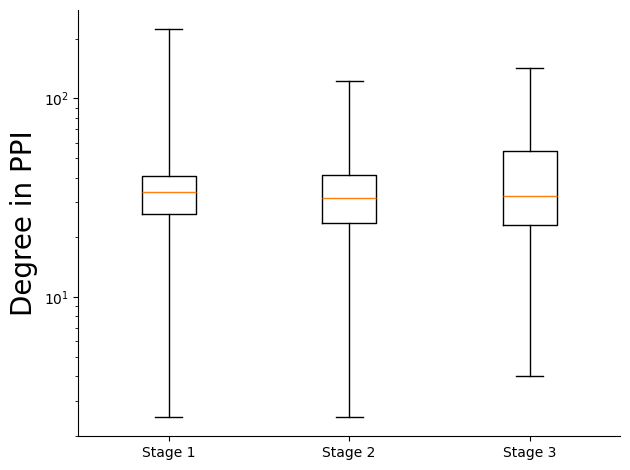

In [260]:
fig1, ax1 = plt.subplots()

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

plt.ylabel('Degree in PPI',fontsize=20)
comparing_group_list= list(female_stage_avg_deg_stage_dict.values())
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.yscale("log")
plt.tight_layout()
plt.savefig('Figures/MedianDegreeperTrjperStage_Female.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()


In [261]:


t_value,p_value=stats.ttest_ind(stage_avg_deg_stage_dict[1],stage_avg_deg_stage_dict[2])
print("T-test Stage 1 vs Stage 2, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(stage_avg_deg_stage_dict[1],stage_avg_deg_stage_dict[3])
print("T-test Stage 1 vs Stage 3, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(stage_avg_deg_stage_dict[2],stage_avg_deg_stage_dict[3])
print("T-test Stage 2 vs Stage 3, p-value is %s"%p_value)


T-test Stage 1 vs Stage 2, p-value is 0.3403287497197721
T-test Stage 1 vs Stage 3, p-value is 0.0763003333651263
T-test Stage 2 vs Stage 3, p-value is 0.03609742489910448


In [262]:
#Let's divide the trajectories in those which stage-specific genes degree tend to inrease and those that decreases
#We will just compare the last and the first stage point

ascending_trj = []
descending_trj = []
for trj,deglist in female_trj_deg_dict.items():
    deglist_cl = [n for n in deglist if str(n)!="nan"]
    if deglist_cl[-1]>deglist_cl[0]:
        ascending_trj.append(trj)
    else:
        descending_trj.append(trj)

print(len(ascending_trj))
print(len(descending_trj))

70
89


In [264]:
for trj in descending_trj:
    if len(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict[trj])>2:
        print(trj,female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict[trj])

3 {1: ['A38', 'B97', 'E45', 'G47', 'H04', 'J10'], 2: ['J35', 'J36'], 3: ['B07', 'B34', 'G51', 'H53', 'H72', 'H74', 'J15']}
160 {1: ['H10'], 2: ['M54', 'M70'], 3: ['J31']}
179 {1: ['E13'], 2: ['E11', 'E12', 'E13', 'G63', 'L03'], 3: ['G63', 'M86', 'N08']}
191 {1: ['M51'], 2: ['G55', 'M43', 'M48', 'M51'], 3: ['G55', 'G57', 'M51']}
193 {1: ['M51'], 2: ['G55', 'M43', 'M48', 'M51'], 3: ['G54', 'G55', 'G57', 'M51', 'M54']}
229 {1: ['M77'], 2: ['M21'], 3: ['G57']}
236 {1: ['N04'], 2: ['B99', 'E07', 'I10', 'I46', 'I71', 'J03', 'J22', 'J30', 'J41', 'J42', 'J81', 'J84', 'K55', 'L27', 'L50', 'M86', 'N30'], 3: ['E26', 'N03']}
265 {1: ['M47'], 2: ['D34', 'D44', 'E04', 'E21', 'E55', 'E83'], 3: ['E07']}
272 {1: ['D75'], 2: ['J44', 'J93'], 3: ['B96', 'J93']}
274 {1: ['E16'], 2: ['E10'], 3: ['E10', 'E13', 'E16', 'G63']}
275 {1: ['I99'], 2: ['A04', 'E78', 'E83', 'G51', 'G58', 'I08', 'J22', 'M10', 'M85'], 3: ['E83', 'F50', 'N04', 'N62', 'N87']}
279 {1: ['F06', 'F48'], 2: ['F32', 'F40', 'F48'], 3: ['D16', 

In [265]:
for trj in ascending_trj:
    if len(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict[trj])>2:
        print(trj,female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict[trj])

15 {1: ['E45', 'E66', 'G47'], 2: ['H65', 'H90'], 3: ['D27', 'D39', 'F81', 'H65', 'H66', 'H90', 'I88', 'J00', 'N83']}
35 {1: ['B00'], 2: ['J31', 'J35'], 3: ['K07']}
71 {1: ['E03'], 2: ['D50', 'D64', 'E03'], 3: ['E03', 'E06']}
152 {1: ['M06'], 2: ['M05', 'M06'], 3: ['M13']}
156 {1: ['E21', 'N18', 'N19'], 2: ['E21', 'I15', 'N18', 'N19'], 3: ['I15', 'N17', 'N19']}
159 {1: ['B16'], 2: ['B17', 'B18'], 3: ['B17', 'B18', 'K73']}
194 {1: ['G58'], 2: ['M54', 'M70', 'M80', 'M93'], 3: ['D16', 'D36', 'F54', 'H65', 'K04']}
232 {1: ['M65'], 2: ['M24', 'M65', 'M67'], 3: ['M24', 'M65', 'M67', 'M72']}
239 {1: ['E21'], 2: ['E21', 'N18', 'N19'], 3: ['E21', 'N17', 'N19']}
243 {1: ['A04'], 2: ['K80', 'K81'], 3: ['D72']}
244 {1: ['A08', 'J31', 'M46'], 2: ['A49', 'B96', 'K29', 'K55'], 3: ['D22', 'K20', 'L28', 'N60']}
284 {1: ['G93'], 2: ['G40', 'G93'], 3: ['G41']}
315 {1: ['M16'], 2: ['E66', 'L30', 'M16', 'M87'], 3: ['E65', 'K45', 'L27', 'N62']}
351 {1: ['D63', 'D69', 'D70'], 2: ['D61', 'D63', 'D69', 'D70'], 

In [356]:
#Here, we remove the diseases that have been diagnosed already the previous time-point

In [266]:
female_trajectories_dis_sort_bytime_grouped_all_add_evolving_no_repeateddis_dict = {}

for trj, disdict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    dis_dict_gen = {}
    back_dis_state = list(disdict[1])  # Ensure this is a new list to avoid modifying the original

    for i in range(1, len(disdict) + 1):  # Start from the second key
        if i==1:
            dis_dict_gen[i] = disdict[1]
        else:
            i_dis = []
            for dis in disdict[i]:
                if dis not in back_dis_state:
                    i_dis.append(dis)
                    back_dis_state.append(dis)  # Add the new disease to the tracked state
            if i_dis:  # Only include non-empty lists
                dis_dict_gen[i] = i_dis

    if len(dis_dict_gen) > 1:  # Ensure there is more than one state to include in the result
        female_trajectories_dis_sort_bytime_grouped_all_add_evolving_no_repeateddis_dict[trj] = dis_dict_gen

print(len(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_no_repeateddis_dict))

159


In [267]:
#Let's see how many diseases are present at each stage for any trajectory:

tot_s1_dis_list=[]
tot_s2_dis_list=[]
tot_s3_dis_list=[]


trj_s1_dis_list=[]
trj_s2_dis_list=[]
trj_s3_dis_list=[]

for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_no_repeateddis_dict.items():
    try:
        tot_s1_dis_list.extend(stage_dict[1])
    except:
        pass
    try:
        tot_s2_dis_list.extend(stage_dict[2])
    except:
        pass
    try:
        tot_s3_dis_list.extend(stage_dict[3])
    except:
        pass


for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_no_repeateddis_dict.items():
    try:
        trj_s1_dis_list.append(len(stage_dict[1]))
    except:
        pass
    try:
        trj_s2_dis_list.append(len(stage_dict[2]))
    except:
        pass
    try:
        trj_s3_dis_list.append(len(stage_dict[3]))
    except:
        pass

    

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/2831753499.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

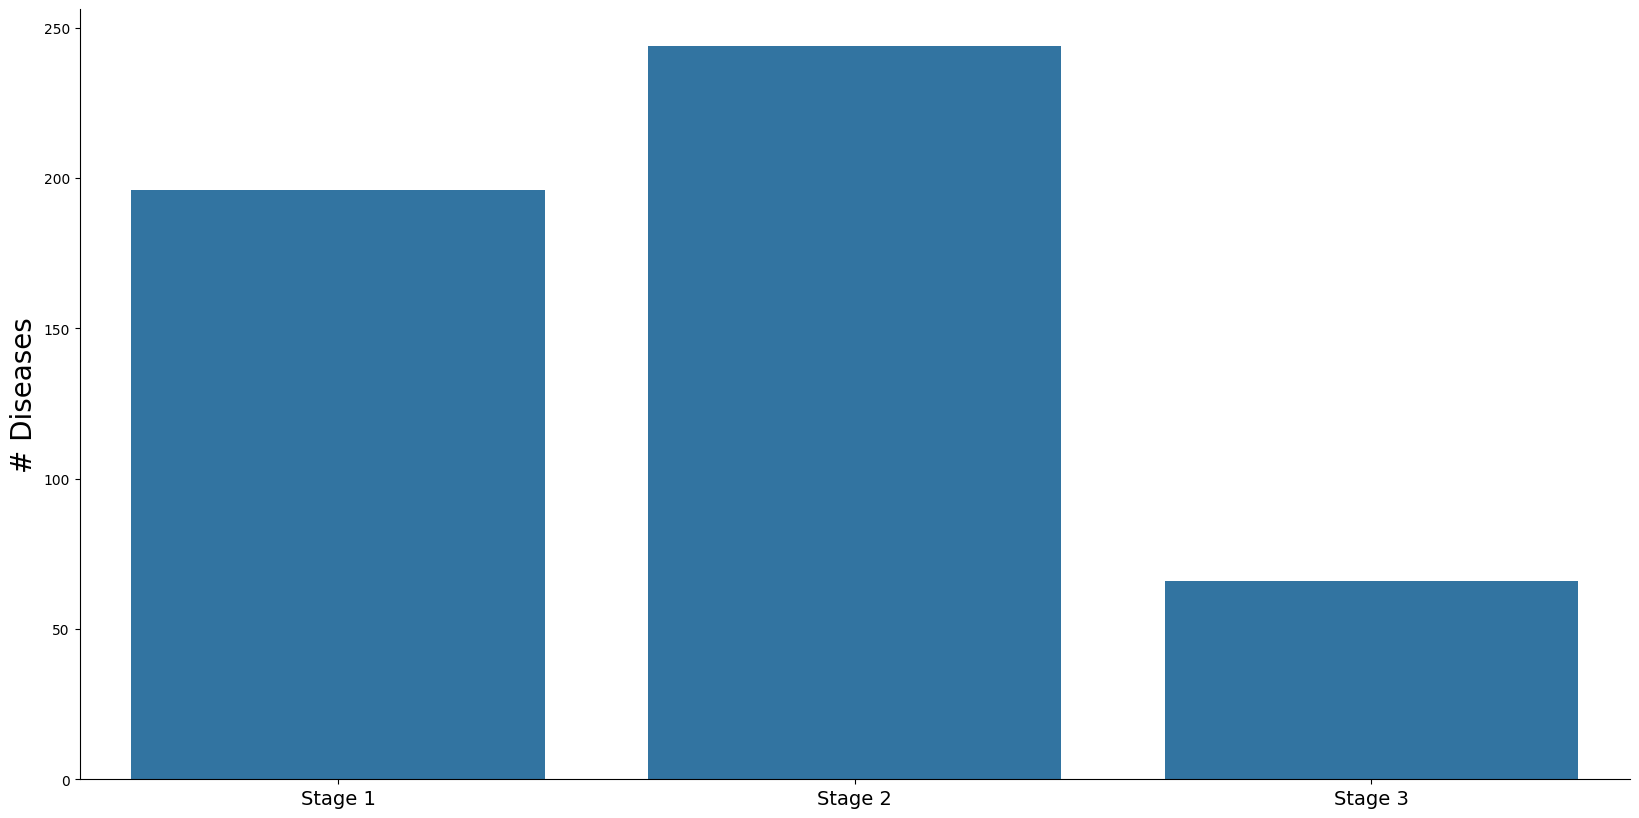

In [268]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Diseases', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [len(set(tot_s1_dis_list)),len(set(tot_s2_dis_list)),len(set(tot_s3_dis_list))]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.barplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()
plt.savefig('Figures/NumberDiseasesperStage_Female_RemovedPriorDiseases.pdf',format='pdf',dpi=300, bbox_inches = "tight")

# Show the plot
plt.show

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_1267/624197558.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

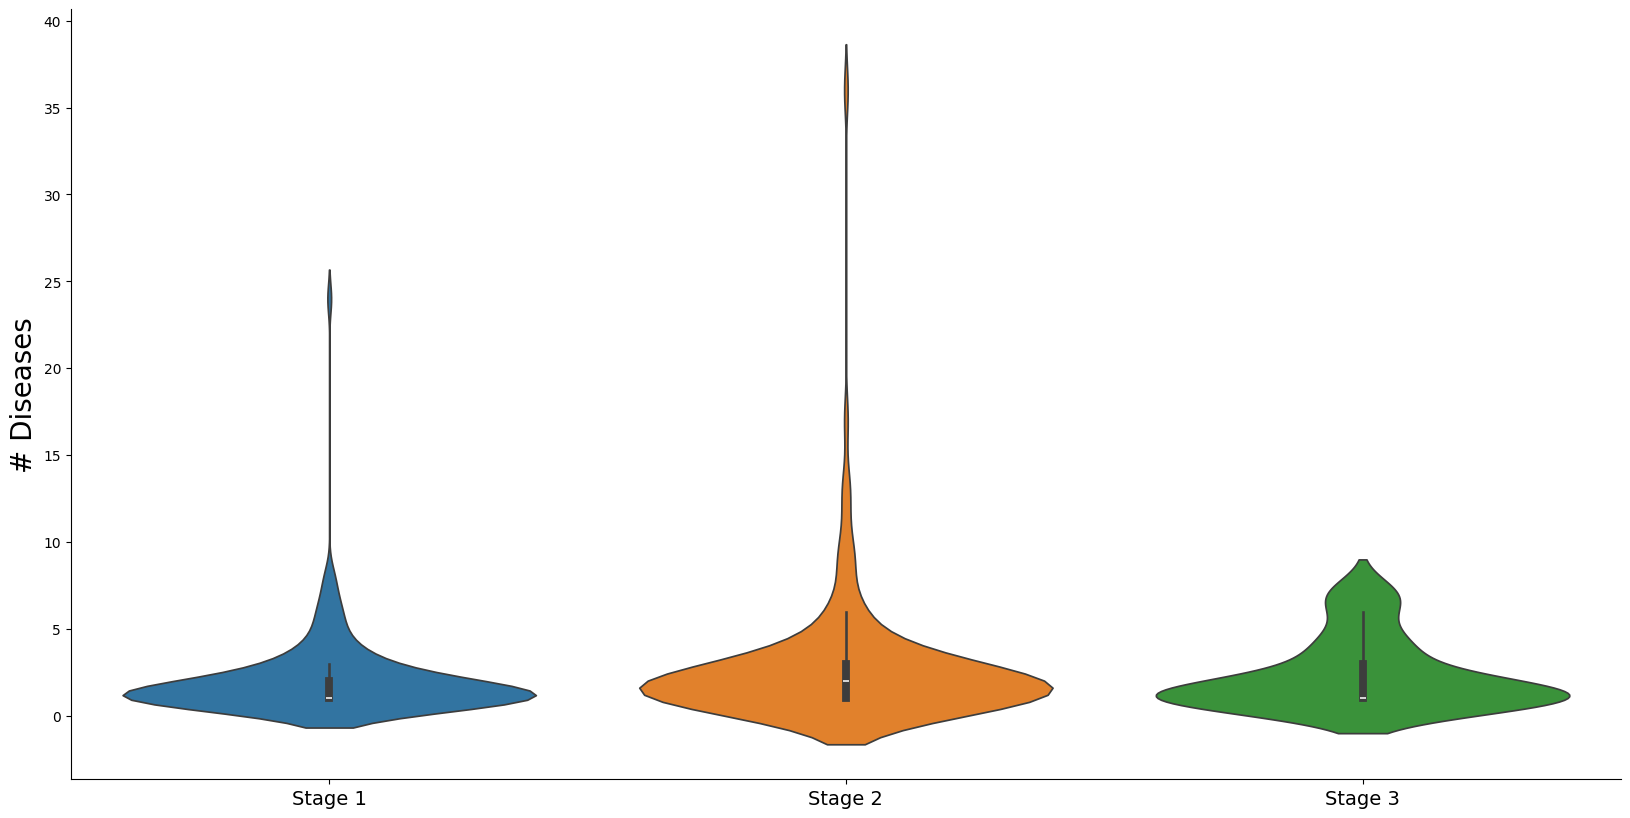

In [269]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Diseases', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [trj_s1_dis_list,trj_s2_dis_list,trj_s3_dis_list]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.violinplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/SizeDiseaseTrajperStage_Female_RemovedPriorDiseases.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show

